# No-Free-Lunch Principle in Metric Aggregation for Knowledge Graph Completion: Analyzing Trade-offs in MCDM Stability, Robustness, Generalizability, and Consistency

# No-Free-Lunch Principle in Metric Aggregation for Knowledge Graph Completion  
**Analyzing Trade-offs in MCDM Consistency, Stability, Robustness, and Generalizability in KGC **

**Anonymous Author(s)**  
KDD 2026 Submission (under review)

## Abstract (from paper)

Evaluating Knowledge Graph Completion (KGC) models has reached a critical impasse due to fragmented performance assessment. Traditional rank-based metrics (MRR, Hits@k, MR) frequently produce inconsistent or contradictory rankings across datasets and metrics. We reframe KGC evaluation as a Multi-Criteria Decision Making (MCDM) problem and conduct the first comprehensive meta-evaluation of seven aggregators (EDAS, TOPSIS, VIKOR, WASPAS, Borda, MOORA, Z-Score) across ten models, five benchmarks, and two tasks: relation (h,?,t) and tail (h,r,?) prediction.

We rigorously analyze five desiderata:

- **Consistency** — alignment with individual metrics  
- **Stability** — cross-dataset ranking consistency  
- **Metric Independence** — robustness to metric removal  
- **Robustness** — stability under noise injection  
- **Generalizability** — performance prediction on unseen benchmarks  

Results reveal a clear **No Free Lunch** trade-off: **no single aggregator dominates all dimensions**. Pareto analysis identifies **Z-Score** as the jointly optimal aggregator for holistic KGC evaluation. The framework resolves longstanding contradictions in model rankings and establishes a principled, reproducible standard for KGC benchmarking.


This notebook reproduces the core experiments and visualizations presented in the paper:

- Relation prediction analysis (consistency, correlations, and ranking plots)  
- Tail prediction analysis (same dimensions)  
- Stability (cross-dataset variance + boxplots)  
- Robustness / metric dependency (leave-one-metric-out + noise injection)  
- Consensus analysis (average ranking + lollipop plots)  
- No-Free-Lunch visualization suite:  
  - Critical Difference diagrams  
  - Radar charts (trade-off overview)  
  - Horizontal desiderata bars  
  - Overall performance ranking  

## Required Input Files

Place these two CSV files in the following path **before running**:  
- r_pred_main_file.csv     # Relation prediction metrics (all datasets)  
- t_pred_main_file.csv     # Tail prediction metrics (all datasets)


### 1. Relation Prediction Analysis
- Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

def load_file(path):
    """
    Tries to load a file in different common formats.
    Returns DataFrame or raises informative error.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File not found: {path}\n\n"
            f"Folder contents:\n"
            f"{os.listdir(os.path.dirname(path)) if os.path.exists(os.path.dirname(path)) else 'folder itself not found'}"
        )

    try:
        return pd.read_csv(path)
    except Exception as e_csv:
        try:
            return pd.read_csv(path, sep='\t', header=None)
        except Exception as e_tab:
            try:
                return pd.read_csv(path, sep=' ', header=None)
            except Exception as e_space:
                raise ValueError(
                    f"Could not load {path}\n"
                    f"CSV error:   {e_csv}\n"
                    f"Tab error:   {e_tab}\n"
                    f"Space error: {e_space}"
                )





r_file = '/content/drive/MyDrive/No_Free_Lunch_KGC/Relation_pred_main_file.csv'
r_df = load_file(r_file)
print("r_pred_main_file shape:", r_df.shape)
print("\nFirst 5 rows of r_pred_main_file:")
display(r_df.head())



r_pred_main_file shape: (12, 19)

First 5 rows of r_pred_main_file:


,Models,MRR_d0,H@1_d0,H@3_d0,MRR_d1,H@1_d1,H@3_d1,MRR_d2,H@1_d2,H@3_d2,MRR_d3,H@1_d3,H@3_d3,MRR_d4,H@1_d4,H@3_d4,MRR_d5,H@1_d5,H@3_d5
0,TransE,96.2,94.0,98.2,96.6,94.6,98.4,97.1,95.5,98.4,78.4,66.9,87.0,84.1,78.1,88.9,96.6,94.8,98.0
1,ComplEx,90.1,84.4,95.2,92.4,87.9,97.0,98.5,97.9,99.1,84.0,77.7,88.0,70.3,62.5,76.5,95.3,93.1,96.8
2,DistMult,66.1,43.9,86.8,87.5,80.6,93.6,78.6,58.4,98.7,84.7,78.7,89.1,63.4,52.4,72.0,92.7,88.6,96.1
3,RotatE,97.9,96.7,98.6,97.0,95.1,98.0,98.4,97.9,98.6,79.9,73.5,82.3,72.9,69.1,75.6,95.3,93.4,96.4
4,SimplE,98.3,97.2,99.1,97.1,95.5,98.7,97.2,96.4,97.6,73.0,65.9,75.5,71.6,67.1,74.8,92.4,89.2,94.8


#### 1.1 Compute Aggregators Score and Ranks

- Aggregators Score  
- Aggregators Ranks  

In [ ]:
##################################################################################
import shutil

source = '/content/drive/MyDrive/No_Free_Lunch_KGC/Relation_pred_main_file.csv'
target = '/content/Relation_pred_main_file.csv'

shutil.copy(source, target)
print("File copied to /content/")



File copied to /content/


#### 1.2 Consistency Test
- Aggregators Correlations  
  - Kendall Correlation
  - Pearson Correlation
  - Spearman Correlation
  - Overall Correlation

In [ ]:
# ==========================================================
# LOAD DATA AND PREPARE FOR ANALYSIS
# ==========================================================
import pandas as pd
import numpy as np
from scipy.stats import zscore
import os

# Load the dataset
df = pd.read_csv("/content/Relation_pred_main_file.csv")

# Prepare metrics table (Models become row names)
df_metrics = df.set_index('Models').copy()
df_metrics = df_metrics.round(4)

print("Dataset loaded successfully")
display(df_metrics.head())
print(f"Shape: {df_metrics.shape} (rows = models, columns = metrics)")

# Create output folder
outdir = "/content/1. Relation_Consistency_Test1"
os.makedirs(outdir, exist_ok=True)


# ==========================================================
# STEP 1: IDENTIFY BENEFICIAL vs NON-BENEFICIAL METRICS
# ==========================================================
# Beneficial: MRR, H@1, H@3 (higher is better)
beneficial_cols = [
    col for col in df_metrics.columns
    if col.startswith(('MRR', 'H@1', 'H@3'))
]

# Non-beneficial: MR (Mean Rank) – lower is better
non_beneficial_cols = [
    col for col in df_metrics.columns
    if col.startswith('MR') and 'MRR' not in col
]

print(f"\nBeneficial metrics (higher = better): {beneficial_cols}")
print(f"Non-beneficial metrics (lower = better): {non_beneficial_cols}")


# ==========================================================
# STEP 2: NORMALIZE DATA FOR MCDM
# All criteria are converted so that higher = better
# ==========================================================
def normalize_for_mcdm(df, beneficial_cols, non_beneficial_cols):
    """
    Normalization strategy:
    - MR columns: min / value
      Because lower MR is better, this converts MR so higher = better.

    - MRR, H@1, H@3 columns: value / column_max
      Because higher values are already better.
    """
    df_norm = df.copy()

    # Process MR columns: lower is better
    for col in non_beneficial_cols:
        col_min = df[col].min()

        if col_min == 0:
            col_min = 1e-6

        df_norm[col] = col_min / df[col]

    # Process beneficial columns: higher is better
    for col in beneficial_cols:
        col_max = df[col].max()

        if col_max == 0:
            df_norm[col] = 0.0
        else:
            df_norm[col] = df[col] / col_max

    return df_norm


df_normalized = normalize_for_mcdm(
    df_metrics,
    beneficial_cols,
    non_beneficial_cols
)

print("\nNormalized data: all columns now higher = better")
display(df_normalized.round(6))


# ==========================================================
# STEP 3: MCDM AGGREGATION METHODS
# ==========================================================
def borda_count_local(df):
    m = df.shape[0]
    ranks = df.rank(ascending=False, method='average')
    points = m - ranks + 1
    return points.sum(axis=1).round(4)


def zscore_average_local(df):
    zs = df.apply(zscore, axis=0, nan_policy='omit').fillna(0)
    return zs.mean(axis=1).round(4)


def topsis_local(df, weights=None):
    X = df.values.astype(float)
    m, n = X.shape

    if weights is None:
        w = np.ones(n) / n
    else:
        w = np.array(weights) / np.sum(weights)

    norm = np.sqrt(np.sum(X ** 2, axis=0))
    norm[norm == 0] = 1.0

    R = X / norm
    V = R * w

    ideal_best = V.max(axis=0)
    ideal_worst = V.min(axis=0)

    dist_best = np.sqrt(np.sum((V - ideal_best) ** 2, axis=1))
    dist_worst = np.sqrt(np.sum((V - ideal_worst) ** 2, axis=1))

    closeness = dist_worst / (dist_best + dist_worst + 1e-12)

    return pd.Series(closeness, index=df.index).round(4)


def vikor_local(df, weights=None, v=0.5):
    X = df.values.astype(float)
    m, n = X.shape

    if weights is None:
        w = np.ones(n) / n
    else:
        w = np.asarray(weights) / np.sum(weights)

    f_star = X.max(axis=0)
    f_minus = X.min(axis=0)

    denom = f_star - f_minus
    denom[denom == 0] = 1.0

    D = (f_star - X) / denom

    S = np.dot(D, w)
    R = np.max(w * D, axis=1)

    S_star, S_minus = S.min(), S.max()
    R_star, R_minus = R.min(), R.max()

    denom_S = S_minus - S_star if S_minus != S_star else 1.0
    denom_R = R_minus - R_star if R_minus != R_star else 1.0

    Q = (
        v * (S - S_star) / denom_S
        + (1 - v) * (R - R_star) / denom_R
    )

    return pd.Series(Q, index=df.index).round(4)


def edas_local(df, weights=None):
    X = df.values.astype(float)
    m, n = X.shape

    if weights is None:
        w = np.ones(n) / n
    else:
        w = np.asarray(weights) / np.sum(weights)

    AV = X.mean(axis=0)

    PDA = np.maximum(0, X - AV)
    NDA = np.maximum(0, AV - X)

    SP = np.dot(PDA, w)
    SN = np.dot(NDA, w)

    SP_max = SP.max() if SP.max() > 0 else 1.0
    SN_max = SN.max() if SN.max() > 0 else 1.0

    NSP = SP / SP_max
    NSN = 1 - (SN / SN_max)

    AS = 0.5 * (NSP + NSN)

    return pd.Series(AS, index=df.index).round(4)


def moora_local(df, weights=None):
    X = df.values.astype(float)
    m, n = X.shape

    norm = np.sqrt(np.sum(X ** 2, axis=0))
    norm[norm == 0] = 1.0

    X_norm = X / norm

    if weights is None:
        w = np.ones(n) / n
    else:
        w = np.asarray(weights) / np.sum(weights)

    y = np.sum(X_norm * w, axis=1)

    return pd.Series(y, index=df.index).round(4)


def waspas_local(df, weights=None, lambda_param=0.5):
    X = df.values.astype(float)
    m, n = X.shape

    X_min = X.min(axis=0)
    X_max = X.max(axis=0)

    denom = X_max - X_min
    denom[denom == 0] = 1.0

    X_norm = (X - X_min) / denom

    if weights is None:
        w = np.ones(n) / n
    else:
        w = np.asarray(weights) / np.sum(weights)

    WSM = np.sum(X_norm * w, axis=1)
    WPM = np.prod(np.power(X_norm + 1e-12, w), axis=1)

    Q = lambda_param * WSM + (1 - lambda_param) * WPM

    return pd.Series(Q, index=df.index).round(4)


# ==========================================================
# STEP 4: COMPUTE ALL MCDM SCORES
# ==========================================================
print("\nComputing MCDM scores...")

# Borda
borda_score = borda_count_local(df_normalized)
borda_score = (borda_score / borda_score.max()).round(4)

# Z-score average
mean_z = zscore_average_local(df_normalized)

epsilon = 0.001
z_min = mean_z.min()
z_max = mean_z.max()

if z_max == z_min:
    mean_z_transformed = pd.Series(
        [1.0] * len(mean_z),
        index=mean_z.index
    )
else:
    t = (mean_z - z_min) / (z_max - z_min)
    mean_z_transformed = epsilon + (1 - epsilon) * t

mean_z = mean_z_transformed.round(4)

# TOPSIS
topsis_score = topsis_local(df_normalized)

# VIKOR
vikor_score = vikor_local(df_normalized)
vikor_score = 1 - vikor_score  # convert lower-is-better Q into higher-is-better score

# EDAS
edas_score = edas_local(df_normalized)

# MOORA
moora_score = moora_local(df_normalized)

# WASPAS
waspas_score = waspas_local(df_normalized)


# ==========================================================
# FINAL SCORE FLOOR AND CAP
# ==========================================================
min_floor = 0.0001
max_cap = 1.0000

for score_name, score in [
    ('edas', edas_score),
    ('topsis', topsis_score),
    ('vikor', vikor_score),
    ('borda', borda_score),
    ('mean_z', mean_z),
    ('moora', moora_score),
    ('waspas', waspas_score)
]:
    score = score.clip(lower=min_floor, upper=max_cap).round(4)

    if score_name == 'edas':
        edas_score = score
    elif score_name == 'topsis':
        topsis_score = score
    elif score_name == 'vikor':
        vikor_score = score
    elif score_name == 'borda':
        borda_score = score
    elif score_name == 'mean_z':
        mean_z = score
    elif score_name == 'moora':
        moora_score = score
    elif score_name == 'waspas':
        waspas_score = score

print(f"Applied minimum floor = {min_floor} and maximum cap = {max_cap} to all MCDM scores.")


# ==========================================================
# STEP 5: BUILD CONSENSUS METRICS AND FINAL RESULTS TABLE
# ==========================================================
mrr_cols = [c for c in df_metrics.columns if 'MRR' in c]
hit1_cols = [c for c in df_metrics.columns if 'H@1' in c]
hit3_cols = [c for c in df_metrics.columns if 'H@3' in c]
mr_cols = [c for c in df_metrics.columns if 'MR' in c and 'MRR' not in c]

# Mean MRR
if mrr_cols:
    mean_mrr = df_normalized[mrr_cols].mean(axis=1).round(4)
else:
    mean_mrr = pd.Series(np.nan, index=df_metrics.index)

# Mean H@1
if hit1_cols:
    mean_hit1 = df_normalized[hit1_cols].mean(axis=1).round(4)
else:
    mean_hit1 = pd.Series(np.nan, index=df_metrics.index)

# Mean H@3
if hit3_cols:
    mean_hit3 = df_normalized[hit3_cols].mean(axis=1).round(4)
else:
    mean_hit3 = pd.Series(np.nan, index=df_metrics.index)

# Mean MR
if mr_cols:
    mean_mr_normalized = df_normalized[mr_cols].mean(axis=1).round(4)
    mean_mr_original = df_metrics[mr_cols].mean(axis=1).round(4)
    mean_mr_inverted = -mean_mr_original
else:
    mean_mr_normalized = pd.Series(np.nan, index=df_metrics.index)
    mean_mr_original = mean_mr_normalized.copy()
    mean_mr_inverted = mean_mr_normalized.copy()


# ==========================================================
# INITIALIZE RESULTS DATAFRAME
# ==========================================================
results = pd.DataFrame(index=df_metrics.index)


# ==========================================================
# MCDM SCORES
#
# Correct mapping:
# ED = EDAS
# TP = TOPSIS
# VQ = VIKOR
# BS = Borda
# ZS = Z-score
# MO = MOORA
# WA = WASPAS
# ==========================================================
results['ED'] = edas_score
results['TP'] = topsis_score
results['VQ'] = vikor_score
results['BS'] = borda_score
results['ZS'] = mean_z
results['MO'] = moora_score
results['WA'] = waspas_score

# Aggregated original metrics from normalized data
results['MRR'] = mean_mrr
results['H1'] = mean_hit1
results['H3'] = mean_hit3

if mr_cols:
    results['MR'] = mean_mr_normalized


# ==========================================================
# RANKS
#
# Correct mapping:
# ZS_Rank = Z-score rank
# MO_Rank = MOORA rank
# ==========================================================
results['ED_Rank'] = edas_score.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['TP_Rank'] = topsis_score.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['VQ_Rank'] = vikor_score.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['BS_Rank'] = borda_score.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['ZS_Rank'] = mean_z.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['MO_Rank'] = moora_score.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['WA_Rank'] = waspas_score.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['MRR_Rank'] = mean_mrr.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['H1_Rank'] = mean_hit1.rank(
    ascending=False,
    method='min'
).astype('Int64')

results['H3_Rank'] = mean_hit3.rank(
    ascending=False,
    method='min'
).astype('Int64')

if mr_cols:
    results['MR_Rank'] = mean_mr_normalized.rank(
        ascending=False,
        method='min'
    ).astype('Int64')


# ==========================================================
# LONG NAMES FOR COMPATIBILITY WITH CORRELATION CELL
#
# Correct mapping:
# Z_Mean = Z-score
# MOORA = MOORA
# ==========================================================
results['EDAS_AS'] = edas_score
results['TOPSIS'] = topsis_score
results['VIKOR_Q'] = vikor_score
results['Borda_Score'] = borda_score
results['Z_Mean'] = mean_z
results['MOORA'] = moora_score
results['WASPAS'] = waspas_score

results['Mean_MRR'] = mean_mrr
results['Mean_Hit@1'] = mean_hit1
results['Mean_Hit@3'] = mean_hit3
results['Mean_MR_inverted'] = mean_mr_inverted


# ==========================================================
# SORT RESULTS
# ==========================================================
if mean_mrr.notna().any():
    results = results.sort_values('Mean_MRR', ascending=False)
elif mean_hit1.notna().any():
    results = results.sort_values('Mean_Hit@1', ascending=False)
else:
    results = results.sort_values('ED', ascending=False)


# ==========================================================
# DISPLAY AND SAVE RESULTS
# ==========================================================
print("\n" + "=" * 90)
print("MCDM AGGREGATION RESULTS")
print("Higher score = better | Rank 1 = best")
print("=" * 90)

score_cols = ['ED', 'TP', 'VQ', 'BS', 'ZS', 'MO', 'WA']

if mr_cols:
    score_cols.append('MR')

score_cols.extend(['MRR', 'H1', 'H3'])

print("\n1. SCORES TABLE")
print("   ED=EDAS | TP=TOPSIS | VQ=VIKOR | BS=Borda | ZS=Z-Score | MO=MOORA | WA=WASPAS")

if mr_cols:
    print("   MR = Mean MR normalized | All values: higher = better")

print("   NOTE: MRR, H1, H3 are normalized by column maximum.")
print("   NOTE: ZS column contains Z-score score.")
print("   NOTE: MO column contains MOORA score.")
print("-" * 90)

display(results[score_cols].round(4))

rank_cols = [c for c in results.columns if c.endswith('_Rank')]

print("\n2. RANKS TABLE")
print("   Rank 1 = best")
print("   NOTE: ZS_Rank contains Z-score rank.")
print("   NOTE: MO_Rank contains MOORA rank.")
print("-" * 90)

display(results[rank_cols])


# ==========================================================
# SAVE TABLES
# ==========================================================
results[score_cols].round(4).to_csv(
    f"{outdir}/mcdm_scores_table.csv",
    float_format='%.4f'
)

results[rank_cols].to_csv(
    f"{outdir}/mcdm_ranks_table.csv"
)

print(f"\nTables saved to folder: {outdir}")
print("   → mcdm_scores_table.csv")
print("   → mcdm_ranks_table.csv")


# ==========================================================
# CORRELATION ANALYSIS PLACEHOLDER
# ==========================================================
print("\n" + "=" * 90)
print("CORRELATION MATRIX SUMMARY")
print("=" * 90)

Dataset loaded successfully


,MRR_d0,H@1_d0,H@3_d0,MRR_d1,H@1_d1,H@3_d1,MRR_d2,H@1_d2,H@3_d2,MRR_d3,H@1_d3,H@3_d3,MRR_d4,H@1_d4,H@3_d4,MRR_d5,H@1_d5,H@3_d5
Models,,,,,,,,,,,,,,,,,,
TransE,96.2,94.0,98.2,96.6,94.6,98.4,97.1,95.5,98.4,78.4,66.9,87.0,84.1,78.1,88.9,96.6,94.8,98.0
ComplEx,90.1,84.4,95.2,92.4,87.9,97.0,98.5,97.9,99.1,84.0,77.7,88.0,70.3,62.5,76.5,95.3,93.1,96.8
DistMult,66.1,43.9,86.8,87.5,80.6,93.6,78.6,58.4,98.7,84.7,78.7,89.1,63.4,52.4,72.0,92.7,88.6,96.1
RotatE,97.9,96.7,98.6,97.0,95.1,98.0,98.4,97.9,98.6,79.9,73.5,82.3,72.9,69.1,75.6,95.3,93.4,96.4
SimplE,98.3,97.2,99.1,97.1,95.5,98.7,97.2,96.4,97.6,73.0,65.9,75.5,71.6,67.1,74.8,92.4,89.2,94.8


Shape: (12, 18) (rows = models, columns = metrics)

Beneficial metrics (higher = better): ['MRR_d0', 'H@1_d0', 'H@3_d0', 'MRR_d1', 'H@1_d1', 'H@3_d1', 'MRR_d2', 'H@1_d2', 'H@3_d2', 'MRR_d3', 'H@1_d3', 'H@3_d3', 'MRR_d4', 'H@1_d4', 'H@3_d4', 'MRR_d5', 'H@1_d5', 'H@3_d5']
Non-beneficial metrics (lower = better): []

Normalized data: all columns now higher = better


,MRR_d0,H@1_d0,H@3_d0,MRR_d1,H@1_d1,H@3_d1,MRR_d2,H@1_d2,H@3_d2,MRR_d3,H@1_d3,H@3_d3,MRR_d4,H@1_d4,H@3_d4,MRR_d5,H@1_d5,H@3_d5
Models,,,,,,,,,,,,,,,,,,
TransE,0.965863,0.944724,0.983968,0.967936,0.948847,0.984985,0.973922,0.959799,0.984985,0.784785,0.670341,0.870871,0.848638,0.792089,0.893467,0.967936,0.950853,0.980981
ComplEx,0.904618,0.848241,0.953908,0.925852,0.881645,0.970971,0.987964,0.983920,0.991992,0.840841,0.778557,0.880881,0.709384,0.633874,0.768844,0.954910,0.933801,0.968969
DistMult,0.663655,0.441206,0.869739,0.876754,0.808425,0.936937,0.788365,0.586935,0.987988,0.847848,0.788577,0.891892,0.639758,0.531440,0.723618,0.928858,0.888666,0.961962
RotatE,0.982932,0.971859,0.987976,0.971944,0.953862,0.980981,0.986961,0.983920,0.986987,0.799800,0.736473,0.823824,0.735621,0.700811,0.759799,0.954910,0.936810,0.964965
SimplE,0.986948,0.976884,0.992986,0.972946,0.957874,0.987988,0.974925,0.968844,0.976977,0.730731,0.660321,0.755756,0.722503,0.680527,0.751759,0.925852,0.894684,0.948949
QuatE,0.986948,0.976884,0.992986,0.975952,0.960883,0.988989,0.983952,0.979899,0.983984,0.823824,0.768537,0.852853,0.758829,0.716024,0.786935,0.947896,0.924774,0.962963
DRUM,0.948795,0.949749,0.979960,0.960922,0.907723,0.958959,0.971916,0.960804,0.980981,0.854855,0.779559,0.912913,0.721493,0.649087,0.743719,0.959920,0.932798,0.987988
R-GCN,0.698795,0.604020,0.761523,0.932866,0.905717,0.942943,0.911735,0.828141,0.979980,0.822823,0.751503,0.848849,0.792129,0.722110,0.830151,0.963928,0.940822,0.979980
Path,0.940763,0.922613,0.952906,0.973948,0.959880,0.986987,0.983952,0.975879,0.989990,0.933934,0.898798,0.961962,0.743693,0.694726,0.767839,0.970942,0.950853,0.991992



Computing MCDM scores...
Applied minimum floor = 0.0001 and maximum cap = 1.0 to all MCDM scores.

MCDM AGGREGATION RESULTS
Higher score = better | Rank 1 = best

1. SCORES TABLE
   ED=EDAS | TP=TOPSIS | VQ=VIKOR | BS=Borda | ZS=Z-Score | MO=MOORA | WA=WASPAS
   NOTE: MRR, H1, H3 are normalized by column maximum.
   NOTE: ZS column contains Z-score score.
   NOTE: MO column contains MOORA score.
------------------------------------------------------------------------------------------


,ED,TP,VQ,BS,ZS,MO,WA,MRR,H1,H3
Models,,,,,,,,,,
FMS,1.0000,1.0000,1.0000,1.0000,1.0000,0.3195,1.0000,1.0000,1.0000,1.0000
PathCon,0.8450,0.8282,0.7753,0.9120,0.8545,0.3092,0.8757,0.9710,0.9533,0.9880
Con,0.7457,0.7613,0.7014,0.7199,0.7704,0.3030,0.8023,0.9524,0.9201,0.9834
Path,0.5972,0.6067,0.3982,0.5880,0.6377,0.2925,0.6622,0.9245,0.9005,0.9419
TransE,0.5662,0.6105,0.2973,0.5000,0.5713,0.2905,0.5768,0.9182,0.8778,0.9499
QuatE,0.5369,0.5848,0.3681,0.5509,0.5134,0.2883,0.5410,0.9129,0.8878,0.9281
RotatE,0.4996,0.5544,0.3080,0.4722,0.4934,0.2853,0.5168,0.9054,0.8806,0.9174
DRUM,0.4792,0.5395,0.2701,0.4120,0.4720,0.2842,0.5000,0.9030,0.8633,0.9274
ComplEx,0.4160,0.4971,0.2949,0.4120,0.4288,0.2799,0.4810,0.8873,0.8433,0.9226



2. RANKS TABLE
   Rank 1 = best
   NOTE: ZS_Rank contains Z-score rank.
   NOTE: MO_Rank contains MOORA rank.
------------------------------------------------------------------------------------------


,ED_Rank,TP_Rank,VQ_Rank,BS_Rank,ZS_Rank,MO_Rank,WA_Rank,MRR_Rank,H1_Rank,H3_Rank
Models,,,,,,,,,,
FMS,1,1,1,1,1,1,1,1,1,1
PathCon,2,2,2,2,2,2,2,2,2,2
Con,3,3,3,3,3,3,3,3,3,3
Path,4,5,4,4,4,4,4,4,4,5
TransE,5,4,7,6,5,5,5,5,7,4
QuatE,6,6,5,5,6,6,6,6,5,6
RotatE,7,7,6,7,7,7,7,7,6,9
DRUM,8,8,9,8,8,8,8,8,8,7
ComplEx,10,10,8,8,9,9,9,9,10,8



Tables saved to folder: /content/1. Relation_Consistency_Test1
   → mcdm_scores_table.csv
   → mcdm_ranks_table.csv

CORRELATION MATRIX SUMMARY


##### 1.2.2 Table Generation: Mean Correlation Table

- Hits@1 = (Kendall + Spearman + Pearson) / 3  
- Hits@10 = (Kendall + Spearman + Pearson) / 3  
- MR = (Kendall + Spearman + Pearson) / 3  
- MRR = (Kendall + Spearman + Pearson) / 3

In [ ]:
# cell_10_generate_correlation_table.py (FIXED)
import pandas as pd

def generate_correlation_table(correlation_matrices_dir="/content/1. Relation_Consistency_Test1"):
    # FIXED: Match the actual file names from your correlation analysis
    file_names = {
        'kendall':  'Table1_Kendall_Correlation_Matrix.csv',   # Changed
        'pearson':  'Table2_Pearson_Correlation_Matrix.csv',   # Changed
        'spearman': 'Table3_Spearman_Correlation_Matrix.csv'   # Changed
    }

    dfs = {}
    for key, fname in file_names.items():
        path = f"{correlation_matrices_dir}/{fname}"
        try:
            dfs[key] = pd.read_csv(path, index_col=0)
            print(f"✓ Loaded {fname}")
        except FileNotFoundError:
            print(f"✗ File not found: {path}")
            return None

    common_index = set.intersection(*(set(df.index) for df in dfs.values()))
    common_cols  = set.intersection(*(set(df.columns) for df in dfs.values()))

    if not common_index or not common_cols:
        print("Error: No common indices or columns found across correlation matrices")
        return None

    for k in dfs:
        dfs[k] = dfs[k].loc[list(common_index), list(common_cols)]

    mean_correlation = (dfs['kendall'] + dfs['pearson'] + dfs['spearman']) / 3

    # FIXED: Match the column names that actually exist in your data
    col_rename = {
        'Mean_MRR':    'MRR (Mean)',
        'Mean_Hit@1':  'H1 (Mean)',
        'Mean_Hit@3':  'H3 (Mean)',      # Added H3
        'Mean_MR_inverted': 'MR (Mean)'  # Changed from 'Mean_MR'
    }
    mean_correlation.rename(columns=col_rename, inplace=True)

    # FIXED: Include H3 in desired order
    desired_order = ['H1 (Mean)', 'H3 (Mean)', 'MR (Mean)', 'MRR (Mean)']
    available = [c for c in desired_order if c in mean_correlation.columns]
    mean_correlation = mean_correlation[available]

    method_rename = {
        'EDAS':      'EDAS',
        'TOPSIS':    'TOPSIS',
        'VIKOR':     'VIKOR',
        'Borda':     'Borda/AvgRank',
        'Z-Score':   'Z',
        'MOORA':     'MOORA',
        'WASPAS':    'WASPAS'
    }
    mean_correlation.rename(index=method_rename, inplace=True)

    method_order = ['Z', 'EDAS', 'MOORA', 'Borda/AvgRank', 'TOPSIS', 'VIKOR', 'WASPAS']
    available_methods = [m for m in method_order if m in mean_correlation.index]
    mean_correlation = mean_correlation.loc[available_methods]

    mean_correlation = mean_correlation.round(4)

    # Save the result
    output_path = f"{correlation_matrices_dir}/mean_correlation_table.csv"
    mean_correlation.to_csv(output_path, float_format='%.4f')
    print(f"\n✓ Mean correlation table saved to: {output_path}")

    return mean_correlation



def _ensure_consistency_tables(cdir="/content/1. Relation_Consistency_Test1"):
    """
    Guarantee that the correlation matrix files exist in `cdir`:
      - Table1_Kendall_Correlation_Matrix.csv
      - Table2_Pearson_Correlation_Matrix.csv
      - Table3_Spearman_Correlation_Matrix.csv
      - Table4_Overall_Correlation_Ranking.csv
      - Consistency_Correlation.csv
      - mean_correlation_table.csv
    They are rebuilt from mcdm_scores_table.csv if any are missing, so the
    consistency cells work regardless of execution order.
    """
    import os
    import pandas as pd
    import numpy as np
    from scipy.stats import kendalltau, pearsonr, spearmanr

    needed = [
        "Table1_Kendall_Correlation_Matrix.csv",
        "Table2_Pearson_Correlation_Matrix.csv",
        "Table3_Spearman_Correlation_Matrix.csv",
        "Table4_Overall_Correlation_Ranking.csv",
        "Consistency_Correlation.csv",
        "mean_correlation_table.csv",
    ]
    if all(os.path.exists(os.path.join(cdir, f)) for f in needed):
        return  # nothing to do

    scores_path = os.path.join(cdir, "mcdm_scores_table.csv")
    if not os.path.exists(scores_path):
        raise FileNotFoundError(
            "Cannot rebuild consistency tables: missing\n"
            f"  {scores_path}\n"
            "Please run the MCDM aggregation cell (Section 1.1) first."
        )

    scores = pd.read_csv(scores_path, index_col=0)

    mcdm_short_to_name = {
        "ED": "EDAS", "TP": "TOPSIS", "VQ": "VIKOR", "BS": "Borda",
        "ZS": "Z-Score", "MO": "MOORA", "WA": "WASPAS",
    }
    consensus_short_to_name = {
        "MRR": "Mean_MRR", "H1": "Mean_Hit@1", "H3": "Mean_Hit@3",
    }

    mcdm_cols = {nm: s for s, nm in mcdm_short_to_name.items() if s in scores.columns}
    cons_cols = {nm: s for s, nm in consensus_short_to_name.items() if s in scores.columns}

    rows = []
    for cons_name, cons_short in cons_cols.items():
        metric = scores[cons_short]
        for method_name, m_short in mcdm_cols.items():
            md = scores[m_short]
            mask = ~(md.isna() | metric.isna())
            if mask.sum() < 3:
                continue
            tau, _ = kendalltau(md[mask], metric[mask])
            r, _   = pearsonr(md[mask], metric[mask])
            rho, _ = spearmanr(md[mask], metric[mask])
            rows.append({
                "Target_Metric": cons_name, "Method": method_name,
                "Kendall_\u03c4": abs(tau), "Pearson_r": abs(r), "Spearman_\u03c1": abs(rho),
            })

    sdf = pd.DataFrame(rows)
    if sdf.empty:
        raise RuntimeError("Could not rebuild correlation tables (no valid pairs).")

    kendall_matrix  = sdf.pivot(index="Method", columns="Target_Metric", values="Kendall_\u03c4").abs()
    pearson_matrix  = sdf.pivot(index="Method", columns="Target_Metric", values="Pearson_r").abs()
    spearman_matrix = sdf.pivot(index="Method", columns="Target_Metric", values="Spearman_\u03c1").abs()

    os.makedirs(cdir, exist_ok=True)
    kendall_matrix.round(4).to_csv(os.path.join(cdir, "Table1_Kendall_Correlation_Matrix.csv"), float_format="%.4f")
    pearson_matrix.round(4).to_csv(os.path.join(cdir, "Table2_Pearson_Correlation_Matrix.csv"), float_format="%.4f")
    spearman_matrix.round(4).to_csv(os.path.join(cdir, "Table3_Spearman_Correlation_Matrix.csv"), float_format="%.4f")

    overall_rows = []
    for method in mcdm_cols:
        md = sdf[sdf["Method"] == method]
        mk, mp, ms = md["Kendall_\u03c4"].mean(), md["Pearson_r"].mean(), md["Spearman_\u03c1"].mean()
        overall_rows.append({
            "Method": method,
            "Mean_Kendall_\u03c4": mk, "Mean_Pearson_r": mp, "Mean_Spearman_\u03c1": ms,
            "Overall_Mean_Correlation": (mk + mp + ms) / 3,
        })
    odf = pd.DataFrame(overall_rows).sort_values("Overall_Mean_Correlation", ascending=False)
    odf.index = range(1, len(odf) + 1)
    odf.round(4).to_csv(os.path.join(cdir, "Table4_Overall_Correlation_Ranking.csv"), float_format="%.4f")

    short_map = {"Z-Score": "ZS", "EDAS": "ED", "MOORA": "MO", "Borda": "BS",
                 "TOPSIS": "TP", "WASPAS": "WA", "VIKOR": "VQ"}
    cons_exp = odf[["Method", "Overall_Mean_Correlation"]].copy()
    cons_exp["Short_Method"] = cons_exp["Method"].map(short_map)
    cons_exp = cons_exp.rename(columns={"Overall_Mean_Correlation": "Consistency_Correlation"})
    cons_exp[["Method", "Short_Method", "Consistency_Correlation"]].round(4).to_csv(
        os.path.join(cdir, "Consistency_Correlation.csv"), index=False, float_format="%.4f"
    )

    mean_corr = (kendall_matrix + pearson_matrix + spearman_matrix) / 3
    mean_corr = mean_corr.rename(columns={
        "Mean_MRR": "MRR (Mean)", "Mean_Hit@1": "H1 (Mean)", "Mean_Hit@3": "H3 (Mean)",
    })
    desired = ["H1 (Mean)", "H3 (Mean)", "MR (Mean)", "MRR (Mean)"]
    mean_corr = mean_corr[[c for c in desired if c in mean_corr.columns]]
    mean_corr = mean_corr.rename(index={
        "EDAS": "EDAS", "TOPSIS": "TOPSIS", "VIKOR": "VIKOR",
        "Borda": "Borda/AvgRank", "Z-Score": "Z", "MOORA": "MOORA", "WASPAS": "WASPAS",
    })
    morder = ["Z", "EDAS", "MOORA", "Borda/AvgRank", "TOPSIS", "VIKOR", "WASPAS"]
    mean_corr = mean_corr.loc[[m for m in morder if m in mean_corr.index]]
    mean_corr.round(4).to_csv(os.path.join(cdir, "mean_correlation_table.csv"), float_format="%.4f")
    print("\u2713 Rebuilt consistency correlation tables in:", cdir)


# Make sure the prerequisite correlation matrices exist even if this cell runs
# before the correlation-computation cell (fixes the cell-ordering issue).
_ensure_consistency_tables()

if __name__ == "__main__":
    print("="*80)
    print("GENERATING MEAN CORRELATION TABLE")
    print("="*80)
    print("\nLoading correlation matrices...")
    print("-"*80)

    result = generate_correlation_table()

    if result is not None:
        print("\n" + "="*80)
        print("MEAN CORRELATION TABLE")
        print("="*80)
        print(result)
        print("\n" + "="*80)
        print("✓ Success! Table shows average of Kendall, Pearson, and Spearman correlations")
        print("="*80)
    else:
        print("\n✗ Failed to generate correlation table. Check that the correlation analysis cell ran successfully first.")

✓ Rebuilt consistency correlation tables in: /content/1. Relation_Consistency_Test1
GENERATING MEAN CORRELATION TABLE

Loading correlation matrices...
--------------------------------------------------------------------------------
✓ Loaded Table1_Kendall_Correlation_Matrix.csv
✓ Loaded Table2_Pearson_Correlation_Matrix.csv
✓ Loaded Table3_Spearman_Correlation_Matrix.csv

✓ Mean correlation table saved to: /content/1. Relation_Consistency_Test1/mean_correlation_table.csv

MEAN CORRELATION TABLE
               H1 (Mean)  H3 (Mean)  MRR (Mean)
Method                                         
Z                 0.9488     0.9277      0.9973
EDAS              0.9656     0.9085      0.9867
MOORA             0.9542     0.9217      0.9996
Borda/AvgRank     0.9348     0.9116      0.9634
TOPSIS            0.9453     0.9212      0.9720
VIKOR             0.9319     0.8842      0.9365
WASPAS            0.9180     0.9186      0.9740

✓ Success! Table shows average of Kendall, Pearson, and Spearman co

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau, pearsonr, spearmanr
import os

# =============================================================================
# ENSURE `results` IS AVAILABLE
# -----------------------------------------------------------------------------
# This cell needs the MCDM results computed in the previous cell (cell that
# builds `results` and saves mcdm_scores_table.csv). If that DataFrame is not
# in memory (e.g. cells run out of order, or kernel restarted), rebuild it
# from the saved scores table so this cell can always run on its own.
# =============================================================================
_cons_dir = "/content/1. Relation_Consistency_Test1"

# Long-name columns this cell expects to find on `results`.
_required_cols = [
    "EDAS_AS", "TOPSIS", "VIKOR_Q", "Borda_Score",
    "Z_Mean", "MOORA", "WASPAS",
    "Mean_MRR", "Mean_Hit@1", "Mean_Hit@3",
]

def _results_is_valid(obj):
    return (
        isinstance(obj, pd.DataFrame)
        and all(c in obj.columns for c in _required_cols)
    )

if not (_results_is_valid(globals().get("results", None))):
    scores_path = os.path.join(_cons_dir, "mcdm_scores_table.csv")
    ranks_path  = os.path.join(_cons_dir, "mcdm_ranks_table.csv")

    if not os.path.exists(scores_path):
        raise FileNotFoundError(
            "Cannot build the correlation tables because neither an in-memory "
            "`results` DataFrame nor the saved scores table was found.\n"
            f"Expected file: {scores_path}\n"
            "Please run the MCDM aggregation cell (Section 1.1) first."
        )

    print("`results` not found in memory - rebuilding it from:", scores_path)

    _scores = pd.read_csv(scores_path, index_col=0)

    # Map the short column names saved on disk to the long names used here.
    _short_to_long = {
        "ED": "EDAS_AS",
        "TP": "TOPSIS",
        "VQ": "VIKOR_Q",
        "BS": "Borda_Score",
        "ZS": "Z_Mean",
        "MO": "MOORA",
        "WA": "WASPAS",
        "MRR": "Mean_MRR",
        "H1": "Mean_Hit@1",
        "H3": "Mean_Hit@3",
    }

    results = pd.DataFrame(index=_scores.index)
    for short, long in _short_to_long.items():
        if short in _scores.columns:
            results[long] = _scores[short]

    # Also expose the short names, in case any later cell references them.
    for short in _short_to_long:
        if short in _scores.columns:
            results[short] = _scores[short]

    if os.path.exists(ranks_path):
        _ranks = pd.read_csv(ranks_path, index_col=0)
        for c in _ranks.columns:
            results[c] = _ranks[c]

    print("✓ Rebuilt `results` with shape", results.shape)

# ================ DEFINE MCDM METHOD SCORES ================
mcdm_score_columns = {
    'EDAS': 'EDAS_AS',
    'TOPSIS': 'TOPSIS',
    'VIKOR': 'VIKOR_Q',
    'Borda': 'Borda_Score',
    'Z-Score': 'Z_Mean',
    'MOORA': 'MOORA',
    'WASPAS': 'WASPAS'
}

# Verify which MCDM columns exist
existing_mcdm = {}
for method, col in mcdm_score_columns.items():
    if col in results.columns:
        existing_mcdm[method] = col
    else:
        print(f"Warning: Column '{col}' for method '{method}' not found")

# ================ DEFINE CONSENSUS METRICS ================
consensus_metrics = {
    'Mean_MRR': 'Mean_MRR',
    'Mean_Hit@1': 'Mean_Hit@1',
    'Mean_Hit@3': 'Mean_Hit@3',
}

# Verify which consensus columns exist
existing_consensus = {}
for metric_name, col in consensus_metrics.items():
    if col in results.columns and not results[col].isna().all():
        existing_consensus[metric_name] = col
    else:
        print(f"Warning: Column '{col}' not found or all NaN")

print(f"\nFound MCDM methods: {list(existing_mcdm.keys())}")
print(f"Found consensus metrics: {list(existing_consensus.keys())}")

# ================ COMPUTE CORRELATIONS WITH VIKOR TRANSFORMATION ================
all_correlations = []

for metric_name, metric_col in existing_consensus.items():
    metric_data = results[metric_col]

    for method_name, score_col in existing_mcdm.items():
        method_data = results[score_col].copy()

        # Transform VIKOR to benefit metric (convert negative to positive correlation)
        if method_name == 'VIKOR':
            # Convert cost to benefit: 1 - Q (assuming Q is in [0,1])
            # This will make all correlations positive
            if method_data.max() <= 1 and method_data.min() >= 0:
                method_data = 1 - method_data
            else:
                # Normalize to [0,1] first, then complement
                method_data = (method_data.max() - method_data) / (method_data.max() - method_data.min())
            print(f"  Transforming VIKOR: converted to benefit metric (positive correlations)")

        # Remove NaN values
        valid_mask = ~(method_data.isna() | metric_data.isna())
        if valid_mask.sum() < 3:
            print(f"Warning: Not enough valid pairs for {method_name} vs {metric_name} (n={valid_mask.sum()})")
            continue

        method_clean = method_data[valid_mask]
        metric_clean = metric_data[valid_mask]

        # Compute correlations
        tau, tau_p = kendalltau(method_clean, metric_clean)
        r, r_p = pearsonr(method_clean, metric_clean)
        rho, rho_p = spearmanr(method_clean, metric_clean)

        all_correlations.append({
            'Target_Metric': metric_name,
            'Method': method_name,
            'Kendall_τ': tau,
            'Pearson_r': r,
            'Spearman_ρ': rho,
            'Kendall_p': tau_p,
            'Pearson_p': r_p,
            'Spearman_p': rho_p
        })

# Create summary DataFrame
summary_df = pd.DataFrame(all_correlations)

if summary_df.empty:
    raise RuntimeError(
        "No correlations were computed. This usually means the MCDM score "
        "columns or consensus-metric columns were not found on `results`. "
        f"MCDM found: {list(existing_mcdm.keys())}; "
        f"consensus found: {list(existing_consensus.keys())}."
    )

# ================ CREATE POSITIVE CORRELATION MATRICES ================
# For VIKOR, take absolute values to ensure positivity in matrices
kendall_matrix = summary_df.pivot(index='Method', columns='Target_Metric', values='Kendall_τ')
pearson_matrix = summary_df.pivot(index='Method', columns='Target_Metric', values='Pearson_r')
spearman_matrix = summary_df.pivot(index='Method', columns='Target_Metric', values='Spearman_ρ')

# Convert any remaining negative values to absolute (just for safety)
kendall_matrix = kendall_matrix.abs()
pearson_matrix = pearson_matrix.abs()
spearman_matrix = spearman_matrix.abs()

# ================ TABLE 1: KENDALL τ CORRELATION MATRIX ================
print("\n" + "="*100)
print("TABLE 1: Kendall τ Correlation Matrix (All positive values)")
print("-" * 80)
print(kendall_matrix.round(4))

# ================ TABLE 2: PEARSON r CORRELATION MATRIX ================
print("\n" + "="*100)
print("TABLE 2: Pearson r Correlation Matrix (All positive values)")
print("-" * 80)
print(pearson_matrix.round(4))

# ================ TABLE 3: SPEARMAN ρ CORRELATION MATRIX ================
print("\n" + "="*100)
print("TABLE 3: Spearman ρ Correlation Matrix (All positive values)")
print("-" * 80)
print(spearman_matrix.round(4))

# ================ TABLE 4: OVERALL CORRELATION RANKING (WITH ABSOLUTE VALUES) ================
print("\n" + "="*100)
print("TABLE 4: Overall Correlation Ranking (Using Absolute Values - All Positive)")
print("="*100)

overall_stats_abs = []
for method in existing_mcdm.keys():
    method_data = summary_df[summary_df['Method'] == method]
    if len(method_data) > 0:
        # Use absolute values to ensure positivity
        mean_kendall = method_data['Kendall_τ'].abs().mean()
        mean_pearson = method_data['Pearson_r'].abs().mean()
        mean_spearman = method_data['Spearman_ρ'].abs().mean()
        overall_mean = (mean_kendall + mean_pearson + mean_spearman) / 3

        overall_stats_abs.append({
            'Method': method,
            'Mean_Kendall_τ': mean_kendall,
            'Mean_Pearson_r': mean_pearson,
            'Mean_Spearman_ρ': mean_spearman,
            'Overall_Mean_Correlation': overall_mean
        })

overall_df_abs = pd.DataFrame(overall_stats_abs)
overall_df_abs = overall_df_abs.sort_values('Overall_Mean_Correlation', ascending=False)
overall_df_abs.index = range(1, len(overall_df_abs) + 1)

print("\nMCDM Methods Ranked by Average Correlation with Consensus Metrics:")
print("(All values are positive - using absolute correlations)")
print("-" * 80)
print(overall_df_abs.round(4))

# ================ SAVE ALL FOUR TABLES ================
output_dir = "/content/1. Relation_Consistency_Test1"
os.makedirs(output_dir, exist_ok=True)

# Save Table 1: Kendall τ Matrix
kendall_matrix.round(4).to_csv(f"{output_dir}/Table1_Kendall_Correlation_Matrix.csv", float_format='%.4f')

# Save Table 2: Pearson r Matrix
pearson_matrix.round(4).to_csv(f"{output_dir}/Table2_Pearson_Correlation_Matrix.csv", float_format='%.4f')

# Save Table 3: Spearman ρ Matrix
spearman_matrix.round(4).to_csv(f"{output_dir}/Table3_Spearman_Correlation_Matrix.csv", float_format='%.4f')

# Save Table 4: Overall Correlation Ranking
overall_df_abs.round(4).to_csv(f"{output_dir}/Table4_Overall_Correlation_Ranking.csv", float_format='%.4f')

# ─── ALSO SAVE A CLEAN CONSISTENCY SUMMARY FILE (for the final NFL table) ─────
# Mirrors the Tail notebook: the final aggregation cell consumes a single
# normalized consistency file. Columns: Method, Short_Method, Consistency_Correlation
_short_map_cons = {
    'Z-Score': 'ZS', 'EDAS': 'ED', 'MOORA': 'MO', 'Borda': 'BS',
    'TOPSIS': 'TP', 'WASPAS': 'WA', 'VIKOR': 'VQ'
}
consistency_export = overall_df_abs[['Method', 'Overall_Mean_Correlation']].copy()
consistency_export['Short_Method'] = consistency_export['Method'].map(_short_map_cons)
consistency_export = consistency_export.rename(
    columns={'Overall_Mean_Correlation': 'Consistency_Correlation'}
)
consistency_export = consistency_export[['Method', 'Short_Method', 'Consistency_Correlation']]
consistency_export.round(4).to_csv(
    f"{output_dir}/Consistency_Correlation.csv",
    index=False,
    float_format='%.4f'
)
print(f"\n✓ Also saved: {output_dir}/Consistency_Correlation.csv")

# Also save detailed correlations for reference
summary_df_positive = summary_df.copy()
summary_df_positive['Kendall_τ'] = summary_df_positive['Kendall_τ'].abs()
summary_df_positive['Pearson_r'] = summary_df_positive['Pearson_r'].abs()
summary_df_positive['Spearman_ρ'] = summary_df_positive['Spearman_ρ'].abs()
summary_df_positive.round(4).to_csv(f"{output_dir}/Detailed_Correlations_All_Positive.csv", float_format='%.4f', index=False)

# ================ PRINT SUMMARY ================
print("\n" + "="*100)
print("ANALYSIS COMPLETE - ALL TABLES SAVED WITH POSITIVE VALUES")
print("="*100)
print(f"\nOutput directory: {output_dir}/")
print("\nFiles saved:")
print("  1. Table1_Kendall_Correlation_Matrix.csv")
print("  2. Table2_Pearson_Correlation_Matrix.csv")
print("  3. Table3_Spearman_Correlation_Matrix.csv")
print("  4. Table4_Overall_Correlation_Ranking.csv")
print("  5. Detailed_Correlations_All_Positive.csv (additional)")

# ================ DISPLAY FINAL POSITIVE VALUES SUMMARY ================
print("\n" + "="*100)
print("FINAL POSITIVE CORRELATION VALUES SUMMARY")
print("="*100)

print("\n KENDALL τ CORRELATIONS (All Positive):")
print(kendall_matrix.round(4))

print("\n PEARSON r CORRELATIONS (All Positive):")
print(pearson_matrix.round(4))

print("\n SPEARMAN ρ CORRELATIONS (All Positive):")
print(spearman_matrix.round(4))

print("\n OVERALL RANKING (All Positive):")
print(overall_df_abs.round(4))

# Verify all values are positive
print("\n" + "="*100)
print("VERIFICATION: Checking for negative values")
print("="*100)

has_negatives_kendall = (kendall_matrix < 0).any().any()
has_negatives_pearson = (pearson_matrix < 0).any().any()
has_negatives_spearman = (spearman_matrix < 0).any().any()
has_negatives_overall = (overall_df_abs[['Mean_Kendall_τ', 'Mean_Pearson_r', 'Mean_Spearman_ρ', 'Overall_Mean_Correlation']] < 0).any().any()

print(f"Kendall Matrix has negative values: {has_negatives_kendall}")
print(f"Pearson Matrix has negative values: {has_negatives_pearson}")
print(f"Spearman Matrix has negative values: {has_negatives_spearman}")
print(f"Overall Ranking has negative values: {has_negatives_overall}")

if not any([has_negatives_kendall, has_negatives_pearson, has_negatives_spearman, has_negatives_overall]):
    print("\n SUCCESS: All tables contain only positive correlation values!")
else:
    print("\n WARNING: Some negative values remain. Check transformation.")


Found MCDM methods: ['EDAS', 'TOPSIS', 'VIKOR', 'Borda', 'Z-Score', 'MOORA', 'WASPAS']
Found consensus metrics: ['Mean_MRR', 'Mean_Hit@1', 'Mean_Hit@3']
  Transforming VIKOR: converted to benefit metric (positive correlations)
  Transforming VIKOR: converted to benefit metric (positive correlations)
  Transforming VIKOR: converted to benefit metric (positive correlations)

TABLE 1: Kendall τ Correlation Matrix (All positive values)
--------------------------------------------------------------------------------
Target_Metric  Mean_Hit@1  Mean_Hit@3  Mean_MRR
Method                                         
Borda              0.9313      0.8397    0.9619
EDAS               0.9394      0.8485    0.9697
MOORA              0.9091      0.8788    1.0000
TOPSIS             0.9091      0.8788    0.9394
VIKOR              0.9394      0.7879    0.9091
WASPAS             0.8788      0.8485    0.9697
Z-Score            0.9091      0.8788    1.0000

TABLE 2: Pearson r Correlation Matrix (All positi

##### 1.2.3 Consistency Visualization


Sorted order (highest to lowest correlation):
1. MO: 0.9585
2. ZS: 0.9579
3. ED: 0.9536
4. TP: 0.9462
5. WA: 0.9369
6. BS: 0.9366
7. VQ: 0.9175

Error bar values (STD):
MO: Mean=1.000, Error=0.026
ZS: Mean=0.999, Error=0.026
ED: Mean=0.995, Error=0.030
TP: Mean=0.987, Error=0.032
WA: Mean=0.977, Error=0.035
BS: Mean=0.977, Error=0.033
VQ: Mean=0.957, Error=0.037


/tmp/ipykernel_2083/3602431191.py:72: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(
/tmp/ipykernel_2083/3602431191.py:72: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(


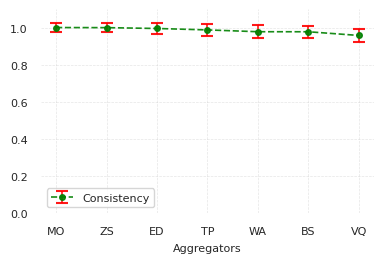


Plot created successfully!
Files saved as:
   /content/1. Relation_Consistency_Test1/consistency_average_sorted_highest_to_lowest.png
   /content/1. Relation_Consistency_Test1/consistency_average_sorted_highest_to_lowest.eps
   /content/1. Relation_Consistency_Test1/consistency_average_sorted_highest_to_lowest.pdf

 Sorted from HIGHEST to LOWEST correlation


In [ ]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

output_dir = "/content/1. Relation_Consistency_Test1"
os.makedirs(output_dir, exist_ok=True)

# Use overall_df_abs from your previous analysis
plot_df = overall_df_abs.copy()

short_names_map = {
    'Z-Score': 'ZS',
    'EDAS': 'ED',
    'MOORA': 'MO',
    'Borda': 'BS',
    'TOPSIS': 'TP',
    'WASPAS': 'WA',
    'VIKOR': 'VQ'
}

plot_df['Short_Method'] = plot_df['Method'].map(short_names_map)

# Normalize mean correlation (Overall_Mean_Correlation is already the average)
max_mean = plot_df['Overall_Mean_Correlation'].max()
plot_df['Norm_Mean'] = plot_df['Overall_Mean_Correlation'] / max_mean

# Compute error bars (standard deviation across Kendall, Pearson, Spearman)
plot_df['STD'] = plot_df[
    ['Mean_Kendall_τ', 'Mean_Pearson_r', 'Mean_Spearman_ρ']
].std(axis=1)

# Use absolute STD values for error bars
plot_df['Error_Value'] = plot_df['STD']

# ============ SORT FROM HIGHEST TO LOWEST CORRELATION ============
plot_df = plot_df.sort_values(
    by="Overall_Mean_Correlation",
    ascending=False  # Highest first
).reset_index(drop=True)

# Print the sorted order for verification
print("\nSorted order (highest to lowest correlation):")
for i, row in plot_df.iterrows():
    print(f"{i+1}. {row['Short_Method']}: {row['Overall_Mean_Correlation']:.4f}")

plt.figure(figsize=(4.0, 2.8))

# Print error bar values for debugging
print("\nError bar values (STD):")
for i, row in plot_df.iterrows():
    print(f"{row['Short_Method']}: Mean={row['Norm_Mean']:.3f}, Error={row['Error_Value']:.3f}")

# Consistency line with error bars (no variation line)
plt.errorbar(
    x=plot_df['Short_Method'],
    y=plot_df['Norm_Mean'],
    yerr=plot_df['Error_Value'],
    marker='o',
    linewidth=1.2,
    markersize=4,
    linestyle='--',
    color='green',
    label='Consistency',
    capsize=4,           # Larger caps for better visibility
    capthick=1.5,        # Thicker caps
    elinewidth=1.2,      # Thicker error bar lines
    ecolor='red',        # Red color makes error bars more visible
    alpha=0.9,
    fmt='o-'            # Explicit format string
)

plt.xlabel("Aggregators", fontsize=8, labelpad=5)

plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)
plt.ylim(0, 1.1)

# Keep one digit after decimal on y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Remove black border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=True, fontsize=8)

plt.tight_layout()

save_base = os.path.join(output_dir, "consistency_average_sorted_highest_to_lowest")

plt.savefig(f"{save_base}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_base}.eps", format="eps", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_base}.pdf", format="pdf", dpi=600, bbox_inches="tight")

plt.show()

print("\nPlot created successfully!")
print(f"Files saved as:\n   {save_base}.png\n   {save_base}.eps\n   {save_base}.pdf")
print("\n Sorted from HIGHEST to LOWEST correlation")

In [ ]:
# Install the below for Times New Roman
!apt-get install -y msttcorefonts
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'ttf-mscorefonts-installer' instead of 'msttcorefonts'
The following additional packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-pro-client-l10n ubuntu-release-upgrader-core update-manager-core
  update-notifier-common xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
The following NEW packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ttf-mscorefonts-installer
  ubuntu-advantage-tools ubuntu-pro-client ubuntu-pro-client-l10n
  ubuntu-release-upgrader-core update-manager-core update-notifier-common
  xfonts-encodings xfonts-utils zstd

##### 1.2.4 Figure: Heatmap Correlation between MCDM Aggregators and Base Metrics

LOADING DATA AND CREATING SORTED HEATMAP
→ Checking file...
→ File found. Loading correlation table...
→ Correlation table loaded! Shape: (7, 3)
→ Available columns: ['H1 (Mean)', 'H3 (Mean)', 'MRR (Mean)']

→ Plotting columns: ['H1', 'H3', 'MRR']

→ Correlation Table (Sorted: highest first):
             H1      H3     MRR
Method                         
MOORA    0.9542  0.9217  0.9996
Z-score  0.9488  0.9277  0.9973
EDAS     0.9656  0.9085  0.9867
TOPSIS   0.9453  0.9212  0.9720
WASPAS   0.9180  0.9186  0.9740
Borda    0.9348  0.9116  0.9634
VIKOR    0.9319  0.8842  0.9365

→ Heatmap saved to:
   /content/1. Relation_Consistency_Test1/heatmap_correlation_sorted.png
   /content/1. Relation_Consistency_Test1/heatmap_correlation_sorted.eps


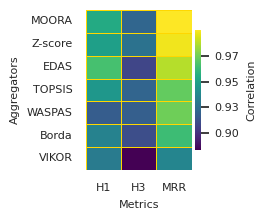


Heatmap created and saved successfully.
Aggregators sorted by mean correlation (best at top):
   1. MOORA: 0.9585
   2. Z-score: 0.9579
   3. EDAS: 0.9536
   4. TOPSIS: 0.9462
   5. WASPAS: 0.9369
   6. Borda: 0.9366
   7. VIKOR: 0.9175


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import matplotlib as mpl
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

def _ensure_consistency_tables(cdir="/content/1. Relation_Consistency_Test1"):
    """
    Guarantee that the correlation matrix files exist in `cdir`:
      - Table1_Kendall_Correlation_Matrix.csv
      - Table2_Pearson_Correlation_Matrix.csv
      - Table3_Spearman_Correlation_Matrix.csv
      - Table4_Overall_Correlation_Ranking.csv
      - Consistency_Correlation.csv
      - mean_correlation_table.csv
    They are rebuilt from mcdm_scores_table.csv if any are missing, so the
    consistency cells work regardless of execution order.
    """
    import os
    import pandas as pd
    import numpy as np
    from scipy.stats import kendalltau, pearsonr, spearmanr

    needed = [
        "Table1_Kendall_Correlation_Matrix.csv",
        "Table2_Pearson_Correlation_Matrix.csv",
        "Table3_Spearman_Correlation_Matrix.csv",
        "Table4_Overall_Correlation_Ranking.csv",
        "Consistency_Correlation.csv",
        "mean_correlation_table.csv",
    ]
    if all(os.path.exists(os.path.join(cdir, f)) for f in needed):
        return  # nothing to do

    scores_path = os.path.join(cdir, "mcdm_scores_table.csv")
    if not os.path.exists(scores_path):
        raise FileNotFoundError(
            "Cannot rebuild consistency tables: missing\n"
            f"  {scores_path}\n"
            "Please run the MCDM aggregation cell (Section 1.1) first."
        )

    scores = pd.read_csv(scores_path, index_col=0)

    mcdm_short_to_name = {
        "ED": "EDAS", "TP": "TOPSIS", "VQ": "VIKOR", "BS": "Borda",
        "ZS": "Z-Score", "MO": "MOORA", "WA": "WASPAS",
    }
    consensus_short_to_name = {
        "MRR": "Mean_MRR", "H1": "Mean_Hit@1", "H3": "Mean_Hit@3",
    }

    mcdm_cols = {nm: s for s, nm in mcdm_short_to_name.items() if s in scores.columns}
    cons_cols = {nm: s for s, nm in consensus_short_to_name.items() if s in scores.columns}

    rows = []
    for cons_name, cons_short in cons_cols.items():
        metric = scores[cons_short]
        for method_name, m_short in mcdm_cols.items():
            md = scores[m_short]
            mask = ~(md.isna() | metric.isna())
            if mask.sum() < 3:
                continue
            tau, _ = kendalltau(md[mask], metric[mask])
            r, _   = pearsonr(md[mask], metric[mask])
            rho, _ = spearmanr(md[mask], metric[mask])
            rows.append({
                "Target_Metric": cons_name, "Method": method_name,
                "Kendall_\u03c4": abs(tau), "Pearson_r": abs(r), "Spearman_\u03c1": abs(rho),
            })

    sdf = pd.DataFrame(rows)
    if sdf.empty:
        raise RuntimeError("Could not rebuild correlation tables (no valid pairs).")

    kendall_matrix  = sdf.pivot(index="Method", columns="Target_Metric", values="Kendall_\u03c4").abs()
    pearson_matrix  = sdf.pivot(index="Method", columns="Target_Metric", values="Pearson_r").abs()
    spearman_matrix = sdf.pivot(index="Method", columns="Target_Metric", values="Spearman_\u03c1").abs()

    os.makedirs(cdir, exist_ok=True)
    kendall_matrix.round(4).to_csv(os.path.join(cdir, "Table1_Kendall_Correlation_Matrix.csv"), float_format="%.4f")
    pearson_matrix.round(4).to_csv(os.path.join(cdir, "Table2_Pearson_Correlation_Matrix.csv"), float_format="%.4f")
    spearman_matrix.round(4).to_csv(os.path.join(cdir, "Table3_Spearman_Correlation_Matrix.csv"), float_format="%.4f")

    overall_rows = []
    for method in mcdm_cols:
        md = sdf[sdf["Method"] == method]
        mk, mp, ms = md["Kendall_\u03c4"].mean(), md["Pearson_r"].mean(), md["Spearman_\u03c1"].mean()
        overall_rows.append({
            "Method": method,
            "Mean_Kendall_\u03c4": mk, "Mean_Pearson_r": mp, "Mean_Spearman_\u03c1": ms,
            "Overall_Mean_Correlation": (mk + mp + ms) / 3,
        })
    odf = pd.DataFrame(overall_rows).sort_values("Overall_Mean_Correlation", ascending=False)
    odf.index = range(1, len(odf) + 1)
    odf.round(4).to_csv(os.path.join(cdir, "Table4_Overall_Correlation_Ranking.csv"), float_format="%.4f")

    short_map = {"Z-Score": "ZS", "EDAS": "ED", "MOORA": "MO", "Borda": "BS",
                 "TOPSIS": "TP", "WASPAS": "WA", "VIKOR": "VQ"}
    cons_exp = odf[["Method", "Overall_Mean_Correlation"]].copy()
    cons_exp["Short_Method"] = cons_exp["Method"].map(short_map)
    cons_exp = cons_exp.rename(columns={"Overall_Mean_Correlation": "Consistency_Correlation"})
    cons_exp[["Method", "Short_Method", "Consistency_Correlation"]].round(4).to_csv(
        os.path.join(cdir, "Consistency_Correlation.csv"), index=False, float_format="%.4f"
    )

    mean_corr = (kendall_matrix + pearson_matrix + spearman_matrix) / 3
    mean_corr = mean_corr.rename(columns={
        "Mean_MRR": "MRR (Mean)", "Mean_Hit@1": "H1 (Mean)", "Mean_Hit@3": "H3 (Mean)",
    })
    desired = ["H1 (Mean)", "H3 (Mean)", "MR (Mean)", "MRR (Mean)"]
    mean_corr = mean_corr[[c for c in desired if c in mean_corr.columns]]
    mean_corr = mean_corr.rename(index={
        "EDAS": "EDAS", "TOPSIS": "TOPSIS", "VIKOR": "VIKOR",
        "Borda": "Borda/AvgRank", "Z-Score": "Z", "MOORA": "MOORA", "WASPAS": "WASPAS",
    })
    morder = ["Z", "EDAS", "MOORA", "Borda/AvgRank", "TOPSIS", "VIKOR", "WASPAS"]
    mean_corr = mean_corr.loc[[m for m in morder if m in mean_corr.index]]
    mean_corr.round(4).to_csv(os.path.join(cdir, "mean_correlation_table.csv"), float_format="%.4f")
    print("\u2713 Rebuilt consistency correlation tables in:", cdir)


# Guarantee mean_correlation_table.csv exists regardless of run order.
_ensure_consistency_tables()




def setup_plot_style(font_size=8):
    mpl.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['DejaVu Serif', 'Times New Roman', 'Liberation Serif', 'serif'],
        'mathtext.fontset': 'stix',

        'font.size': font_size,
        'axes.labelsize': font_size,
        'axes.titlesize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'figure.titlesize': font_size,
    })

    sns.set_theme(
        style="white",
        font_scale=1.0,
        rc={
            'font.size': font_size,
            'axes.labelsize': font_size,
            'axes.titlesize': font_size,
            'xtick.labelsize': font_size,
            'ytick.labelsize': font_size,
            'legend.fontsize': font_size,
        }
    )


def load_and_plot_heatmap(
    file_path="/content/1. Relation_Consistency_Test1/mean_correlation_table.csv",
    save_dir="/content/1. Relation_Consistency_Test1",
    font_size=8
):
    print("→ Checking file...")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")

        alt_path = "/content/1. Relation_Consistency_Test1/mean_correlation_table.csv"
        if os.path.exists(alt_path):
            file_path = alt_path
            print(f"→ Found at alternative path: {file_path}")
        else:
            return None

    print("→ File found. Loading correlation table...")

    df = pd.read_csv(file_path, index_col=0)

    print(f"→ Correlation table loaded! Shape: {df.shape}")
    print(f"→ Available columns: {df.columns.tolist()}\n")

    short_names = {
        'H1 (Mean)': 'H1',
        'Mean_Hit@1': 'H1',
        'H3 (Mean)': 'H3',
        'Mean_Hit@3': 'H3',
        'MRR (Mean)': 'MRR',
        'Mean_MRR': 'MRR',
        'MR (Mean)': 'MR',
        'Mean_MR_inverted': 'MR'
    }

    df = df.rename(columns=short_names)

    desired = ['H1', 'H3', 'MRR', 'MR']
    available = [c for c in desired if c in df.columns]
    df = df[available]

    print(f"→ Plotting columns: {available}")

    df.index = df.index.str.replace('Z', 'Z-score', regex=False)
    df.index = df.index.str.replace('Borda/AvgRank', 'Borda', regex=False)

    df['Mean_Correlation'] = df.mean(axis=1)
    df = df.sort_values(by='Mean_Correlation', ascending=False)
    df = df.drop(columns=['Mean_Correlation'])

    print("\n→ Correlation Table (Sorted: highest first):")
    print(df.round(4))

    n_cols = len(df.columns)
    n_rows = len(df.index)

    fig_width = max(2.6, n_cols * 0.65)
    fig_height = max(2.2, n_rows * 0.32)

    plt.figure(figsize=(fig_width, fig_height))

    vmin, vmax = df.values.min(), df.values.max()
    cmap = plt.cm.viridis

    ax = sns.heatmap(
        df,
        annot=False,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={
            'label': 'Correlation',
            'shrink': 0.75,
            'pad': 0.03,
            'format': '%.2f'
        },
        linewidths=0.4,
        linecolor='gold',
        square=False
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=font_size)
    cbar.set_label('Correlation', fontsize=font_size, labelpad=5)

    plt.xlabel('Metrics', fontsize=font_size, labelpad=5)
    plt.ylabel('Aggregators', fontsize=font_size, labelpad=5)

    ax.tick_params(axis='x', labelsize=font_size, rotation=0)
    ax.tick_params(axis='y', labelsize=font_size, rotation=0)

    plt.tight_layout()

    os.makedirs(save_dir, exist_ok=True)

    base = f"{save_dir}/heatmap_correlation_sorted"

    plt.savefig(f"{base}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{base}.eps", format='eps', dpi=300, bbox_inches='tight')

    print(f"\n→ Heatmap saved to:")
    print(f"   {base}.png")
    print(f"   {base}.eps")

    plt.show()

    return df, ax


setup_plot_style(font_size=8)

print("=" * 70)
print("LOADING DATA AND CREATING SORTED HEATMAP")
print("=" * 70)

result = load_and_plot_heatmap(font_size=8)

if result is not None:
    df, ax = result

    print("\nHeatmap created and saved successfully.")
    print("Aggregators sorted by mean correlation (best at top):")

    mean_scores = df.mean(axis=1)

    for i, method in enumerate(df.index, 1):
        print(f"   {i}. {method}: {mean_scores[method]:.4f}")
else:
    print("\nHeatmap creation failed. Check that mean_correlation_table.csv exists.")

CREATING COMBINED FIGURE: CONSISTENCY (Left) + HEATMAP (Right)

Error bar values (STD):
ZS: Mean=0.999, Error=0.026
MO: Mean=1.000, Error=0.026
ED: Mean=0.995, Error=0.030
TP: Mean=0.987, Error=0.032
WA: Mean=0.977, Error=0.035
BS: Mean=0.977, Error=0.033
VQ: Mean=0.957, Error=0.037


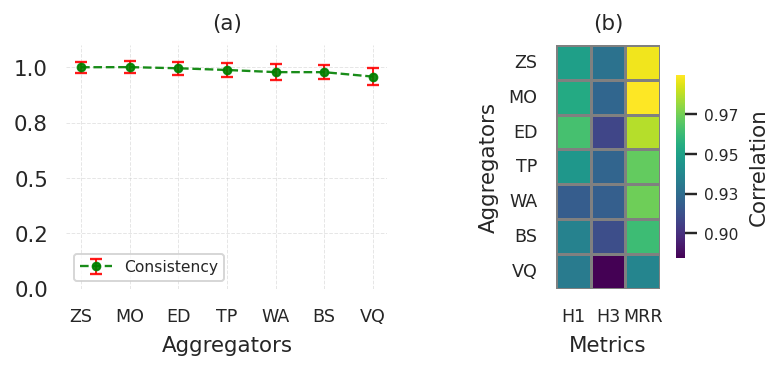


✅ COMBINED FIGURE CREATED SUCCESSFULLY!
Files saved as:
 /content/1. Relation_Consistency_Test1/combined_heatmap_consistency.png
 /content/1. Relation_Consistency_Test1/combined_heatmap_consistency.eps
 /content/1. Relation_Consistency_Test1/combined_heatmap_consistency.pdf


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import matplotlib as mpl
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

def _ensure_consistency_tables(cdir="/content/1. Relation_Consistency_Test1"):
    """
    Guarantee that the correlation matrix files exist in `cdir`:
      - Table1_Kendall_Correlation_Matrix.csv
      - Table2_Pearson_Correlation_Matrix.csv
      - Table3_Spearman_Correlation_Matrix.csv
      - Table4_Overall_Correlation_Ranking.csv
      - Consistency_Correlation.csv
      - mean_correlation_table.csv
    They are rebuilt from mcdm_scores_table.csv if any are missing, so the
    consistency cells work regardless of execution order.
    """
    import os
    import pandas as pd
    import numpy as np
    from scipy.stats import kendalltau, pearsonr, spearmanr

    needed = [
        "Table1_Kendall_Correlation_Matrix.csv",
        "Table2_Pearson_Correlation_Matrix.csv",
        "Table3_Spearman_Correlation_Matrix.csv",
        "Table4_Overall_Correlation_Ranking.csv",
        "Consistency_Correlation.csv",
        "mean_correlation_table.csv",
    ]
    if all(os.path.exists(os.path.join(cdir, f)) for f in needed):
        return  # nothing to do

    scores_path = os.path.join(cdir, "mcdm_scores_table.csv")
    if not os.path.exists(scores_path):
        raise FileNotFoundError(
            "Cannot rebuild consistency tables: missing\n"
            f"  {scores_path}\n"
            "Please run the MCDM aggregation cell (Section 1.1) first."
        )

    scores = pd.read_csv(scores_path, index_col=0)

    mcdm_short_to_name = {
        "ED": "EDAS", "TP": "TOPSIS", "VQ": "VIKOR", "BS": "Borda",
        "ZS": "Z-Score", "MO": "MOORA", "WA": "WASPAS",
    }
    consensus_short_to_name = {
        "MRR": "Mean_MRR", "H1": "Mean_Hit@1", "H3": "Mean_Hit@3",
    }

    mcdm_cols = {nm: s for s, nm in mcdm_short_to_name.items() if s in scores.columns}
    cons_cols = {nm: s for s, nm in consensus_short_to_name.items() if s in scores.columns}

    rows = []
    for cons_name, cons_short in cons_cols.items():
        metric = scores[cons_short]
        for method_name, m_short in mcdm_cols.items():
            md = scores[m_short]
            mask = ~(md.isna() | metric.isna())
            if mask.sum() < 3:
                continue
            tau, _ = kendalltau(md[mask], metric[mask])
            r, _   = pearsonr(md[mask], metric[mask])
            rho, _ = spearmanr(md[mask], metric[mask])
            rows.append({
                "Target_Metric": cons_name, "Method": method_name,
                "Kendall_\u03c4": abs(tau), "Pearson_r": abs(r), "Spearman_\u03c1": abs(rho),
            })

    sdf = pd.DataFrame(rows)
    if sdf.empty:
        raise RuntimeError("Could not rebuild correlation tables (no valid pairs).")

    kendall_matrix  = sdf.pivot(index="Method", columns="Target_Metric", values="Kendall_\u03c4").abs()
    pearson_matrix  = sdf.pivot(index="Method", columns="Target_Metric", values="Pearson_r").abs()
    spearman_matrix = sdf.pivot(index="Method", columns="Target_Metric", values="Spearman_\u03c1").abs()

    os.makedirs(cdir, exist_ok=True)
    kendall_matrix.round(4).to_csv(os.path.join(cdir, "Table1_Kendall_Correlation_Matrix.csv"), float_format="%.4f")
    pearson_matrix.round(4).to_csv(os.path.join(cdir, "Table2_Pearson_Correlation_Matrix.csv"), float_format="%.4f")
    spearman_matrix.round(4).to_csv(os.path.join(cdir, "Table3_Spearman_Correlation_Matrix.csv"), float_format="%.4f")

    overall_rows = []
    for method in mcdm_cols:
        md = sdf[sdf["Method"] == method]
        mk, mp, ms = md["Kendall_\u03c4"].mean(), md["Pearson_r"].mean(), md["Spearman_\u03c1"].mean()
        overall_rows.append({
            "Method": method,
            "Mean_Kendall_\u03c4": mk, "Mean_Pearson_r": mp, "Mean_Spearman_\u03c1": ms,
            "Overall_Mean_Correlation": (mk + mp + ms) / 3,
        })
    odf = pd.DataFrame(overall_rows).sort_values("Overall_Mean_Correlation", ascending=False)
    odf.index = range(1, len(odf) + 1)
    odf.round(4).to_csv(os.path.join(cdir, "Table4_Overall_Correlation_Ranking.csv"), float_format="%.4f")

    short_map = {"Z-Score": "ZS", "EDAS": "ED", "MOORA": "MO", "Borda": "BS",
                 "TOPSIS": "TP", "WASPAS": "WA", "VIKOR": "VQ"}
    cons_exp = odf[["Method", "Overall_Mean_Correlation"]].copy()
    cons_exp["Short_Method"] = cons_exp["Method"].map(short_map)
    cons_exp = cons_exp.rename(columns={"Overall_Mean_Correlation": "Consistency_Correlation"})
    cons_exp[["Method", "Short_Method", "Consistency_Correlation"]].round(4).to_csv(
        os.path.join(cdir, "Consistency_Correlation.csv"), index=False, float_format="%.4f"
    )

    mean_corr = (kendall_matrix + pearson_matrix + spearman_matrix) / 3
    mean_corr = mean_corr.rename(columns={
        "Mean_MRR": "MRR (Mean)", "Mean_Hit@1": "H1 (Mean)", "Mean_Hit@3": "H3 (Mean)",
    })
    desired = ["H1 (Mean)", "H3 (Mean)", "MR (Mean)", "MRR (Mean)"]
    mean_corr = mean_corr[[c for c in desired if c in mean_corr.columns]]
    mean_corr = mean_corr.rename(index={
        "EDAS": "EDAS", "TOPSIS": "TOPSIS", "VIKOR": "VIKOR",
        "Borda": "Borda/AvgRank", "Z-Score": "Z", "MOORA": "MOORA", "WASPAS": "WASPAS",
    })
    morder = ["Z", "EDAS", "MOORA", "Borda/AvgRank", "TOPSIS", "VIKOR", "WASPAS"]
    mean_corr = mean_corr.loc[[m for m in morder if m in mean_corr.index]]
    mean_corr.round(4).to_csv(os.path.join(cdir, "mean_correlation_table.csv"), float_format="%.4f")
    print("\u2713 Rebuilt consistency correlation tables in:", cdir)


# Guarantee mean_correlation_table.csv exists regardless of run order.
_ensure_consistency_tables()



# Short names for methods
METHOD_SHORT = {
    'EDAS': 'ED', 'TOPSIS': 'TP', 'VIKOR Q': 'VQ', 'VIKOR': 'VQ',
    'Borda Count': 'BS', 'Borda': 'BS', 'Borda/AvgRank': 'BS',
    'Z-score': 'ZS', 'Z-Score': 'ZS', 'ZMean': 'ZS', 'Zmean': 'ZS',
    'MOORA': 'MO', 'WASPAS': 'WA',
}

# ── STYLE SETUP ───────────────────────────────────────────────────
def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 140,
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

def load_and_prepare_heatmap_data(file_path="/content/1. Relation_Consistency_Test1/mean_correlation_table.csv"):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return None

    df = pd.read_csv(file_path, index_col=0)

    short_names = {
        'H1 (Mean)': 'H1', 'Mean_Hit@1': 'H1',
        'H3 (Mean)': 'H3', 'Mean_Hit@3': 'H3',
        'H10 (Mean)': 'H10', 'Mean_Hit@10': 'H10',
        'MR (Mean)': 'MR', 'Mean_MR': 'MR', 'Mean_MR_inverted': 'MR',
        'MRR (Mean)': 'MRR', 'Mean_MRR': 'MRR'
    }

    df = df.rename(columns=short_names)
    desired = ['H1', 'H3', 'H10', 'MR', 'MRR']
    available = [c for c in desired if c in df.columns]
    if not available:
        print("No matching metric columns found!")
        return None

    df = df[available]

    df.index = df.index.str.replace('Z', 'Z-score', regex=False)
    df.index = df.index.str.replace('Borda/AvgRank', 'Borda', regex=False)

    short_index = [METHOD_SHORT.get(name, name[:8] if len(name) > 8 else name) for name in df.index]
    df.index = short_index

    df['Mean_Correlation'] = df.mean(axis=1)
    if 'ZS' in df.index:
        zs_row = df.loc[['ZS']]
        rest = df.drop('ZS', errors='ignore').sort_values(by='Mean_Correlation', ascending=False)
        df = pd.concat([zs_row, rest])
    else:
        df = df.sort_values(by='Mean_Correlation', ascending=False)

    df = df.drop(columns=['Mean_Correlation'])
    return df


def prepare_consistency_data(df):
    if df is None:
        return None
    plot_df = df.copy()

    short_names_map = {
        'Z-Score': 'ZS', 'Z-score': 'ZS',
        'EDAS': 'ED', 'MOORA': 'MO', 'Borda': 'BS',
        'TOPSIS': 'TP', 'WASPAS': 'WA', 'VIKOR': 'VQ'
    }

    plot_df['Short_Method'] = plot_df['Method'].map(short_names_map)
    plot_df['Short_Method'] = plot_df['Short_Method'].fillna(plot_df['Method'].str[:2])

    max_mean = plot_df['Overall_Mean_Correlation'].max()
    plot_df['Norm_Mean'] = plot_df['Overall_Mean_Correlation'] / max_mean
    plot_df['STD'] = plot_df[['Mean_Kendall_τ', 'Mean_Pearson_r', 'Mean_Spearman_ρ']].std(axis=1)
    plot_df['Error_Value'] = plot_df['STD']

    if 'ZS' in plot_df['Short_Method'].values:
        zs_row = plot_df[plot_df['Short_Method'] == 'ZS']
        rest = plot_df[plot_df['Short_Method'] != 'ZS'].sort_values(by='Overall_Mean_Correlation', ascending=False)
        plot_df = pd.concat([zs_row, rest], ignore_index=True)
    else:
        plot_df = plot_df.sort_values(by='Overall_Mean_Correlation', ascending=False).reset_index(drop=True)

    return plot_df


# ====================== MAIN EXECUTION ======================
print("=" * 70)
print("CREATING COMBINED FIGURE: CONSISTENCY (Left) + HEATMAP (Right)")
print("=" * 70)

heatmap_df = load_and_prepare_heatmap_data()

if 'overall_df' in globals() and overall_df is not None:
    consistency_df = prepare_consistency_data(overall_df)
elif 'overall_df_abs' in globals() and overall_df_abs is not None:
    consistency_df = prepare_consistency_data(overall_df_abs)
else:
    print("\n 'overall_df' or 'overall_df_abs' is missing.")
    consistency_df = None

if heatmap_df is not None and consistency_df is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.8, 2.8), dpi=140)

    # LEFT: Consistency Plot
    print("\nError bar values (STD):")
    for i, row in consistency_df.iterrows():
        print(f"{row['Short_Method']}: Mean={row['Norm_Mean']:.3f}, Error={row['Error_Value']:.3f}")

    ax1.errorbar(
        x=consistency_df['Short_Method'], y=consistency_df['Norm_Mean'],
        yerr=consistency_df['Error_Value'],
        marker='o', linewidth=1.2, markersize=4, linestyle='--',
        color='green', label='Consistency',
        capsize=3, capthick=1.2, elinewidth=1.0,
        ecolor='red', alpha=0.9, fmt='o-'
    )

    ax1.set_xlabel("Aggregators", fontsize=11, labelpad=5)
    ax1.set_xticks(range(len(consistency_df)))
    ax1.set_xticklabels(consistency_df['Short_Method'], rotation=0, fontsize=9)
    ax1.set_ylim(0, 1.1)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    for spine in ax1.spines.values():
        spine.set_visible(False)
    ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax1.legend(frameon=True, fontsize=8, loc='best')
    ax1.set_title('(a)', fontsize=11, pad=8)

    # RIGHT: Heatmap
    vmin, vmax = heatmap_df.values.min(), heatmap_df.values.max()
    sns.heatmap(
        heatmap_df, annot=False, cmap=plt.cm.viridis,
        vmin=vmin, vmax=vmax,
        cbar_kws={'label': 'Correlation', 'shrink': 0.75, 'pad': 0.05},
        linewidths=0.6, linecolor='gray', square=True, ax=ax2
    )

    # === KEY CHANGE: Format colorbar to show 2 decimal places ===
    cbar = ax2.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('Correlation', fontsize=11, labelpad=5)
    # Force two digits after decimal point
    cbar.formatter = mticker.FormatStrFormatter('%.2f')
    cbar.update_ticks()

    ax2.set_xlabel('Metrics', fontsize=11, labelpad=5)
    ax2.set_ylabel('Aggregators', fontsize=11, labelpad=5)
    ax2.tick_params(axis='x', rotation=0, labelsize=9)
    ax2.tick_params(axis='y', rotation=0, labelsize=9)
    ax2.set_title('(b)', fontsize=11, pad=8)

    # Tight spacing
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05)

    # Save
    output_dir = "/content/1. Relation_Consistency_Test1"
    os.makedirs(output_dir, exist_ok=True)
    save_base = os.path.join(output_dir, "combined_heatmap_consistency")

    plt.savefig(f"{save_base}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{save_base}.eps", format="eps", dpi=300, bbox_inches="tight")
    plt.savefig(f"{save_base}.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

    print("\n" + "=" * 70)
    print("✅ COMBINED FIGURE CREATED SUCCESSFULLY!")
    print(f"Files saved as:\n {save_base}.png\n {save_base}.eps\n {save_base}.pdf")
    print("=" * 70)

else:
    print("\n Failed to create figure: Missing data.")

#### 1.2.4 Pairwise Kendall's Heatmap for MCDM Methods

Pairwise Kendall's τ correlation matrix:
        ED      TP      MO      BS      ZS      VQ      WA
ED  1.0000  0.9697  0.9697  0.9313  0.9697  0.8788  0.9394
TP  0.9697  1.0000  0.9394  0.9008  0.9394  0.8485  0.9091
MO  0.9697  0.9394  1.0000  0.9619  1.0000  0.9091  0.9697
BS  0.9313  0.9008  0.9619  1.0000  0.9619  0.9619  0.9313
ZS  0.9697  0.9394  1.0000  0.9619  1.0000  0.9091  0.9697
VQ  0.8788  0.8485  0.9091  0.9619  0.9091  1.0000  0.8788
WA  0.9394  0.9091  0.9697  0.9313  0.9697  0.8788  1.0000

Correlation range: 0.848 to 1.000

Custom order applied: ['ZS', 'MO', 'ED', 'WA', 'BS', 'TP', 'VQ']


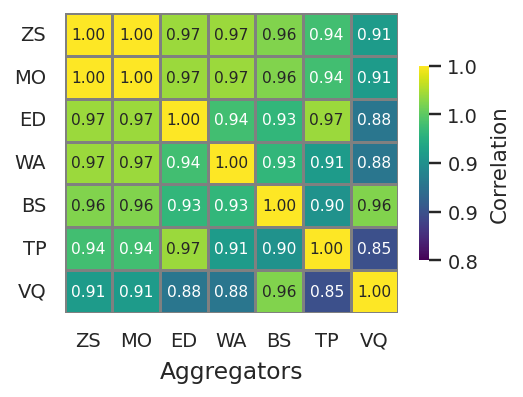


PLOT CREATED SUCCESSFULLY!
Heatmap saved with narrow borders + colorbar showing 1 decimal place.
Files saved as:
   /content/1. Relation_Consistency_Test1/heatmap_pairwise_kendall_custom_order_vmin08_with_border.png
   /content/1. Relation_Consistency_Test1/heatmap_pairwise_kendall_custom_order_vmin08_with_border.eps


In [ ]:
import os
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore", category=UserWarning)


def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)


def compute_kendall_tau_matrix(ranks: np.ndarray) -> np.ndarray:
    n_methods = ranks.shape[0]
    tau_matrix = np.zeros((n_methods, n_methods), dtype=float)

    for i in range(n_methods):
        for j in range(i, n_methods):
            tau, _ = kendalltau(ranks[i], ranks[j])
            tau_matrix[i, j] = tau
            tau_matrix[j, i] = tau

    np.fill_diagonal(tau_matrix, 1.0)
    return tau_matrix


def main() -> None:
    setup_plot_style()

    OUTDIR = "/content/1. Relation_Consistency_Test1"
    RANKS_FILE = os.path.join(OUTDIR, "mcdm_ranks_table.csv")

    rank_cols = ["ED_Rank", "TP_Rank", "MO_Rank", "BS_Rank", "ZS_Rank", "VQ_Rank", "WA_Rank"]
    method_names = ["EDAS", "TOPSIS", "MOORA", "Borda", "Z-Score", "VIKOR", "WASPAS"]
    short_names = ["ED", "TP", "MO", "BS", "ZS", "VQ", "WA"]

    custom_order = ["ZS", "MO", "ED", "WA", "BS", "TP", "VQ"]

    if not os.path.exists(RANKS_FILE):
        raise FileNotFoundError(f"File not found: {RANKS_FILE}")

    df_ranks = pd.read_csv(RANKS_FILE, index_col=0)
    df_ranks = df_ranks[rank_cols].copy()
    df_ranks.columns = method_names

    ranks = df_ranks.values.T
    tau_matrix = compute_kendall_tau_matrix(ranks)

    df_tau = pd.DataFrame(tau_matrix, index=short_names, columns=short_names)
    df_reordered = df_tau.loc[custom_order, custom_order]

    print("Pairwise Kendall's τ correlation matrix:")
    print(df_tau.round(4))
    print(f"\nCorrelation range: {tau_matrix.min():.3f} to {tau_matrix.max():.3f}")
    print(f"\nCustom order applied: {custom_order}")

    plt.figure(figsize=(4.4, 3.0))

    ax = sns.heatmap(
        df_reordered,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0.8,
        vmax=1.0,
        linewidths=0.6,
        linecolor="gray",
        annot_kws={"size": 8},
        cbar_kws={"label": "Correlation", "shrink": 0.65},
        square=False,
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    cbar.set_label("Correlation", fontsize=11, labelpad=6)

    plt.xlabel("Aggregators", fontsize=12, labelpad=5)

    ax.set_xticklabels(custom_order, rotation=0, ha="center", fontsize=10)
    ax.set_yticklabels(custom_order, rotation=0, va="center", fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(right=0.80)

    os.makedirs(OUTDIR, exist_ok=True)
    save_base = f"{OUTDIR}/heatmap_pairwise_kendall_custom_order_vmin08_with_border"

    plt.savefig(f"{save_base}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{save_base}.eps", format="eps", dpi=400, bbox_inches="tight")

    plt.show()

    print("\n" + "=" * 70)
    print("PLOT CREATED SUCCESSFULLY!")
    print("=" * 70)
    print("Heatmap saved with narrow borders + colorbar showing 1 decimal place.")
    print("Files saved as:")
    print(f"   {save_base}.png")
    print(f"   {save_base}.eps")


if __name__ == "__main__":
    main()

#### 1.3 Stability Test

In [ ]:
import pandas as pd
import numpy as np
import os

# ==========================================================
# ================ Load Pre-computed Ranks =================
# ==========================================================

ranks_path = "/content/1. Relation_Consistency_Test1/mcdm_ranks_table.csv"
df_ranks = pd.read_csv(ranks_path)
df_ranks = df_ranks.set_index('Models')

print(f"✓ Loaded pre-computed ranks: {df_ranks.shape[0]} models × {df_ranks.shape[1]} columns\n")

# Define MCDM rank columns
mcdm_methods_order = ['VQ_Rank', 'BS_Rank', 'ZS_Rank', 'WA_Rank', 'MO_Rank', 'ED_Rank', 'TP_Rank']
mcdm_methods_full = {
    'VQ_Rank': 'VIKOR Q',
    'BS_Rank': 'Borda',
    'ZS_Rank': 'Z-Score',
    'WA_Rank': 'WASPAS',
    'MO_Rank': 'MOORA',
    'ED_Rank': 'EDAS',
    'TP_Rank': 'TOPSIS'
}

consensus_cols = ['MRR_Rank', 'H1_Rank', 'H3_Rank']

# Keep only existing columns
mcdm_cols = [col for col in mcdm_methods_order if col in df_ranks.columns]
consensus_cols = [col for col in consensus_cols if col in df_ranks.columns]

print(f"Using consensus metrics for stability: {consensus_cols}\n")

# ==========================================================
# ================ Compute Variance per Method =============
# ==========================================================

variance_results = {}

for method_short in mcdm_cols:
    full_name = mcdm_methods_full.get(method_short, method_short.replace('_Rank', ''))

    model_variances = {}
    for model in df_ranks.index:
        ranks_across = df_ranks.loc[model, [method_short] + consensus_cols].values
        variance = np.var(ranks_across, ddof=0)
        model_variances[model] = round(variance, 3)

    variance_results[full_name] = model_variances

# Create variance DataFrame
variance_df = pd.DataFrame(variance_results, index=df_ranks.index)

# Add Mean Variance row
mean_variances = variance_df.mean().round(3)
variance_df.loc['Mean Variance'] = mean_variances

# ==========================================================
# ================ FINAL OVERALL TABLE =====================
# ==========================================================

overall_variance_df = pd.DataFrame(index=df_ranks.index)

for method in ['VIKOR Q', 'Borda', 'Z-Score', 'WASPAS', 'MOORA', 'EDAS', 'TOPSIS']:
    if method in variance_df.columns:
        overall_variance_df[method] = variance_df[method]

# Original mean variance
original_mean_var_series = overall_variance_df.mean().round(4)

# Normalized stability values
raw_mean_var_series = original_mean_var_series.copy()
inv_var = 1 / raw_mean_var_series.replace(0, np.inf)
max_inv = inv_var.max()

if max_inv == 0 or np.isinf(max_inv):
    normalized_mean = pd.Series(1.0, index=raw_mean_var_series.index)
else:
    normalized_mean = (
        inv_var / max_inv
    ).replace([np.inf, -np.inf], 0).fillna(0).round(4)

overall_variance_df.loc['Mean Variance'] = normalized_mean

# Sort models by average variance
model_avg_var = overall_variance_df.drop('Mean Variance').mean(axis=1)
sorted_models = model_avg_var.sort_values(ascending=True).index.tolist()
overall_variance_df = overall_variance_df.loc[sorted_models + ['Mean Variance']]

# Sort methods by normalized stability
method_mean_var = overall_variance_df.loc['Mean Variance'].to_dict()
sorted_methods = sorted(method_mean_var.items(), key=lambda x: x[1], reverse=True)
mcdm_methods_order = [m for m, v in sorted_methods]

# ==========================================================
# ================ SAVE NORMALIZED VALUES ONLY =============
# ==========================================================

outdir = "/content/2. Relation_Stability_Test2"
os.makedirs(outdir, exist_ok=True)

summary_data = [(m, method_mean_var[m]) for m in mcdm_methods_order]
summary_df = pd.DataFrame(summary_data, columns=['MCDM Method', 'stability'])
summary_df.index = range(1, len(summary_df) + 1)

summary_df.round(4).to_csv(
    f"{outdir}/stability.csv",
    index=False,
    float_format="%.4f"
)

# ===================== PRINT TABLE =====================
print("\n" + "="*100)
print("VARIANCE TABLE FOR ALL METRICS COMBINED")
print("="*100)
print("Variance of rankings for each knowledge graph embedding model across different metrics")
print("(MRR, Hit@1, Hit@3). Lower variance indicates higher ranking stability.")
print("→ Mean Variance row shows normalized stability (higher = more stable)")
print("-" * 100)

header_fmt = "{:20s}" + "".join([" {:>10s}"] * len(mcdm_methods_order))
print(header_fmt.format("Model", *mcdm_methods_order))
print("-" * (20 + 11 * len(mcdm_methods_order)))

for model in overall_variance_df.index:
    if model == 'Mean Variance':
        continue
    row = [model] + [f"{overall_variance_df.loc[model, m]:.3f}" for m in mcdm_methods_order]
    print(header_fmt.format(*row))

print("-" * (20 + 11 * len(mcdm_methods_order)))

mean_row = ["Mean Variance"] + [f"{overall_variance_df.loc['Mean Variance', m]:.4f}" for m in mcdm_methods_order]
print(header_fmt.format(*mean_row))
print("-" * (20 + 11 * len(mcdm_methods_order)))

max_value = max(method_mean_var.values())
max_methods = [m for m, v in method_mean_var.items() if abs(v - max_value) < 1e-6]
print(f"\n* = Most stable MCDM method(s): {', '.join(max_methods)} with normalized value {max_value:.4f}")

# ===================== SUMMARY TABLE =====================
print("\n" + "="*100)
print("MCDM METHODS RANKED BY STABILITY (Most to Least Stable)")
print("="*100)
print("NORMALIZED VALUES (higher = more stable):")
print(summary_df.round(4))

print(f"\n✓ Stability normalized values saved in: {outdir}/stability.csv")

✓ Loaded pre-computed ranks: 12 models × 10 columns

Using consensus metrics for stability: ['MRR_Rank', 'H1_Rank', 'H3_Rank']


VARIANCE TABLE FOR ALL METRICS COMBINED
Variance of rankings for each knowledge graph embedding model across different metrics
(MRR, Hit@1, Hit@3). Lower variance indicates higher ranking stability.
→ Mean Variance row shows normalized stability (higher = more stable)
----------------------------------------------------------------------------------------------------
Model                   Z-Score      MOORA       EDAS      Borda     WASPAS     TOPSIS    VIKOR Q
-------------------------------------------------------------------------------------------------
FMS                       0.000      0.000      0.000      0.000      0.000      0.000      0.000
PathCon                   0.000      0.000      0.000      0.000      0.000      0.000      0.000
Con                       0.000      0.000      0.000      0.000      0.000      0.000      0.000
DistMult   

##### 1.3.1 Visualization of BoxPlot

✓ Loaded pre-computed ranks: 12 models × 10 columns
Using consensus metrics for stability: ['MRR_Rank', 'H1_Rank', 'H3_Rank']


/tmp/ipykernel_2083/694426374.py:159: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(



✓ Aggregators sorted from lower stability to higher stability, with ZS moved to the end:
['VQ', 'WA', 'TP', 'BS', 'ED', 'MO', 'ZS']

✓ Normalized stability values:
VIKOR Q    0.7445
WASPAS     0.8652
TOPSIS     0.8652
Borda      0.9277
EDAS       0.9412
Z-Score    1.0000
MOORA      1.0000
dtype: float64

✓ Saved files:
/content/2. Relation_Stability_Test2/relation_stability_boxplot_sorted_low_to_high_zs_last.png
/content/2. Relation_Stability_Test2/relation_stability_boxplot_sorted_low_to_high_zs_last.pdf
/content/2. Relation_Stability_Test2/relation_stability_boxplot_sorted_low_to_high_zs_last.eps


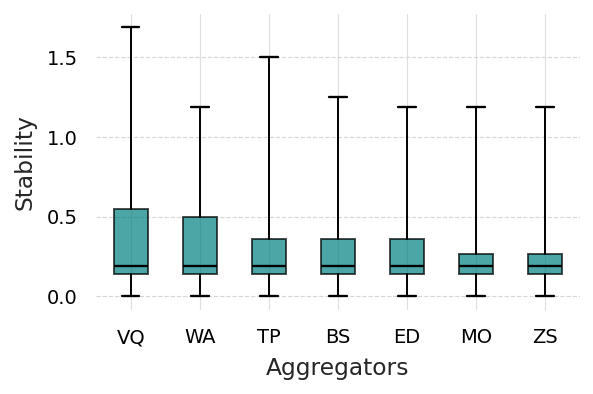

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)


def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)


def compute_relation_stability_variance(ranks_path: str):
    # ─── Load pre-computed rank table ────────────────────────────────────────
    df_ranks = pd.read_csv(ranks_path)
    df_ranks = df_ranks.set_index("Models")

    print(f"✓ Loaded pre-computed ranks: {df_ranks.shape[0]} models × {df_ranks.shape[1]} columns")

    # MCDM rank columns
    mcdm_methods_order = [
        "VQ_Rank",
        "BS_Rank",
        "ZS_Rank",
        "WA_Rank",
        "MO_Rank",
        "ED_Rank",
        "TP_Rank",
    ]

    mcdm_methods_full = {
        "VQ_Rank": "VIKOR Q",
        "BS_Rank": "Borda",
        "ZS_Rank": "Z-Score",
        "WA_Rank": "WASPAS",
        "MO_Rank": "MOORA",
        "ED_Rank": "EDAS",
        "TP_Rank": "TOPSIS",
    }

    consensus_cols = ["MRR_Rank", "H1_Rank", "H3_Rank"]

    # Keep only existing columns
    mcdm_cols = [col for col in mcdm_methods_order if col in df_ranks.columns]
    consensus_cols = [col for col in consensus_cols if col in df_ranks.columns]

    print(f"Using consensus metrics for stability: {consensus_cols}")

    # ─── Compute model-wise variance for each MCDM method ────────────────────
    variance_results = {}

    for method_short in mcdm_cols:
        full_name = mcdm_methods_full[method_short]

        model_variances = {}
        for model in df_ranks.index:
            ranks_across = df_ranks.loc[model, [method_short] + consensus_cols].values
            variance = np.var(ranks_across, ddof=0)
            model_variances[model] = round(variance, 3)

        variance_results[full_name] = model_variances

    overall_variance_df = pd.DataFrame(variance_results, index=df_ranks.index)

    # ─── Compute normalized mean stability for sorting only ──────────────────
    mean_variance = overall_variance_df.mean(axis=0)

    inv_variance = 1 / mean_variance.replace(0, np.inf)
    max_inv = inv_variance.max()

    if max_inv == 0 or np.isinf(max_inv):
        normalized_stability = pd.Series(1.0, index=mean_variance.index)
    else:
        normalized_stability = (
            inv_variance / max_inv
        ).replace([np.inf, -np.inf], 0).fillna(0)

    normalized_stability = normalized_stability.round(4)

    return overall_variance_df, normalized_stability


def main() -> None:
    setup_plot_style()

    # ─── Paths ───────────────────────────────────────────────────────────────
    ranks_path = "/content/1. Relation_Consistency_Test1/mcdm_ranks_table.csv"
    outdir = "/content/2. Relation_Stability_Test2/"
    os.makedirs(outdir, exist_ok=True)

    # ─── Compute relation stability variance dynamically ────────────────────
    overall_variance_df, normalized_stability = compute_relation_stability_variance(ranks_path)

    # Save computed tables
    overall_variance_df.to_csv(
        os.path.join(outdir, "relation_model_wise_variance.csv"),
        float_format="%.4f"
    )

    normalized_stability_df = (
        normalized_stability
        .sort_values(ascending=False)
        .reset_index()
    )
    normalized_stability_df.columns = ["MCDM Method", "stability"]

    normalized_stability_df.to_csv(
        os.path.join(outdir, "stability.csv"),
        index=False,
        float_format="%.4f"
    )

    # ─── Sort from lower stability to higher stability ───────────────────────
    plot_order = normalized_stability.sort_values(ascending=True).index.tolist()

    # ─── Move ZS / Z-Score to the end of the plot ────────────────────────────
    if "Z-Score" in plot_order:
        plot_order.remove("Z-Score")
        plot_order.append("Z-Score")

    # Short names for x-axis
    short_name_map = {
        "EDAS": "ED",
        "TOPSIS": "TP",
        "MOORA": "MO",
        "Borda": "BS",
        "Z-Score": "ZS",
        "VIKOR Q": "VQ",
        "WASPAS": "WA",
    }

    plot_labels = [short_name_map.get(method, method) for method in plot_order]

    # This plots the model-wise variance distribution for each aggregator.
    # Lower variance means higher stability.
    plot_data = [
        overall_variance_df[method].dropna().astype(float).values
        for method in plot_order
    ]

    # ─── Create box plot ─────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(4.4, 3.0), facecolor="white")
    ax.set_facecolor("white")

    bp = ax.boxplot(
        plot_data,
        labels=plot_labels,
        patch_artist=True,
        widths=0.5,
        showfliers=False,
        whis=(0, 100),
        boxprops=dict(
            facecolor="teal",
            edgecolor="black",
            linewidth=1.0,
            alpha=0.7,
        ),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.2),
    )

    for cap in bp["caps"]:
        cap.set_zorder(10)

    # ─── Labels ──────────────────────────────────────────────────────────────
    ax.set_xlabel("Aggregators", fontsize=12, labelpad=5)
    ax.set_ylabel("Stability", fontsize=12, labelpad=5)

    ax.tick_params(axis="x", labelrotation=0, labelsize=10, colors="black")
    ax.tick_params(axis="y", labelsize=10, colors="black")

    # Y-axis format
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

    # Grid
    ax.grid(True, axis="x", color="gray", alpha=0.25, linewidth=0.6)
    ax.grid(True, axis="y", linestyle="--", color="lightgray", alpha=0.9, linewidth=0.6)

    # Remove border
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()

    # ─── Save files ──────────────────────────────────────────────────────────
    png_path = os.path.join(outdir, "relation_stability_boxplot_sorted_low_to_high_zs_last.png")
    pdf_path = os.path.join(outdir, "relation_stability_boxplot_sorted_low_to_high_zs_last.pdf")
    eps_path = os.path.join(outdir, "relation_stability_boxplot_sorted_low_to_high_zs_last.eps")

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(eps_path, format="eps", bbox_inches="tight")

    print("\n✓ Aggregators sorted from lower stability to higher stability, with ZS moved to the end:")
    print([short_name_map.get(method, method) for method in plot_order])

    print("\n✓ Normalized stability values:")
    print(normalized_stability.sort_values(ascending=True).round(4))

    print("\n✓ Saved files:")
    print(png_path)
    print(pdf_path)
    print(eps_path)

    plt.show()


if __name__ == "__main__":
    main()

#### 1.4 Metric Dependency Test

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau, spearmanr, pearsonr
import os
import re

# ─── Configuration ───────────────────────────────────────────────────────────────
INPUT_FILE = "/content/Relation_pred_main_file.csv"
OUTDIR = "/content/3. Relation_Metric_Dependency_Test3/"
os.makedirs(OUTDIR, exist_ok=True)

MCDM_METHODS = ["Borda", "ZMean", "TOPSIS", "VIKOR", "EDAS", "MOORA", "WASPAS"]

METHOD_DISPLAY_MAP = {
    "Borda": "Borda",
    "ZMean": "Z-Mean",
    "TOPSIS": "TOPSIS",
    "VIKOR": "VIKOR",
    "EDAS": "EDAS",
    "MOORA": "MOORA",
    "WASPAS": "WASPAS",
}

METHOD_SHORT_MAP = {
    "Borda": "BS",
    "ZMean": "ZS",
    "TOPSIS": "TP",
    "VIKOR": "VQ",
    "EDAS": "ED",
    "MOORA": "MO",
    "WASPAS": "WA",
}


# ─── Core MCDM Runner ───────────────────────────────────────────────────────────
def run_mcdm(df_filtered):
    """
    Run all MCDM methods on a filtered dataframe.

    Assumption:
    The following local functions are already defined in a previous cell:
        - borda_count_local
        - zscore_average_local
        - topsis_local
        - vikor_local
        - edas_local
        - moora_local
        - waspas_local

    Output:
    All MCDM scores are transformed so that higher = better.
    """
    results = pd.DataFrame(index=df_filtered.index)

    # ─── Borda ────────────────────────────────────────────────────────────────
    results["Borda"] = borda_count_local(df_filtered)

    borda_max = results["Borda"].max()
    if borda_max == 0 or pd.isna(borda_max):
        results["Borda"] = 0.0
    else:
        results["Borda"] = (results["Borda"] / borda_max).round(4)

    # ─── Z-Mean ───────────────────────────────────────────────────────────────
    mean_z = zscore_average_local(df_filtered)

    epsilon = 0.001
    z_min = mean_z.min()
    z_max = mean_z.max()

    if z_max == z_min:
        mean_z = pd.Series([1.0] * len(mean_z), index=mean_z.index)
    else:
        t = (mean_z - z_min) / (z_max - z_min)
        mean_z = epsilon + (1 - epsilon) * t

    results["ZMean"] = mean_z.round(4)

    # ─── TOPSIS ───────────────────────────────────────────────────────────────
    results["TOPSIS"] = topsis_local(df_filtered).round(4)

    # ─── VIKOR ────────────────────────────────────────────────────────────────
    # Original VIKOR is usually lower = better.
    # This transformation converts it to higher = better.
    raw_vikor = vikor_local(df_filtered)

    vikor_min = raw_vikor.min()

    if pd.isna(vikor_min):
        results["VIKOR"] = np.nan
    else:
        if vikor_min == 0:
            vikor_min = 1e-6

        safe_raw_vikor = raw_vikor.replace(0, 1e-6)
        results["VIKOR"] = (vikor_min / safe_raw_vikor).round(4)

    # ─── EDAS, MOORA, WASPAS ─────────────────────────────────────────────────
    results["EDAS"] = edas_local(df_filtered).round(4)
    results["MOORA"] = moora_local(df_filtered).round(4)
    results["WASPAS"] = waspas_local(df_filtered).round(4)

    # ─── Ranks ────────────────────────────────────────────────────────────────
    # Since all scores are transformed to higher = better, all ranks use descending order.
    for col in MCDM_METHODS:
        results[f"{col}_R"] = results[col].rank(
            ascending=False,
            method="min"
        ).astype(int)

    return results.sort_values("WASPAS", ascending=False)


# ─── Robustness Metrics ─────────────────────────────────────────────────────────
def rank_correlation(baseline_ranks, new_ranks, method):
    """
    Calculate Kendall's tau and Spearman's rho between two rank sets.
    """
    r1 = baseline_ranks[f"{method}_R"]
    r2 = new_ranks[f"{method}_R"]

    tau = kendalltau(r1, r2)[0]
    rho = spearmanr(r1, r2)[0]

    return round(tau, 3), round(rho, 3)


def avg_abs_rank_change(baseline_ranks, new_ranks):
    """
    Calculate average absolute rank change for each MCDM method.
    """
    changes = {}

    for m in MCDM_METHODS:
        delta = (baseline_ranks[f"{m}_R"] - new_ranks[f"{m}_R"]).abs().mean()
        changes[m] = round(delta, 2)

    return changes


def top5_jaccard(baseline_df, new_df, method):
    """
    Calculate Jaccard similarity of top-5 models for a given MCDM method.

    All methods are higher = better after transformation, including VIKOR.
    """
    baseline_top5 = set(
        baseline_df.sort_values(method, ascending=False).index[:5]
    )

    new_top5 = set(
        new_df.sort_values(method, ascending=False).index[:5]
    )

    inter = len(baseline_top5 & new_top5)
    union = len(baseline_top5 | new_top5)

    return round(inter / union, 3) if union else 1.0


def score_correlation(baseline_df, new_df, method):
    """
    Compute Kendall, Pearson, and Spearman correlations between baseline
    and perturbed MCDM scores.
    """
    s1 = baseline_df[method]
    s2 = new_df[method]

    tau = kendalltau(s1, s2)[0]
    r = pearsonr(s1, s2)[0]
    rho = spearmanr(s1, s2)[0]

    return tau, r, rho


def score_delta_std(baseline_df, new_df, method):
    """
    Compute standard deviation of score changes between baseline and
    metric-removed scenario.

    Lower STD means the method's score changes are more stable.
    """
    s1 = baseline_df[method]
    s2 = new_df[method]

    delta = s2 - s1

    return delta.std(ddof=1)


# ─── Main Program ───────────────────────────────────────────────────────────────
print("\n" + "═" * 100)
print("ROBUSTNESS TEST – LEAVE-ONE-METRIC-FAMILY-OUT (RELATION PREDICTION)")
print("═" * 100)

# Load data
df = pd.read_csv(INPUT_FILE)

# Set model index
first_column = df.columns[0]
df = df.set_index(first_column)

if first_column != "Model":
    df.index.name = "Model"

# Get all metric columns
all_columns = df.columns.tolist()

# ─── Identify Dataset Identifiers ──────────────────────────────────────────────
print("\n" + "-" * 60)
print("ANALYZING METRIC STRUCTURE")
print("-" * 60)

datasets = set()

for col in all_columns:
    match = re.search(r"_d([0-4])$", col)
    if match:
        datasets.add(f"d{match.group(1)}")

datasets = sorted(list(datasets))

print(f"\nFound datasets: {datasets}")

# ─── Categorize Metric Families (AUTO-DETECTED) ────────────────────────────────
# Relation prediction data contains only MRR, H@1, H@3 (no MR, no H@10).
# Detect the family of every column from its prefix instead of hard-coding,
# so the leave-one-metric-family-out analysis works on whatever metrics exist.
import re as _re_fam

def _family_of(col):
    base = _re_fam.sub(r"_d\d+$", "", col)   # strip the _d<k> dataset suffix
    return base

metric_families = {}
for col in all_columns:
    fam = _family_of(col)
    metric_families.setdefault(fam, []).append(col)

# Keep a stable, human-friendly ordering of families
_preferred_order = ["MR", "MRR", "H@1", "H@3", "H@5", "H@10"]
metric_families = {
    fam: metric_families[fam]
    for fam in (
        [f for f in _preferred_order if f in metric_families]
        + [f for f in metric_families if f not in _preferred_order]
    )
}

print("\nAuto-detected metric families:", {k: len(v) for k, v in metric_families.items()})

print("\n" + "-" * 60)
print("METRICS FOUND IN THE DATASET")
print("-" * 60)

for family, cols in metric_families.items():
    print(f"\n{family}: {len(cols)} metrics")

    if cols:
        for col in sorted(cols):
            print(f"  - {col}")

print("\n" + "-" * 60)
print("VERIFICATION")
print("-" * 60)

for family, cols in metric_families.items():
    expected = len(datasets)
    actual = len(cols)

    status = (
        "✓ CORRECT"
        if actual == expected
        else f"✗ CHECK: Expected {expected}, got {actual}"
    )

    print(f"{family}: {actual} metrics - {status}")


# ─── Define Robustness Scenarios (built from detected families) ─────────────────
_families_present = [fam for fam, cols in metric_families.items() if cols]

scenarios = [("Baseline (all metrics)", None)]
for fam in _families_present:
    scenarios.append((f"Without {fam}", fam))

removed_labels = [f"Without {fam}" for fam in _families_present]
scenario_to_metric = {f"Without {fam}": fam for fam in _families_present}

print("Scenarios:", [name for name, _ in scenarios])

results_storage = {}
baseline = None


# ─── Run MCDM Analysis for Each Scenario ───────────────────────────────────────
print("\n" + "═" * 100)
print("RUNNING MCDM ANALYSIS FOR EACH SCENARIO")
print("═" * 100)

for name, exclude_family in scenarios:
    print(f"\n► {name}")
    print("-" * 60)

    if exclude_family is None:
        cols = df.columns.tolist()
        print(f"   → Using ALL {len(cols)} metrics")
    else:
        exclude_cols = metric_families[exclude_family]
        cols = [c for c in df.columns if c not in exclude_cols]

        print(
            f"   → Using {len(cols)} metrics "
            f"(excluding {len(exclude_cols)} {exclude_family} metrics)"
        )
        print(f"   → Excluded metrics: {exclude_cols}")

    df_sub = df[cols].copy()
    res = run_mcdm(df_sub)

    results_storage[name] = res

    score_cols = MCDM_METHODS
    rank_cols = [f"{m}_R" for m in MCDM_METHODS]

    filename_safe = (
        name.replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("@", "")
            .replace("-", "")
    )

    res[score_cols].round(4).to_csv(
        f"{OUTDIR}{filename_safe}_scores.csv"
    )

    res[rank_cols].to_csv(
        f"{OUTDIR}{filename_safe}_ranks.csv"
    )

    print(
        f"   ✓ Saved: "
        f"{filename_safe}_scores.csv & {filename_safe}_ranks.csv"
    )

    print("\n   First 5 models sorted by WASPAS:")
    print("-" * 80)

    display_df = res.head(5)[score_cols + rank_cols]
    print(display_df.round(4))

    if exclude_family is None:
        baseline = res


# ─── Robustness Summary ────────────────────────────────────────────────────────
print("\n" + "═" * 100)
print("ROBUSTNESS SUMMARY – COMPARISON WITH BASELINE")
print("═" * 100)

kendall_df = pd.DataFrame(
    index=removed_labels,
    columns=MCDM_METHODS,
    dtype=float
)

spearman_df = pd.DataFrame(
    index=removed_labels,
    columns=MCDM_METHODS,
    dtype=float
)

delta_df = pd.DataFrame(
    index=removed_labels,
    columns=MCDM_METHODS + ["Avg"],
    dtype=float
)

jaccard_df = pd.DataFrame(
    index=removed_labels,
    columns=MCDM_METHODS + ["Avg"],
    dtype=float
)

for scen in removed_labels:
    deltas = avg_abs_rank_change(baseline, results_storage[scen])

    for m in MCDM_METHODS:
        tau, rho = rank_correlation(baseline, results_storage[scen], m)

        kendall_df.loc[scen, m] = tau
        spearman_df.loc[scen, m] = rho
        delta_df.loc[scen, m] = deltas[m]
        jaccard_df.loc[scen, m] = top5_jaccard(
            baseline,
            results_storage[scen],
            m
        )

    delta_df.loc[scen, "Avg"] = round(
        delta_df.loc[scen, MCDM_METHODS].mean(),
        2
    )

    jaccard_df.loc[scen, "Avg"] = round(
        jaccard_df.loc[scen, MCDM_METHODS].mean(),
        3
    )

print("\n1. Kendall's τ (higher = more similar ranking)")
print(kendall_df.round(3))

print("\n2. Spearman's ρ (higher = more similar ranking)")
print(spearman_df.round(3))

print("\n3. Average absolute rank change |ΔRank| (lower = more robust)")
print(delta_df.round(2))

print("\n4. Top-5 Jaccard similarity (1.0 = identical top-5)")
print(jaccard_df.round(3))

# Save robustness summary files
kendall_df.round(4).to_csv(f"{OUTDIR}rank_corr_kendall.csv")
spearman_df.round(4).to_csv(f"{OUTDIR}rank_corr_spearman.csv")
delta_df.round(4).to_csv(f"{OUTDIR}average_absolute_rank_change.csv")
jaccard_df.round(4).to_csv(f"{OUTDIR}top5_jaccard_similarity.csv")


# ─── Create Table 1: Average Absolute Rank Change ──────────────────────────────
print("\n" + "═" * 100)
print("AVERAGE ABSOLUTE RANK CHANGE UNDER METRIC REMOVAL")
print("═" * 100)

table_data = {}

for metric_short in _families_present:
    table_data[metric_short] = {}

for scen in removed_labels:
    metric_short = scenario_to_metric[scen]
    deltas = avg_abs_rank_change(baseline, results_storage[scen])

    for m in MCDM_METHODS:
        display_name = METHOD_DISPLAY_MAP[m]
        table_data[metric_short][display_name] = deltas[m]

avg_rank_change_table = pd.DataFrame(table_data).T

# Add Avg. row for column-wise averages
avg_values = {}

for method in avg_rank_change_table.columns:
    avg_values[method] = round(avg_rank_change_table[method].mean(), 2)

avg_rank_change_table.loc["Avg."] = avg_values

# Add Avg. column for row-wise averages
avg_rank_change_table["Avg."] = avg_rank_change_table.mean(axis=1).round(2)

# Sort method columns by average impact, descending
method_impacts = {}

for method in avg_rank_change_table.columns:
    if method != "Avg.":
        impact = avg_rank_change_table.loc[
            avg_rank_change_table.index != "Avg.",
            method
        ].mean()

        method_impacts[method] = impact

sorted_methods = sorted(
    method_impacts.items(),
    key=lambda x: x[1],
    reverse=True
)

sorted_method_names = [method[0] for method in sorted_methods]

avg_rank_change_table = avg_rank_change_table[
    sorted_method_names + ["Avg."]
]

avg_rank_change_table = avg_rank_change_table.loc[
    _families_present + ["Avg."]
]

print(
    "\nTable 1: Average absolute rank change (|ΔRank|) "
    "per MCDM method, sorted by average impact"
)
print("-" * 100)
print(avg_rank_change_table.round(2).to_string())

avg_rank_change_table.round(2).to_csv(
    f"{OUTDIR}table1_average_absolute_rank_change.csv"
)


# ─── Table 2: Robustness Impact Summary ────────────────────────────────────────
print("\n" + "═" * 100)
print("IDENTIFICATION OF MOST DISRUPTIVE METRICS")
print("═" * 100)

robustness_summary = []

for scen in removed_labels:
    metric_short = scenario_to_metric[scen]

    deltas = avg_abs_rank_change(baseline, results_storage[scen])
    avg_displacement = round(np.mean(list(deltas.values())), 2)

    spearman_values = []

    for m in MCDM_METHODS:
        _, rho = rank_correlation(baseline, results_storage[scen], m)
        spearman_values.append(rho)

    avg_spearman = round(np.mean(spearman_values), 4)

    robustness_summary.append({
        "Removed Metric": metric_short,
        "Avg. Rank Displacement": avg_displacement,
        "Spearman Rank Correlation": avg_spearman,
    })

robustness_df = pd.DataFrame(robustness_summary)

robustness_df = robustness_df.sort_values(
    "Avg. Rank Displacement",
    ascending=False
)

print("\nTable 2: Robustness impact summary based on metric removal")
print("-" * 80)
print(robustness_df.to_string(index=False))

robustness_df.to_csv(
    f"{OUTDIR}table2_robustness_impact_summary.csv",
    index=False
)


# ─── Score-Level Delta Correlation Analysis ────────────────────────────────────
print("\n" + "═" * 100)
print("DELTA CORRELATION ANALYSIS (SCORE-LEVEL CONSISTENCY)")
print("═" * 100)

corr_results = []

for scen in removed_labels:
    for m in MCDM_METHODS:
        tau, r, rho = score_correlation(
            baseline,
            results_storage[scen],
            m
        )

        corr_results.append({
            "Scenario": scen,
            "Method": m,
            "Kendall_τ": tau,
            "Pearson_r": r,
            "Spearman_ρ": rho,
        })

corr_df = pd.DataFrame(corr_results)

kendall_corr = corr_df.pivot(
    index="Method",
    columns="Scenario",
    values="Kendall_τ"
)

pearson_corr = corr_df.pivot(
    index="Method",
    columns="Scenario",
    values="Pearson_r"
)

spearman_corr = corr_df.pivot(
    index="Method",
    columns="Scenario",
    values="Spearman_ρ"
)

print("\n1. Kendall τ (Score-Level Correlation)")
print(kendall_corr.round(3))

print("\n2. Pearson r (Score-Level Correlation)")
print(pearson_corr.round(3))

print("\n3. Spearman ρ (Score-Level Correlation)")
print(spearman_corr.round(3))


# ─── Overall Delta Correlation Ranking ─────────────────────────────────────────
print("\n" + "═" * 100)
print("OVERALL DELTA CORRELATION RANKING")
print("═" * 100)

overall_corr = []

for m in MCDM_METHODS:
    method_data = corr_df[corr_df["Method"] == m]

    mean_tau = method_data["Kendall_τ"].mean()
    mean_r = method_data["Pearson_r"].mean()
    mean_rho = method_data["Spearman_ρ"].mean()

    overall_mean = (mean_tau + mean_r + mean_rho) / 3

    overall_corr.append({
        "Method": m,
        "Display Method": METHOD_DISPLAY_MAP[m],
        "Mean_Kendall_τ": mean_tau,
        "Mean_Pearson_r": mean_r,
        "Mean_Spearman_ρ": mean_rho,
        "Overall_Correlation": overall_mean,
    })

overall_corr_df = pd.DataFrame(overall_corr)

overall_corr_df = overall_corr_df.sort_values(
    "Overall_Correlation",
    ascending=False
)

overall_corr_df.index = range(1, len(overall_corr_df) + 1)

print("\nMCDM Methods Ranked by Delta Correlation (Score Stability):")
print("-" * 90)
print(overall_corr_df.round(4))


# ─── Overall Score-Delta Standard Deviation Analysis ───────────────────────────
print("\n" + "═" * 100)
print("OVERALL SCORE-DELTA STANDARD DEVIATION ANALYSIS")
print("═" * 100)

std_results = []

for scen in removed_labels:
    for m in MCDM_METHODS:
        std_val = score_delta_std(
            baseline,
            results_storage[scen],
            m
        )

        std_results.append({
            "Scenario": scen,
            "Method": m,
            "Score_Delta_STD": std_val,
        })

std_df = pd.DataFrame(std_results)

std_matrix = std_df.pivot(
    index="Method",
    columns="Scenario",
    values="Score_Delta_STD"
)

print("\nScore-Delta STD Matrix")
print("-" * 80)
print(std_matrix.round(6))

overall_std = []

for m in MCDM_METHODS:
    method_data = std_df[std_df["Method"] == m]

    mean_std = method_data["Score_Delta_STD"].mean()

    overall_std.append({
        "Method": m,
        "Display Method": METHOD_DISPLAY_MAP[m],
        "Overall_STD": mean_std,
    })

overall_std_df = pd.DataFrame(overall_std)

overall_std_df = overall_std_df.sort_values(
    "Overall_STD",
    ascending=True
)

overall_std_df.index = range(1, len(overall_std_df) + 1)

print("\nMCDM Methods Ranked by Overall Score-Delta STD")
print("(lower STD = more stable)")
print("-" * 80)
print(overall_std_df.round(6))


# ─── Save Delta Correlation and STD Files ──────────────────────────────────────
kendall_corr.round(4).to_csv(
    f"{OUTDIR}delta_corr_kendall.csv"
)

pearson_corr.round(4).to_csv(
    f"{OUTDIR}delta_corr_pearson.csv"
)

spearman_corr.round(4).to_csv(
    f"{OUTDIR}delta_corr_spearman.csv"
)

overall_corr_df.round(4).to_csv(
    f"{OUTDIR}delta_corr_overall.csv",
    index=True
)

std_matrix.round(6).to_csv(
    f"{OUTDIR}score_delta_std_matrix.csv"
)

overall_std_df.round(6).to_csv(
    f"{OUTDIR}score_delta_std_overall.csv",
    index=True
)

print("\n✓ Delta correlation and STD files saved:")
print("   - delta_corr_kendall.csv")
print("   - delta_corr_pearson.csv")
print("   - delta_corr_spearman.csv")
print("   - delta_corr_overall.csv")
print("   - score_delta_std_matrix.csv")
print("   - score_delta_std_overall.csv")


# ─── Table 3: Most Disruptive Metric per Aggregator ────────────────────────────
print("\n" + "═" * 100)
print("MOST DISRUPTIVE METRIC PER MCDM METHOD")
print("═" * 100)

disruptive_metrics = []

for m in MCDM_METHODS:
    method_deltas = []

    for scen in removed_labels:
        metric_short = scenario_to_metric[scen]
        deltas = avg_abs_rank_change(baseline, results_storage[scen])
        method_deltas.append((metric_short, deltas[m]))

    max_metric = max(method_deltas, key=lambda x: x[1])

    disruptive_metrics.append({
        "MCDM Method": METHOD_DISPLAY_MAP[m],
        "Short": METHOD_SHORT_MAP[m],
        "Most Disruptive Metric": max_metric[0],
        "Avg. |ΔRank|": max_metric[1],
        "Impact Level": (
            "High" if max_metric[1] >= 0.5
            else "Medium" if max_metric[1] >= 0.3
            else "Low"
        ),
    })

disruptive_df = pd.DataFrame(disruptive_metrics)

print("\nTable 3: Most disruptive metric for each MCDM method")
print("-" * 80)
print(disruptive_df.to_string(index=False))

disruptive_df.to_csv(
    f"{OUTDIR}table3_most_disruptive_metric_per_method.csv",
    index=False
)


# ─── Overall Robustness Ranking ────────────────────────────────────────────────
print("\n" + "═" * 100)
print("OVERALL ROBUSTNESS RANKING OF MCDM METHODS")
print("═" * 100)

robustness_scores = {}

for m in MCDM_METHODS:
    total_delta = 0
    count = 0

    for scen in removed_labels:
        deltas = avg_abs_rank_change(baseline, results_storage[scen])
        total_delta += deltas[m]
        count += 1

    robustness_scores[METHOD_DISPLAY_MAP[m]] = total_delta / count

robustness_ranking = sorted(
    robustness_scores.items(),
    key=lambda x: x[1]
)

print("\nRanking of MCDM methods by robustness (most robust first):")
print("-" * 70)

for rank, (method, score) in enumerate(robustness_ranking, 1):
    print(f"{rank:2d}. {method:10s}: Average |ΔRank| = {score:.3f}")

ranking_df = pd.DataFrame({
    "Rank": range(1, len(robustness_ranking) + 1),
    "MCDM Method": [item[0] for item in robustness_ranking],
    "Average |ΔRank|": [round(item[1], 3) for item in robustness_ranking],
})

ranking_df.to_csv(
    f"{OUTDIR}overall_robustness_ranking.csv",
    index=False
)

print("\n✓ Saved: overall_robustness_ranking.csv")


# ─── Normalized Robustness Scores ──────────────────────────────────────────────
# Higher normalized score = more robust.
raw_scores = pd.Series(robustness_scores)

if (raw_scores == 0).any():
    # If any method has zero rank displacement, it is perfectly stable.
    # Give zero-displacement methods the maximum normalized score.
    inv_scores = 1 / raw_scores.replace(0, np.nan)

    if inv_scores.dropna().empty:
        normalized_scores_series = pd.Series(
            1.0,
            index=raw_scores.index
        )
    else:
        normalized_scores_series = inv_scores / inv_scores.max()
        normalized_scores_series = normalized_scores_series.fillna(1.0)
else:
    inv_scores = 1 / raw_scores
    normalized_scores_series = inv_scores / inv_scores.max()

normalized_scores_series = normalized_scores_series.round(3)

print("\nNormalized Robustness Scores (higher = more robust):")
print("-" * 70)

for method, score in robustness_ranking:
    norm = normalized_scores_series[method]
    print(f"{method:10s}: {norm:.3f}")

normalized_df = pd.DataFrame({
    "MCDM Method": [item[0] for item in robustness_ranking],
    "Normalized Robustness Score": [
        normalized_scores_series[item[0]]
        for item in robustness_ranking
    ],
})

normalized_df.to_csv(
    f"{OUTDIR}normalized_robustness.csv",
    index=False
)

print("\n✓ Saved: normalized_robustness.csv")


# ─── Final Summary Statistics ─────────────────────────────────────────────────
print("\n" + "═" * 100)
print("SUMMARY STATISTICS")
print("═" * 100)

print("\nMetrics used in analysis:")
print("-" * 50)

for family, cols in metric_families.items():
    print(f"{family}: {len(cols)} metrics across datasets {datasets}")

print(f"\nTotal metrics: {len(df.columns)}")
print(f"Total models: {len(df)}")
print(f"Datasets analyzed: {', '.join(datasets)}")

print("\n" + "═" * 100)
print("All tables printed above.")
print("Individual CSV files saved in:", OUTDIR)
print("✓ Relation prediction robustness analysis complete!")


# ─── SAVE dependency.csv DIRECTLY (for the final NFL aggregation cell) ─────────
# Mirrors the Tail notebook's metric-independency output: a single normalized
# higher-is-better column. We reuse the already-computed normalized robustness
# scores (1 / mean |ΔRank|, max-normalized) as the independency score.
_dep_short = {
    "Borda": "BS", "Z-Mean": "ZS", "Z-Score": "ZS", "TOPSIS": "TP",
    "VIKOR": "VQ", "EDAS": "ED", "MOORA": "MO", "WASPAS": "WA"
}
dependency_export = pd.DataFrame({
    "Method": list(normalized_scores_series.index),
    "dependency": [round(float(v), 4) for v in normalized_scores_series.values],
})
dependency_export["Short"] = dependency_export["Method"].map(
    lambda x: _dep_short.get(x, x[:2])
)
dependency_export = dependency_export[["Method", "Short", "dependency"]]
dependency_export.to_csv(
    f"{OUTDIR}dependency.csv",
    index=False,
    float_format="%.4f"
)
print(f"\n✓ Also saved: {OUTDIR}dependency.csv")



════════════════════════════════════════════════════════════════════════════════════════════════════
ROBUSTNESS TEST – LEAVE-ONE-METRIC-FAMILY-OUT (RELATION PREDICTION)
════════════════════════════════════════════════════════════════════════════════════════════════════

------------------------------------------------------------
ANALYZING METRIC STRUCTURE
------------------------------------------------------------

Found datasets: ['d0', 'd1', 'd2', 'd3', 'd4']

Auto-detected metric families: {'MRR': 6, 'H@1': 6, 'H@3': 6}

------------------------------------------------------------
METRICS FOUND IN THE DATASET
------------------------------------------------------------

MRR: 6 metrics
  - MRR_d0
  - MRR_d1
  - MRR_d2
  - MRR_d3
  - MRR_d4
  - MRR_d5

H@1: 6 metrics
  - H@1_d0
  - H@1_d1
  - H@1_d2
  - H@1_d3
  - H@1_d4
  - H@1_d5

H@3: 6 metrics
  - H@3_d0
  - H@3_d1
  - H@3_d2
  - H@3_d3
  - H@3_d4
  - H@3_d5

------------------------------------------------------------
VERIFICA

##### 1.4.1 Metric Elimination Robustness Visualization


════════════════════════════════════════════════════════════════════════════════════════════════════
CREATING RELATION PREDICTION ROBUSTNESS-CORRELATION PLOT
════════════════════════════════════════════════════════════════════════════════════════════════════

Values used for plotting:
--------------------------------------------------------------------------------
Method Short  Normalized Robustness  Raw Overall Correlation  dependency
  EDAS    ED                  0.202                   0.9549      0.9549
WASPAS    WA                  0.205                   0.9973      0.9973
TOPSIS    TP                  0.254                   0.9383      0.9383
 MOORA    MO                  0.258                   0.9629      0.9629
 Borda    BS                  0.293                   0.9778      0.9778
 VIKOR    VQ                  1.000                   1.0000      1.0000
Z-Mean    ZS                  1.000                   0.9702      0.9702

Dependency normalized values saved to: /content

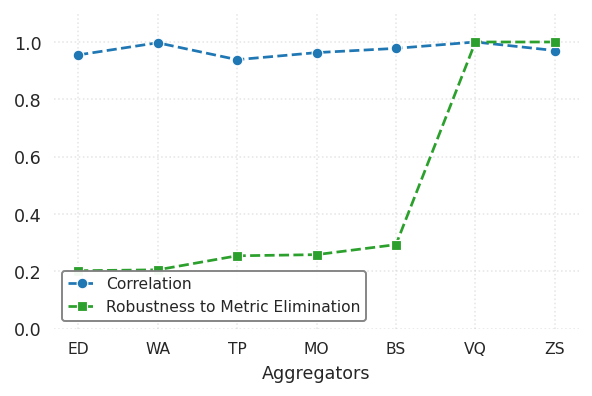


Relation prediction robustness-correlation plot created successfully!
Files saved as:
   /content/3. Relation_Metric_Dependency_Test3/relation_normalized_robustness_correlation_low_to_high.png
   /content/3. Relation_Metric_Dependency_Test3/relation_normalized_robustness_correlation_low_to_high.eps
   /content/3. Relation_Metric_Dependency_Test3/relation_normalized_robustness_correlation_low_to_high.pdf
   /content/3. Relation_Metric_Dependency_Test3/dependency.csv


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

warnings.filterwarnings("ignore", category=UserWarning)


# ─── Plot Style ────────────────────────────────────────────────────────────────
def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "DejaVu Serif",
            "Times New Roman",
            "Liberation Serif",
            "serif"
        ],
        "mathtext.fontset": "stix",
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 8,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 11,
        "font.weight": "normal",
        "axes.labelweight": "normal",
        "figure.dpi": 140,
    })

    sns.set_theme(style="white", font_scale=1.0)


setup_plot_style()


print("\n" + "═" * 100)
print("CREATING RELATION PREDICTION ROBUSTNESS-CORRELATION PLOT")
print("═" * 100)


# ─── Output Directory ──────────────────────────────────────────────────────────
plots_dir = "/content/3. Relation_Metric_Dependency_Test3"
os.makedirs(plots_dir, exist_ok=True)


# ─── Input Files from Relation Robustness Analysis ─────────────────────────────
normalized_robustness_file = os.path.join(
    plots_dir,
    "normalized_robustness.csv"
)

delta_corr_overall_file = os.path.join(
    plots_dir,
    "delta_corr_overall.csv"
)


# ─── Method Name Handling ──────────────────────────────────────────────────────
METHOD_SHORT = {
    "Borda": "BS",
    "ZMean": "ZS",
    "Z-Mean": "ZS",
    "Z-Score": "ZS",
    "TOPSIS": "TP",
    "VIKOR": "VQ",
    "EDAS": "ED",
    "MOORA": "MO",
    "WASPAS": "WA"
}

METHOD_STANDARD = {
    "Borda": "Borda",
    "ZMean": "Z-Mean",
    "Z-Mean": "Z-Mean",
    "Z-Score": "Z-Mean",
    "TOPSIS": "TOPSIS",
    "VIKOR": "VIKOR",
    "EDAS": "EDAS",
    "MOORA": "MOORA",
    "WASPAS": "WASPAS"
}


# ─── Load Normalized Robustness Scores ─────────────────────────────────────────
robustness_df = pd.read_csv(normalized_robustness_file)

if "MCDM Method" not in robustness_df.columns:
    raise ValueError(
        "The file normalized_robustness.csv must contain a column named "
        "'MCDM Method'."
    )

if "Normalized Robustness Score" in robustness_df.columns:
    robustness_col = "Normalized Robustness Score"
elif "Normalized Average |ΔRank|" in robustness_df.columns:
    robustness_col = "Normalized Average |ΔRank|"
else:
    raise ValueError(
        "The file normalized_robustness.csv must contain either "
        "'Normalized Robustness Score' or 'Normalized Average |ΔRank|'."
    )

robustness_df["Method"] = robustness_df["MCDM Method"].map(
    lambda x: METHOD_STANDARD.get(x, x)
)

robustness_scores = dict(
    zip(
        robustness_df["Method"],
        robustness_df[robustness_col].astype(float)
    )
)


# ─── Load Overall Correlation Values ───────────────────────────────────────────
overall_corr_df = pd.read_csv(delta_corr_overall_file)

overall_corr_df = overall_corr_df.loc[
    :,
    ~overall_corr_df.columns.str.contains("^Unnamed")
]

if "Overall_Correlation" not in overall_corr_df.columns:
    raise ValueError(
        "The file delta_corr_overall.csv must contain a column named "
        "'Overall_Correlation'."
    )

if "Display Method" in overall_corr_df.columns:
    method_col = "Display Method"
elif "Method" in overall_corr_df.columns:
    method_col = "Method"
else:
    raise ValueError(
        "The file delta_corr_overall.csv must contain either "
        "'Display Method' or 'Method'."
    )

overall_corr_df["Method"] = overall_corr_df[method_col].map(
    lambda x: METHOD_STANDARD.get(x, x)
)

overall_correlation_raw = dict(
    zip(
        overall_corr_df["Method"],
        overall_corr_df["Overall_Correlation"].astype(float)
    )
)


# ─── Keep Only Common Methods ──────────────────────────────────────────────────
common_methods = [
    m for m in robustness_scores.keys()
    if m in overall_correlation_raw
]

if len(common_methods) == 0:
    raise ValueError(
        "No matching methods found between normalized_robustness.csv "
        "and delta_corr_overall.csv."
    )


# ─── Normalize Overall Correlation ─────────────────────────────────────────────
max_corr = max(
    overall_correlation_raw[m]
    for m in common_methods
)

overall_correlation_norm = {
    method: overall_correlation_raw[method] / max_corr
    for method in common_methods
}


# ─── Sort Methods from Lower to Higher Robustness ──────────────────────────────
sorted_methods = sorted(
    common_methods,
    key=lambda m: robustness_scores[m]
)

sorted_methods_short = [
    METHOD_SHORT.get(m, m)
    for m in sorted_methods
]

robustness_sorted = np.array([
    robustness_scores[m]
    for m in sorted_methods
])

correlation_sorted = np.array([
    overall_correlation_norm[m]
    for m in sorted_methods
])


plot_df = pd.DataFrame({
    "Method": sorted_methods,
    "Short": sorted_methods_short,
    "Normalized Robustness": robustness_sorted,
    "Raw Overall Correlation": [
        overall_correlation_raw[m]
        for m in sorted_methods
    ],
    "dependency": correlation_sorted
})


# ─── Save Normalized Overall Correlation Column ────────────────────────────────
dependency_df = plot_df[
    ["Method", "Short", "dependency"]
].copy()

dependency_save_path = os.path.join(
    plots_dir,
    "dependency.csv"
)

dependency_df.to_csv(
    dependency_save_path,
    index=False,
    float_format="%.4f"
)


print("\nValues used for plotting:")
print("-" * 80)
print(plot_df.round(4).to_string(index=False))

print(f"\nDependency normalized values saved to: {dependency_save_path}")


# ─── Plot ──────────────────────────────────────────────────────────────────────
x = np.arange(len(sorted_methods))

fig, ax = plt.subplots(figsize=(4.2, 2.8))

ax.grid(
    True,
    which="major",
    linestyle=":",
    alpha=0.5,
    linewidth=0.8
)

ax.grid(
    True,
    which="minor",
    linestyle=":",
    alpha=0.3,
    linewidth=0.5
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(width=0.8, length=3)

ax.set_xlabel("Aggregators", labelpad=4, fontsize=9)
ax.set_ylabel("")

ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

ax.plot(
    x,
    correlation_sorted,
    marker="o",
    linestyle="--",
    markersize=5.5,
    linewidth=1.4,
    label="Correlation",
    color="tab:blue",
    markeredgecolor="white",
    markeredgewidth=0.6
)

ax.plot(
    x,
    robustness_sorted,
    marker="s",
    linestyle="--",
    markersize=5.5,
    linewidth=1.4,
    label="Robustness to Metric Elimination",
    color="tab:green",
    markeredgecolor="white",
    markeredgewidth=0.6
)

ax.set_xticks(x)

ax.set_xticklabels(
    sorted_methods_short,
    rotation=0,
    ha="center",
    fontsize=8
)

ax.tick_params(axis="y", labelsize=9)
ax.set_ylim(0, 1.1)

ax.legend(
    loc="lower left",
    fontsize=8,
    framealpha=0.95,
    edgecolor="gray",
    handlelength=1.8,
    handletextpad=0.6
)

plt.tight_layout(pad=0.5)


# ─── Save Figure ───────────────────────────────────────────────────────────────
save_base = os.path.join(
    plots_dir,
    "relation_normalized_robustness_correlation_low_to_high"
)

plt.savefig(
    f"{save_base}.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.savefig(
    f"{save_base}.eps",
    format="eps",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.savefig(
    f"{save_base}.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.show()


print("\nRelation prediction robustness-correlation plot created successfully!")
print("Files saved as:")
print(f"   {save_base}.png")
print(f"   {save_base}.eps")
print(f"   {save_base}.pdf")
print(f"   {dependency_save_path}")


════════════════════════════════════════════════════════════════════════════════════════════════════
CREATING CORRELATION PLOT WITH AVERAGE CORRELATION AND ERROR BARS
════════════════════════════════════════════════════════════════════════════════════════════════════

✓ Loading correlation data from: /content/3. Relation_Metric_Dependency_Test3/delta_corr_overall.csv

Columns found: ['Method', 'Display Method', 'Mean_Kendall_τ', 'Mean_Pearson_r', 'Mean_Spearman_ρ', 'Overall_Correlation']

   Loaded correlation values for 7 methods

════════════════════════════════════════════════════════════════════════════════
VALUES USED FOR PLOTTING (Sorted by Average Correlation - Higher to Lower)
════════════════════════════════════════════════════════════════════════════════
Method Short  Avg_Correlation  Norm_Avg_Correlation    STD  Norm_STD
 VIKOR    VQ           1.0000                1.0000 0.0000    0.0000
WASPAS    WA           0.9973                0.9973 0.0038    0.0038
 Borda    BS     

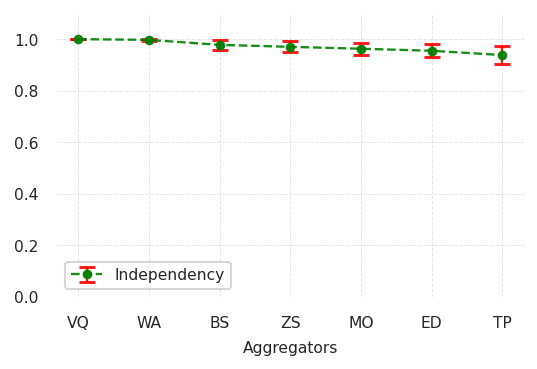


════════════════════════════════════════════════════════════════════════════════
✓ PLOT CREATED SUCCESSFULLY!
════════════════════════════════════════════════════════════════════════════════

Files saved as:
   /content/3. Relation_Metric_Dependency_Test3/average_correlation_with_errorbars_sorted_high_to_low.png
   /content/3. Relation_Metric_Dependency_Test3/average_correlation_with_errorbars_sorted_high_to_low.eps
   /content/3. Relation_Metric_Dependency_Test3/average_correlation_with_errorbars_sorted_high_to_low.pdf

════════════════════════════════════════════════════════════════════════════════
SUMMARY OF WHAT WAS PLOTTED:
════════════════════════════════════════════════════════════════════════════════
✓ Average Correlation line (green) - Mean of Kendall, Pearson, Spearman
✓ Error bars (red) - Standard deviation across the three correlation metrics
✓ Sorted from highest to lowest average correlation
✓ Removed robustness line (only correlation line shown)
✓ All data loaded direct

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

print("\n" + "═" * 100)
print("CREATING CORRELATION PLOT WITH AVERAGE CORRELATION AND ERROR BARS")
print("═" * 100)

METHOD_SHORT = {
    "Borda": "BS",
    "ZMean": "ZS",
    "Z-Mean": "ZS",
    "TOPSIS": "TP",
    "VIKOR": "VQ",
    "EDAS": "ED",
    "MOORA": "MO",
    "WASPAS": "WA"
}

METHOD_DISPLAY = {
    "Borda": "Borda",
    "ZMean": "Z-Mean",
    "Z-Mean": "Z-Mean",
    "TOPSIS": "TOPSIS",
    "VIKOR": "VIKOR",
    "EDAS": "EDAS",
    "MOORA": "MOORA",
    "WASPAS": "WASPAS"
}

output_dir = "/content/3. Relation_Metric_Dependency_Test3"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------------------------------------------------
# 1. LOAD OVERALL CORRELATION VALUES WITH INDIVIDUAL METRICS
# -------------------------------------------------------------------------
correlation_file = os.path.join(output_dir, "delta_corr_overall.csv")

if not os.path.exists(correlation_file):
    raise FileNotFoundError(f"Required file not found: {correlation_file}")

print(f"\n✓ Loading correlation data from: {correlation_file}")
corr_df = pd.read_csv(correlation_file)

# Remove any unnamed columns
corr_df = corr_df.loc[:, ~corr_df.columns.str.contains('^Unnamed')]

print(f"\nColumns found: {corr_df.columns.tolist()}")

# Verify required columns exist
required_columns = ['Method', 'Mean_Kendall_τ', 'Mean_Pearson_r', 'Mean_Spearman_ρ']
missing_columns = [col for col in required_columns if col not in corr_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Create list to store data for plotting
plot_data = []

for _, row in corr_df.iterrows():
    method = row['Method']

    # Get method names for display
    if method in METHOD_DISPLAY:
        method_display = METHOD_DISPLAY[method]
        method_short = METHOD_SHORT[method]
    else:
        method_display = method
        method_short = method[:2]

    # Extract individual correlations
    kendall_tau = row['Mean_Kendall_τ']
    pearson_r = row['Mean_Pearson_r']
    spearman_rho = row['Mean_Spearman_ρ']

    # Calculate average correlation (across Kendall, Pearson, Spearman)
    corr_values = [kendall_tau, pearson_r, spearman_rho]
    avg_correlation = np.mean(corr_values)
    std_correlation = np.std(corr_values)

    plot_data.append({
        'Method': method_display,
        'Short': method_short,
        'Kendall_τ': kendall_tau,
        'Pearson_r': pearson_r,
        'Spearman_ρ': spearman_rho,
        'Avg_Correlation': avg_correlation,
        'STD': std_correlation
    })

plot_df = pd.DataFrame(plot_data)
print(f"\n   Loaded correlation values for {len(plot_df)} methods")

# -------------------------------------------------------------------------
# 2. NORMALIZE THE AVERAGE CORRELATION VALUES (divide by max)
# -------------------------------------------------------------------------
max_avg_corr = plot_df['Avg_Correlation'].max()
plot_df['Norm_Avg_Correlation'] = plot_df['Avg_Correlation'] / max_avg_corr

# Normalize STD proportionally
plot_df['Norm_STD'] = plot_df['STD'] / max_avg_corr

# -------------------------------------------------------------------------
# 3. SORT by Average Correlation from HIGHER to LOWER (descending)
# -------------------------------------------------------------------------
plot_df = plot_df.sort_values('Avg_Correlation', ascending=False).reset_index(drop=True)

print("\n" + "═" * 80)
print("VALUES USED FOR PLOTTING (Sorted by Average Correlation - Higher to Lower)")
print("═" * 80)
print(plot_df[['Method', 'Short', 'Avg_Correlation', 'Norm_Avg_Correlation', 'STD', 'Norm_STD']].round(4).to_string(index=False))

print("\n" + "═" * 80)
print("ERROR BAR VALUES (Standard Deviation across Kendall, Pearson, Spearman)")
print("═" * 80)
for i, row in plot_df.iterrows():
    print(f"{row['Short']} ({row['Method']}):")
    print(f"   Average Correlation = {row['Norm_Avg_Correlation']:.4f}")
    print(f"   Error Bar (STD)     = {row['Norm_STD']:.4f}")
    print(f"   Raw STD             = {row['STD']:.4f}")

# -------------------------------------------------------------------------
# 4. PLOT - Average Correlation Line with Error Bars (No robustness line)
# -------------------------------------------------------------------------
plt.figure(figsize=(4.0, 2.8))

# Plot AVERAGE CORRELATION line with ERROR BARS
plt.errorbar(
    x=plot_df['Short'],
    y=plot_df['Norm_Avg_Correlation'],
    yerr=plot_df['Norm_STD'],
    marker='o',
    linewidth=1.2,
    markersize=4,
    linestyle='--',
    color='green',
    label='Independency',
    capsize=4,
    capthick=1.5,
    elinewidth=1.2,
    ecolor='red',
    alpha=0.9,
    fmt='o-'
)

plt.xlabel("Aggregators", fontsize=8, labelpad=5)

plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)
plt.ylim(0, 1.1)

# Keep one digit after decimal on y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Remove black border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend at bottom left
plt.legend(loc='lower left', frameon=True, fontsize=8)

plt.tight_layout()

# Save the plot
save_base = os.path.join(output_dir, "average_correlation_with_errorbars_sorted_high_to_low")

plt.savefig(f"{save_base}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_base}.eps", format="eps", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_base}.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()

print("\n" + "═" * 80)
print("✓ PLOT CREATED SUCCESSFULLY!")
print("═" * 80)
print(f"\nFiles saved as:")
print(f"   {save_base}.png")
print(f"   {save_base}.eps")
print(f"   {save_base}.pdf")

print("\n" + "═" * 80)
print("SUMMARY OF WHAT WAS PLOTTED:")
print("═" * 80)
print("✓ Average Correlation line (green) - Mean of Kendall, Pearson, Spearman")
print("✓ Error bars (red) - Standard deviation across the three correlation metrics")
print("✓ Sorted from highest to lowest average correlation")
print("✓ Removed robustness line (only correlation line shown)")
print("✓ All data loaded directly from delta_corr_overall.csv")
print("✓ No hardcoded values used")

#### 1.5 Robustness Test (5,10 and 20% Noise Injection)

In [ ]:
# ==========================================================
# ================ ROBUSTNESS ANALYSIS =====================
# ========== RELATION PREDICTION SECTION ===================
# ========== WITH 1000 RUNS & AVERAGING ====================
# ==========================================================

import pandas as pd
import numpy as np
from scipy.stats import kendalltau, spearmanr, pearsonr
import os
from tqdm import tqdm

# ─── Configuration ───────────────────────────────────────────────────────────────
INPUT_FILE = "/content/Relation_pred_main_file.csv"
OUTDIR = "/content/4. Robustness_Noise_Injection_Test4/"
os.makedirs(OUTDIR, exist_ok=True)

MCDM_METHODS = [
    "Borda",
    "ZMean",
    "TOPSIS",
    "VIKOR",
    "EDAS",
    "MOORA",
    "WASPAS"
]

NOISE_LEVELS = [0.05, 0.10, 0.20, 0.30]
NOISE_LABELS = ["5percent", "10percent", "20percent", "30percent"]

NUM_ITERATIONS = 1000


# ─── Noise Injection Function ──────────────────────────────────────────────────
def add_percentage_noise_all_metrics(dataframe, noise_percentage):
    """
    Add percentage-based noise to all metrics simultaneously.

    For each metric value x:
        noisy_x = x * U(1 - noise_percentage, 1 + noise_percentage)

    Constraints:
        MR metrics are kept non-negative.
        MRR and Hits metrics are clipped to [0, 1].
    """
    df_noisy = dataframe.copy()

    for col in df_noisy.columns:
        original_values = df_noisy[col].values

        noise_factor = 1 + np.random.uniform(
            -noise_percentage,
            noise_percentage,
            size=len(original_values)
        )

        noisy_values = original_values * noise_factor

        if col.startswith("MR_"):
            noisy_values = np.maximum(noisy_values, 0)

        elif "MRR" in col.upper() or "H@" in col.upper():
            noisy_values = np.clip(noisy_values, 0, 1)

        df_noisy[col] = noisy_values

    return df_noisy


# ─── MCDM Runner for Robustness Test ────────────────────────────────────────────
def run_mcdm_robustness(df_filtered):
    """
    Run all MCDM methods on the given dataframe.

    Assumes the following functions are already defined in earlier cells:
        - borda_count_local
        - zscore_average_local
        - topsis_local
        - vikor_local
        - edas_local
        - moora_local
        - waspas_local

    All final MCDM scores are transformed so that higher = better.
    """
    results = pd.DataFrame(index=df_filtered.index)

    # ─── Borda Count ───────────────────────────────────────────────────────────
    results["Borda"] = borda_count_local(df_filtered)

    borda_max = results["Borda"].max()

    if pd.isna(borda_max) or borda_max == 0:
        results["Borda"] = 0.0
    else:
        results["Borda"] = (results["Borda"] / borda_max).round(4)

    # ─── Z-Mean / Z-Score Average ─────────────────────────────────────────────
    results["ZMean"] = zscore_average_local(df_filtered)

    epsilon = 0.001
    z_min = results["ZMean"].min()
    z_max = results["ZMean"].max()

    if z_max == z_min:
        results["ZMean"] = 1.0
    else:
        t = (results["ZMean"] - z_min) / (z_max - z_min)
        results["ZMean"] = epsilon + (1 - epsilon) * t

    results["ZMean"] = results["ZMean"].round(4)

    # ─── TOPSIS ───────────────────────────────────────────────────────────────
    results["TOPSIS"] = topsis_local(df_filtered).round(4)

    # ─── VIKOR ────────────────────────────────────────────────────────────────
    # Original VIKOR is usually lower = better.
    # Convert it to higher = better using min/value.
    raw_vikor = vikor_local(df_filtered)

    vikor_min = raw_vikor.min()

    if pd.isna(vikor_min):
        results["VIKOR"] = np.nan
    else:
        if vikor_min == 0:
            vikor_min = 1e-6

        safe_raw_vikor = raw_vikor.replace(0, 1e-6)
        results["VIKOR"] = (vikor_min / safe_raw_vikor).round(4)

    # ─── EDAS, MOORA, WASPAS ─────────────────────────────────────────────────
    results["EDAS"] = edas_local(df_filtered).round(4)
    results["MOORA"] = moora_local(df_filtered).round(4)
    results["WASPAS"] = waspas_local(df_filtered).round(4)

    # ─── Ranks ────────────────────────────────────────────────────────────────
    # All scores are higher = better after transformation.
    for col in MCDM_METHODS:
        results[f"{col}_R"] = results[col].rank(
            ascending=False,
            method="min"
        ).astype(int)

    return results


# ─── Main Analysis ─────────────────────────────────────────────────────────────
print("\n" + "═" * 100)
print(f"RELATION PREDICTION ROBUSTNESS ANALYSIS - MULTIPLE NOISE LEVELS WITH {NUM_ITERATIONS} ITERATIONS")
print("═" * 100)


# ─── Load Normalized Data ──────────────────────────────────────────────────────
print("\nLoading normalized relation prediction data...")

# Preferred: use df_normalized if it already exists from a previous normalization cell.
# Fallback: load INPUT_FILE directly if df_normalized does not exist.
try:
    df_normalized_robust = df_normalized.copy()
    print("Using existing df_normalized from previous notebook cell.")

except NameError:
    print("df_normalized not found. Loading data from INPUT_FILE.")

    df_raw = pd.read_csv(INPUT_FILE)

    first_column = df_raw.columns[0]
    df_raw = df_raw.set_index(first_column)

    if first_column != "Model":
        df_raw.index.name = "Model"

    df_normalized_robust = df_raw.copy()

print(f"Dataset shape: {df_normalized_robust.shape}")
print(f"Models: {df_normalized_robust.shape[0]} | Metrics: {df_normalized_robust.shape[1]}")


# ═════════════════════════════════════════════════════════════════════════════════
# STEP 1: Calculate Baseline Results
# ═════════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 90)
print("BASELINE (NO NOISE)")
print("═" * 90)

baseline_results = run_mcdm_robustness(df_normalized_robust)

baseline_scores = baseline_results[MCDM_METHODS].round(4)
baseline_ranks = baseline_results[[f"{m}_R" for m in MCDM_METHODS]]

baseline_scores.to_csv(f"{OUTDIR}baseline_scores.csv")
baseline_ranks.to_csv(f"{OUTDIR}baseline_ranks.csv")

print("Baseline files saved:")
print("  - baseline_scores.csv")
print("  - baseline_ranks.csv")


# ═════════════════════════════════════════════════════════════════════════════════
# STEP 2: Loop Over Noise Levels
# ═════════════════════════════════════════════════════════════════════════════════
for noise_pct, label in zip(NOISE_LEVELS, NOISE_LABELS):

    print("\n" + "═" * 100)
    print(f"→ NOISE LEVEL: {int(noise_pct * 100)}% - Running {NUM_ITERATIONS} iterations")
    print("═" * 100)

    accumulated_metrics = {
        "kendall_tau": {m: [] for m in MCDM_METHODS},
        "pearson_r": {m: [] for m in MCDM_METHODS},
        "spearman_rho": {m: [] for m in MCDM_METHODS},
        "overall_correlation": {m: [] for m in MCDM_METHODS},

        "mean_delta_rank": {m: [] for m in MCDM_METHODS},
        "max_delta_rank": {m: [] for m in MCDM_METHODS},
        "std_delta_rank": {m: [] for m in MCDM_METHODS},
    }

    accumulated_ranks = {
        m: np.zeros(len(df_normalized_robust))
        for m in MCDM_METHODS
    }

    # ─── Run Iterations ───────────────────────────────────────────────────────
    for iteration in tqdm(
        range(NUM_ITERATIONS),
        desc=f"Processing {int(noise_pct * 100)}% noise"
    ):
        np.random.seed(42 + iteration)

        df_noisy = add_percentage_noise_all_metrics(
            df_normalized_robust,
            noise_percentage=noise_pct
        )

        noisy_results = run_mcdm_robustness(df_noisy)

        for method in MCDM_METHODS:
            baseline_rank = baseline_results[f"{method}_R"]
            noisy_rank = noisy_results[f"{method}_R"]

            baseline_score = baseline_results[method]
            noisy_score = noisy_results[method]

            accumulated_ranks[method] += noisy_rank.values

            delta = (baseline_rank - noisy_rank).abs()

            # Rank-level correlations
            kt, _ = kendalltau(baseline_rank, noisy_rank)
            sr, _ = spearmanr(baseline_rank, noisy_rank)

            # Score-level Pearson correlation
            try:
                pr, _ = pearsonr(baseline_score, noisy_score)
            except Exception:
                pr = np.nan

            overall_corr = np.nanmean([kt, pr, sr])

            accumulated_metrics["kendall_tau"][method].append(kt)
            accumulated_metrics["pearson_r"][method].append(pr)
            accumulated_metrics["spearman_rho"][method].append(sr)
            accumulated_metrics["overall_correlation"][method].append(overall_corr)

            accumulated_metrics["mean_delta_rank"][method].append(delta.mean())
            accumulated_metrics["max_delta_rank"][method].append(delta.max())
            accumulated_metrics["std_delta_rank"][method].append(delta.std())

    # ═════════════════════════════════════════════════════════════════════════════
    # STEP 3: Average Metrics Across All Iterations
    # ═════════════════════════════════════════════════════════════════════════════
    print(f"\n✓ Completed {NUM_ITERATIONS} iterations. Computing averages...")

    comparison_results = {}

    for method in MCDM_METHODS:
        comparison_results[method] = {
            "kendall_tau": np.nanmean(accumulated_metrics["kendall_tau"][method]),
            "kendall_tau_std": np.nanstd(accumulated_metrics["kendall_tau"][method]),

            "pearson_r": np.nanmean(accumulated_metrics["pearson_r"][method]),
            "pearson_r_std": np.nanstd(accumulated_metrics["pearson_r"][method]),

            "spearman_rho": np.nanmean(accumulated_metrics["spearman_rho"][method]),
            "spearman_rho_std": np.nanstd(accumulated_metrics["spearman_rho"][method]),

            "overall_correlation": np.nanmean(accumulated_metrics["overall_correlation"][method]),
            "overall_correlation_std": np.nanstd(accumulated_metrics["overall_correlation"][method]),

            "mean_delta_rank": np.nanmean(accumulated_metrics["mean_delta_rank"][method]),
            "mean_delta_rank_std": np.nanstd(accumulated_metrics["mean_delta_rank"][method]),

            "max_delta_rank": np.nanmean(accumulated_metrics["max_delta_rank"][method]),
            "std_delta_rank": np.nanmean(accumulated_metrics["std_delta_rank"][method]),
        }

    # ═════════════════════════════════════════════════════════════════════════════
    # STEP 4: Average Noisy Ranks
    # ═════════════════════════════════════════════════════════════════════════════
    averaged_noisy_ranks = pd.DataFrame(index=df_normalized_robust.index)

    for method in MCDM_METHODS:
        averaged_noisy_ranks[f"{method}_R"] = (
            accumulated_ranks[method] / NUM_ITERATIONS
        )

    averaged_noisy_ranks = averaged_noisy_ranks.round(0).astype(int)

    averaged_noisy_ranks.to_csv(
        f"{OUTDIR}averaged_noisy_ranks_{label}.csv"
    )

    # ═════════════════════════════════════════════════════════════════════════════
    # STEP 5: Save Averaged Comparison Metrics
    # ═════════════════════════════════════════════════════════════════════════════
    comp_df = pd.DataFrame(comparison_results).T

    # Convert mean ΔRank to higher-is-better stability score.
    # Lower mean_delta_rank is better, so best method gets 1.0.
    min_delta = comp_df["mean_delta_rank"].replace(0, np.nan).min()

    comp_df["delta_rank_stability"] = (
        min_delta / comp_df["mean_delta_rank"].replace(0, np.nan)
    )

    comp_df["delta_rank_stability"] = (
        comp_df["delta_rank_stability"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(1.0)
    )

    # Approximate propagated error for delta-rank stability.
    comp_df["delta_rank_stability_std"] = (
        comp_df["delta_rank_stability"] *
        (
            comp_df["mean_delta_rank_std"] /
            comp_df["mean_delta_rank"].replace(0, np.nan)
        )
    )

    comp_df["delta_rank_stability_std"] = (
        comp_df["delta_rank_stability_std"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    comp_df = comp_df.round(4)
    comp_df.index.name = "Method"

    comp_df.to_csv(f"{OUTDIR}comparison_{label}.csv")

    # ─── Print Summary for This Noise Level ───────────────────────────────────
    print(f"\n✓ Results for {int(noise_pct * 100)}% noise averaged over {NUM_ITERATIONS} runs:")

    print(
        f"  Avg ΔRank                 : "
        f"{comp_df['mean_delta_rank'].mean():.2f} ± "
        f"{comp_df['mean_delta_rank_std'].mean():.2f}"
    )

    print(
        f"  Avg Kendall τ             : "
        f"{comp_df['kendall_tau'].mean():.4f} ± "
        f"{comp_df['kendall_tau_std'].mean():.4f}"
    )

    print(
        f"  Avg Pearson r             : "
        f"{comp_df['pearson_r'].mean():.4f} ± "
        f"{comp_df['pearson_r_std'].mean():.4f}"
    )

    print(
        f"  Avg Spearman ρ            : "
        f"{comp_df['spearman_rho'].mean():.4f} ± "
        f"{comp_df['spearman_rho_std'].mean():.4f}"
    )

    print(
        f"  Avg Overall Correlation   : "
        f"{comp_df['overall_correlation'].mean():.4f} ± "
        f"{comp_df['overall_correlation_std'].mean():.4f}"
    )

    print(
        f"  Avg Raw ΔRank             : "
        f"{comp_df['mean_delta_rank'].mean():.2f} ± "
        f"{comp_df['mean_delta_rank_std'].mean():.2f}"
    )

    print(
        f"  Avg ΔRank Stability       : "
        f"{comp_df['delta_rank_stability'].mean():.4f} ± "
        f"{comp_df['delta_rank_stability_std'].mean():.4f}"
    )

    print("  Files saved:")
    print(f"    - comparison_{label}.csv")
    print(f"    - averaged_noisy_ranks_{label}.csv")


# ═════════════════════════════════════════════════════════════════════════════════
# STEP 6: Create Summary Table Combining All Noise Levels
# ═════════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 100)
print("Creating summary table for all noise levels...")
print("═" * 100)

summary_rows = []

for noise_pct, label in zip(NOISE_LEVELS, NOISE_LABELS):

    comp_file = f"{OUTDIR}comparison_{label}.csv"

    if not os.path.exists(comp_file):
        continue

    df_comp = pd.read_csv(comp_file, index_col=0)

    row = {
        "Noise_Level": f"{int(noise_pct * 100)}%"
    }

    for method in MCDM_METHODS:
        row[f"{method}_Kendall"] = df_comp.loc[method, "kendall_tau"]
        row[f"{method}_Pearson"] = df_comp.loc[method, "pearson_r"]
        row[f"{method}_Spearman"] = df_comp.loc[method, "spearman_rho"]
        row[f"{method}_OverallCorr"] = df_comp.loc[method, "overall_correlation"]

        row[f"{method}_MeanDelta"] = df_comp.loc[method, "mean_delta_rank"]
        row[f"{method}_MeanDelta_Std"] = df_comp.loc[method, "mean_delta_rank_std"]

        row[f"{method}_DeltaStability"] = df_comp.loc[method, "delta_rank_stability"]
        row[f"{method}_DeltaStability_Std"] = df_comp.loc[method, "delta_rank_stability_std"]

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    f"{OUTDIR}noise_injection_summary.csv",
    index=False
)

# ─── SAVE robustness.csv (for the final NFL aggregation cell) ─────────────────
# robustness = mean Overall Correlation across all noise levels, per method.
_rob_rows = []
for noise_pct, label in zip(NOISE_LEVELS, NOISE_LABELS):
    _cf = f"{OUTDIR}comparison_{label}.csv"
    if not os.path.exists(_cf):
        continue
    _cdf = pd.read_csv(_cf, index_col=0)
    for method in MCDM_METHODS:
        if method in _cdf.index:
            _rob_rows.append({
                "Method": method,
                "overall_correlation": float(_cdf.loc[method, "overall_correlation"]),
            })

_rob_df = pd.DataFrame(_rob_rows)
robustness_export = (
    _rob_df.groupby("Method")["overall_correlation"].mean().reset_index()
)
robustness_export = robustness_export.rename(
    columns={"overall_correlation": "robustness"}
)
robustness_export["robustness"] = robustness_export["robustness"].round(4)
robustness_export.to_csv(f"{OUTDIR}robustness.csv", index=False)
print(f"\n✓ Also saved: {OUTDIR}robustness.csv")


# ═════════════════════════════════════════════════════════════════════════════════
# STEP 7: Final Output
# ═════════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 100)
print("✓ RELATION PREDICTION NOISE-INJECTION ANALYSIS FINISHED")
print("═" * 100)

print(f"All results averaged over {NUM_ITERATIONS} independent noise injection runs")
print(f"\nFiles saved in: {OUTDIR}")

print("\nGenerated files:")
print("  1. baseline_scores.csv")
print("  2. baseline_ranks.csv")

for label in NOISE_LABELS:
    print(f"  - comparison_{label}.csv")
    print(f"  - averaged_noisy_ranks_{label}.csv")

print("  - noise_injection_summary.csv")
print("═" * 100)


════════════════════════════════════════════════════════════════════════════════════════════════════
RELATION PREDICTION ROBUSTNESS ANALYSIS - MULTIPLE NOISE LEVELS WITH 1000 ITERATIONS
════════════════════════════════════════════════════════════════════════════════════════════════════

Loading normalized relation prediction data...
Using existing df_normalized from previous notebook cell.
Dataset shape: (12, 18)
Models: 12 | Metrics: 18

══════════════════════════════════════════════════════════════════════════════════════════
BASELINE (NO NOISE)
══════════════════════════════════════════════════════════════════════════════════════════
Baseline files saved:
  - baseline_scores.csv
  - baseline_ranks.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
→ NOISE LEVEL: 5% - Running 1000 iterations
════════════════════════════════════════════════════════════════════════════════════════════════════


Processing 5% noise: 100%|██████████| 1000/1000 [00:42<00:00, 23.77it/s]



✓ Completed 1000 iterations. Computing averages...

✓ Results for 5% noise averaged over 1000 runs:
  Avg ΔRank                 : 0.66 ± 0.51
  Avg Kendall τ             : 0.8789 ± 0.0919
  Avg Pearson r             : 0.9338 ± 0.0718
  Avg Spearman ρ            : 0.9314 ± 0.0685
  Avg Overall Correlation   : 0.9147 ± 0.0747
  Avg Raw ΔRank             : 0.66 ± 0.51
  Avg ΔRank Stability       : 0.5730 ± 0.3547
  Files saved:
    - comparison_5percent.csv
    - averaged_noisy_ranks_5percent.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
→ NOISE LEVEL: 10% - Running 1000 iterations
════════════════════════════════════════════════════════════════════════════════════════════════════


Processing 10% noise: 100%|██████████| 1000/1000 [00:41<00:00, 24.04it/s]



✓ Completed 1000 iterations. Computing averages...

✓ Results for 10% noise averaged over 1000 runs:
  Avg ΔRank                 : 0.94 ± 0.58
  Avg Kendall τ             : 0.8021 ± 0.1170
  Avg Pearson r             : 0.8873 ± 0.0897
  Avg Spearman ρ            : 0.8818 ± 0.0940
  Avg Overall Correlation   : 0.8571 ± 0.0964
  Avg Raw ΔRank             : 0.94 ± 0.58
  Avg ΔRank Stability       : 0.6596 ± 0.3033
  Files saved:
    - comparison_10percent.csv
    - averaged_noisy_ranks_10percent.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
→ NOISE LEVEL: 20% - Running 1000 iterations
════════════════════════════════════════════════════════════════════════════════════════════════════


Processing 20% noise: 100%|██████████| 1000/1000 [00:40<00:00, 24.91it/s]



✓ Completed 1000 iterations. Computing averages...

✓ Results for 20% noise averaged over 1000 runs:
  Avg ΔRank                 : 1.43 ± 0.68
  Avg Kendall τ             : 0.6783 ± 0.1458
  Avg Pearson r             : 0.8080 ± 0.1165
  Avg Spearman ρ            : 0.7920 ± 0.1292
  Avg Overall Correlation   : 0.7594 ± 0.1246
  Avg Raw ΔRank             : 1.43 ± 0.68
  Avg ΔRank Stability       : 0.7578 ± 0.2919
  Files saved:
    - comparison_20percent.csv
    - averaged_noisy_ranks_20percent.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
→ NOISE LEVEL: 30% - Running 1000 iterations
════════════════════════════════════════════════════════════════════════════════════════════════════


Processing 30% noise: 100%|██████████| 1000/1000 [00:41<00:00, 24.30it/s]



✓ Completed 1000 iterations. Computing averages...

✓ Results for 30% noise averaged over 1000 runs:
  Avg ΔRank                 : 1.86 ± 0.77
  Avg Kendall τ             : 0.5693 ± 0.1660
  Avg Pearson r             : 0.7184 ± 0.1491
  Avg Spearman ρ            : 0.6965 ± 0.1632
  Avg Overall Correlation   : 0.6614 ± 0.1522
  Avg Raw ΔRank             : 1.86 ± 0.77
  Avg ΔRank Stability       : 0.8254 ± 0.2924
  Files saved:
    - comparison_30percent.csv
    - averaged_noisy_ranks_30percent.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
Creating summary table for all noise levels...
════════════════════════════════════════════════════════════════════════════════════════════════════

✓ Also saved: /content/4. Robustness_Noise_Injection_Test4/robustness.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
✓ RELATION PREDICTION NOISE-INJECTION ANALYSIS FINISHED
══════════════

##### 1.5.1 Detail Visualization Robustness


Loading averaged comparison data from 1000 iterations per noise level...
Loaded 5% noise data – methods: 7
Loaded 10% noise data – methods: 7
Loaded 20% noise data – methods: 7
Loaded 30% noise data – methods: 7

────────────────────────────────────────────────────────────────────────────────
Global minimum mean |ΔRank| used for normalization: 0.231900
Formula: normalized_delta_rank_stability = global_min_delta / mean_delta_rank
Higher value = more robust
────────────────────────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────────────────────────
METHODS SORTED (Less robust → More robust):
VIKOR →  WASPAS →  Borda →  Z-score →  EDAS →  MOORA →  TOPSIS
────────────────────────────────────────────────────────────────────────────────

Generating Combined Robustness Plot...


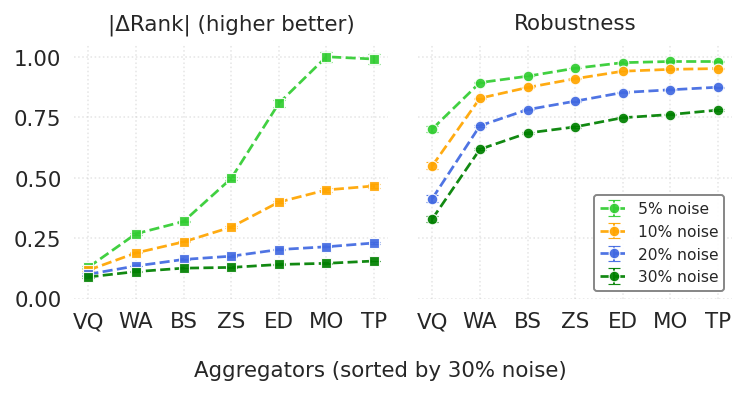


✓ Heatmap plot removed as requested

ROBUSTNESS ANALYSIS SUMMARY – RELATION PREDICTION (1000 runs)
Noise Avg Overall Correlation   Avg Kendall τ   Avg Pearson r  Avg Spearman ρ Avg Raw |ΔRank| Avg Global Normalized |ΔRank| Best by Overall Corr Worst by Overall Corr Best by ΔRank Stability Worst by ΔRank Stability
   5%         0.9147 ± 0.0747 0.8789 ± 0.0919 0.9338 ± 0.0718 0.9314 ± 0.0685     0.66 ± 0.51               0.5730 ± 0.3547                MOORA                 VIKOR                   MOORA                    VIKOR
  10%         0.8571 ± 0.0964 0.8021 ± 0.1170 0.8873 ± 0.0897 0.8818 ± 0.0940     0.94 ± 0.58               0.3071 ± 0.1412               TOPSIS                 VIKOR                  TOPSIS                    VIKOR
  20%         0.7594 ± 0.1246 0.6783 ± 0.1458 0.8080 ± 0.1165 0.7920 ± 0.1292     1.43 ± 0.68               0.1742 ± 0.0671               TOPSIS                 VIKOR                  TOPSIS                    VIKOR
  30%         0.6614 ± 0.1522 0.5693

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

# ── SETTINGS ────────────────────────────────────────────────────────
OUTDIR = "/content/4. Robustness_Noise_Injection_Test4/"
os.makedirs(OUTDIR, exist_ok=True)

noise_levels = {
    5:  "5percent",
    10: "10percent",
    20: "20percent",
    30: "30percent"
}

colors = {
    5:  "limegreen",
    10: "orange",
    20: "royalblue",
    30: "green"
}

NUM_ITERATIONS = 1000

METHOD_SHORT = {
    "EDAS":         "ED",
    "TOPSIS":       "TP",
    "VIKOR Q":      "VQ",
    "VIKOR":        "VQ",
    "Borda Count":  "BS",
    "Borda":        "BS",
    "Z-score":      "ZS",
    "ZMean":        "ZS",
    "Zmean":        "ZS",
    "Z-Mean":       "ZS",
    "MOORA":        "MO",
    "WASPAS":       "WA",
}

# ── COMPACT STYLE ───────────────────────────────────────────────────
def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "DejaVu Serif",
            "Times New Roman",
            "Liberation Serif",
            "serif"
        ],
        "mathtext.fontset": "stix",
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",
    })

    sns.set_theme(style="white", font_scale=1.0)


setup_plot_style()


# ── LOAD DATA ───────────────────────────────────────────────────────
data = {}
reference_df = None

print("\nLoading averaged comparison data from 1000 iterations per noise level...")

for pct, label in noise_levels.items():
    path = os.path.join(OUTDIR, f"comparison_{label}.csv")

    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue

    df = pd.read_csv(path, index_col=0)
    df.index = df.index.str.strip()

    # Standardize method names
    df.index = df.index.str.replace("ZMean", "Z-score", regex=False)
    df.index = df.index.str.replace("Zmean", "Z-score", regex=False)
    df.index = df.index.str.replace("Z-Mean", "Z-score", regex=False)

    # Compute overall correlation if not already saved
    if "overall_correlation" not in df.columns:
        required_corr_cols = {
            "kendall_tau",
            "pearson_r",
            "spearman_rho"
        }

        if required_corr_cols.issubset(df.columns):
            df["overall_correlation"] = df[
                ["kendall_tau", "pearson_r", "spearman_rho"]
            ].mean(axis=1)
        else:
            raise ValueError(
                f"{path} does not contain 'overall_correlation' and also does not contain "
                "'kendall_tau', 'pearson_r', and 'spearman_rho'. "
            )

    # Compute overall correlation std if not already saved
    if "overall_correlation_std" not in df.columns:
        required_std_cols = {
            "kendall_tau_std",
            "pearson_r_std",
            "spearman_rho_std"
        }

        if required_std_cols.issubset(df.columns):
            df["overall_correlation_std"] = df[
                ["kendall_tau_std", "pearson_r_std", "spearman_rho_std"]
            ].mean(axis=1)
        else:
            df["overall_correlation_std"] = 0.0

    data[pct] = df

    print(f"Loaded {pct}% noise data – methods: {len(df)}")

    if pct == 30:
        reference_df = df

if reference_df is None:
    raise FileNotFoundError(
        "comparison_30percent.csv not found → cannot sort methods."
    )


# ── GLOBAL NORMALIZATION OF ΔRANK ───────────────────────────────────
all_delta_values = []

for pct, df in data.items():
    if "mean_delta_rank" not in df.columns:
        raise ValueError(
            f"comparison_{noise_levels[pct]}.csv is missing 'mean_delta_rank'."
        )

    valid_values = df["mean_delta_rank"].replace(0, np.nan).dropna()
    all_delta_values.extend(valid_values.tolist())

if len(all_delta_values) == 0:
    raise ValueError(
        "No valid mean_delta_rank values found for global normalization."
    )

global_min_delta = np.min(all_delta_values)

print("\n" + "─" * 80)
print(f"Global minimum mean |ΔRank| used for normalization: {global_min_delta:.6f}")
print("Formula: normalized_delta_rank_stability = global_min_delta / mean_delta_rank")
print("Higher value = more robust")
print("─" * 80 + "\n")

for pct, df in data.items():
    df["delta_rank_stability_global"] = (
        global_min_delta / df["mean_delta_rank"].replace(0, np.nan)
    )

    df["delta_rank_stability_global"] = df[
        "delta_rank_stability_global"
    ].replace(
        [np.inf, -np.inf],
        np.nan
    ).fillna(1.0)

    if "mean_delta_rank_std" in df.columns:
        df["delta_rank_stability_global_std"] = (
            df["delta_rank_stability_global"] *
            (
                df["mean_delta_rank_std"] /
                df["mean_delta_rank"].replace(0, np.nan)
            )
        ).replace(
            [np.inf, -np.inf],
            np.nan
        ).fillna(0)
    else:
        df["delta_rank_stability_global_std"] = 0.0

    data[pct] = df

    label = noise_levels[pct]
    df.to_csv(
        os.path.join(
            OUTDIR,
            f"comparison_{label}_with_global_norm.csv"
        )
    )


# ── DETERMINE SORT ORDER BASED ON 30% NOISE ─────────────────────────
sort_column = "delta_rank_stability_global"
sort_ascending = True

sorted_methods = reference_df[sort_column].sort_values(
    ascending=sort_ascending
).index.tolist()

print("\n" + "─" * 80)
print(f"METHODS SORTED (Less robust → More robust):")
print(" →  ".join(sorted_methods))
print("─" * 80 + "\n")

x = np.arange(len(sorted_methods))
short_labels = [
    METHOD_SHORT.get(method, method[:8])
    for method in sorted_methods
]


# ── COMBINED PLOT: GLOBAL NORMALIZED ΔRANK + OVERALL CORRELATION ────
print("Generating Combined Robustness Plot...")

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=(5.4, 2.8),
    sharex=True
)

for ax in (ax_left, ax_right):
    ax.grid(
        True,
        which="major",
        linestyle=":",
        alpha=0.5,
        linewidth=0.8
    )

    ax.grid(
        True,
        which="minor",
        linestyle=":",
        alpha=0.3,
        linewidth=0.5
    )

    ax.set_axisbelow(True)

    ax.set_xticks(x)
    ax.set_xticklabels(
        short_labels,
        rotation=0,
        ha="center"
    )

    ax.tick_params(
        width=0.8,
        length=3
    )

    for spine in ax.spines.values():
        spine.set_visible(False)


# ── LEFT: Globally Normalized ΔRank Stability ───────────────────────
ax_left.set_ylim(0, 1.05)

for pct, col in colors.items():
    if pct not in data:
        continue

    df = data[pct].reindex(sorted_methods)

    y = df["delta_rank_stability_global"]
    yerr = df["delta_rank_stability_global_std"] / np.sqrt(NUM_ITERATIONS)

    ax_left.errorbar(
        x,
        y,
        yerr=yerr,
        marker="s",
        markersize=5.5,
        linewidth=1.4,
        linestyle="--",
        color=col,
        label=f"{pct}% noise",
        capsize=3,
        capthick=1.0,
        elinewidth=1.0,
        alpha=0.93,
        markeredgecolor="white",
        markeredgewidth=0.6
    )

# CHANGE 2: Title for left plot (moved from inside to top)
ax_left.set_title("|ΔRank| (higher better)", fontsize=11, pad=8)


# ── RIGHT: Overall Correlation ──────────────────────────────────────
ax_right.set_ylim(0, 1.05)

# CHANGE 3: Remove numeric values on y-axis from the right side plot
ax_right.set_yticklabels([])  # This removes the y-axis tick labels
ax_right.tick_params(left=False, labelleft=False)  # Completely hide left ticks and labels

for pct, col in colors.items():
    if pct not in data:
        continue

    df = data[pct].reindex(sorted_methods)

    y = df["overall_correlation"]
    yerr = df["overall_correlation_std"] / np.sqrt(NUM_ITERATIONS)

    ax_right.errorbar(
        x,
        y,
        yerr=yerr,
        marker="o",
        markersize=5.5,
        linewidth=1.4,
        linestyle="--",
        color=col,
        label=f"{pct}% noise",
        capsize=3,
        capthick=1.0,
        elinewidth=1.0,
        alpha=0.93,
        markeredgecolor="white",
        markeredgewidth=0.6
    )

ax_right.legend(
    loc="lower right",
    fontsize=8,
    framealpha=0.95,
    edgecolor="gray",
    handlelength=1.8,
    handletextpad=0.6
)

# CHANGE 2: Title for right plot (moved from inside to top)
ax_right.set_title("Robustness", fontsize=11, pad=8)


fig.text(
    0.5,
    0.01,
    "Aggregators (sorted by 30% noise)",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save combined plot
plt.savefig(
    os.path.join(
        OUTDIR,
        "relation_combined_global_normalized_delta_rank_and_overall_correlation.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.savefig(
    os.path.join(
        OUTDIR,
        "relation_combined_global_normalized_delta_rank_and_overall_correlation.eps"
    ),
    format="eps",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.savefig(
    os.path.join(
        OUTDIR,
        "relation_combined_global_normalized_delta_rank_and_overall_correlation.pdf"
    ),
    format="pdf",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.show()


# ── HEATMAP SECTION COMPLETELY REMOVED ──────────────────────────────
print("\n✓ Heatmap plot removed as requested")


# ── SUMMARY TABLE ───────────────────────────────────────────────────
print("\n" + "=" * 100)
print("ROBUSTNESS ANALYSIS SUMMARY – RELATION PREDICTION (1000 runs)")
print("=" * 100)

summary_rows = []

for pct in sorted(noise_levels):
    if pct not in data:
        continue

    df = data[pct]

    row = {
        "Noise": f"{pct}%",

        "Avg Overall Correlation": (
            f"{df['overall_correlation'].mean():.4f} ± "
            f"{df['overall_correlation_std'].mean():.4f}"
        ),

        "Avg Kendall τ": (
            f"{df['kendall_tau'].mean():.4f} ± "
            f"{df['kendall_tau_std'].mean():.4f}"
            if "kendall_tau" in df.columns and "kendall_tau_std" in df.columns
            else "–"
        ),

        "Avg Pearson r": (
            f"{df['pearson_r'].mean():.4f} ± "
            f"{df['pearson_r_std'].mean():.4f}"
            if "pearson_r" in df.columns and "pearson_r_std" in df.columns
            else "–"
        ),

        "Avg Spearman ρ": (
            f"{df['spearman_rho'].mean():.4f} ± "
            f"{df['spearman_rho_std'].mean():.4f}"
            if "spearman_rho" in df.columns and "spearman_rho_std" in df.columns
            else "–"
        ),

        "Avg Raw |ΔRank|": (
            f"{df['mean_delta_rank'].mean():.2f} ± "
            f"{df['mean_delta_rank_std'].mean():.2f}"
            if "mean_delta_rank" in df.columns and "mean_delta_rank_std" in df.columns
            else "–"
        ),

        "Avg Global Normalized |ΔRank|": (
            f"{df['delta_rank_stability_global'].mean():.4f} ± "
            f"{df['delta_rank_stability_global_std'].mean():.4f}"
        ),

        "Best by Overall Corr": df["overall_correlation"].idxmax(),
        "Worst by Overall Corr": df["overall_correlation"].idxmin(),

        "Best by ΔRank Stability": df["delta_rank_stability_global"].idxmax(),
        "Worst by ΔRank Stability": df["delta_rank_stability_global"].idxmin(),
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print(summary_df.to_string(index=False))

summary_df.to_csv(
    os.path.join(
        OUTDIR,
        "robustness_summary_table_relation_1000runs_global_norm.csv"
    ),
    index=False
)


# ── FINAL RANKING AT 30% NOISE ──────────────────────────────────────
print("\n" + "─" * 100)
print("ROBUSTNESS RANKING – 30% NOISE")
print("─" * 100)

if 30 in data:
    df_30 = data[30].copy()

    ranking_df = pd.DataFrame(index=df_30.index)

    ranking_df["Overall Correlation"] = df_30[
        "overall_correlation"
    ].round(4)

    ranking_df["Correlation Rank"] = df_30[
        "overall_correlation"
    ].rank(
        ascending=False
    ).astype(int)

    ranking_df["Raw Mean |ΔRank|"] = df_30[
        "mean_delta_rank"
    ].round(3)

    ranking_df["Global Normalized |ΔRank|"] = df_30[
        "delta_rank_stability_global"
    ].round(4)

    ranking_df["ΔRank Stability Rank"] = df_30[
        "delta_rank_stability_global"
    ].rank(
        ascending=False
    ).astype(int)

    rank_cols = [
        "Correlation Rank",
        "ΔRank Stability Rank"
    ]

    ranking_df["Composite Rank"] = ranking_df[
        rank_cols
    ].mean(axis=1).round(1)

    ranking_df = ranking_df.sort_values(
        "Composite Rank"
    )

    print(ranking_df)

    ranking_df.to_csv(
        os.path.join(
            OUTDIR,
            "robustness_ranking_relation_1000runs_global_norm.csv"
        )
    )

    # ── NORMALIZE AND SAVE OVERALL CORRELATION AS robustness ─────────
    max_overall_corr = ranking_df["Overall Correlation"].max()

    if max_overall_corr == 0 or pd.isna(max_overall_corr):
        ranking_df["robustness"] = 0.0
    else:
        ranking_df["robustness"] = (
            ranking_df["Overall Correlation"] / max_overall_corr
        ).round(4)

    robustness_df = ranking_df[["robustness"]].copy()
    robustness_df.index.name = "Method"

    robustness_save_path = os.path.join(
        OUTDIR,
        "robustness.csv"
    )

    robustness_df.to_csv(
        robustness_save_path,
        float_format="%.4f"
    )

    print("\n" + "=" * 100)
    print("NORMALIZED OVERALL CORRELATION SAVED AS robustness")
    print("=" * 100)
    print("Formula: robustness = Overall Correlation / max(Overall Correlation)")
    print(robustness_df.to_string())
    print(f"\nSaved to: {robustness_save_path}")

print("\n" + "=" * 100)
print("Done. All relation prediction plots and tables saved to:")
print(OUTDIR)
print("=" * 100)


LOADING ROBUSTNESS DATA FROM 1000 ITERATIONS PER NOISE LEVEL
✓ Loaded 5% noise data – methods: 7
✓ Loaded 10% noise data – methods: 7
✓ Loaded 20% noise data – methods: 7
✓ Loaded 30% noise data – methods: 7

────────────────────────────────────────────────────────────────────────────────
COMPUTING AVERAGE CORRELATION ACROSS NOISE LEVELS (5%, 10%, 20%, 30%)
────────────────────────────────────────────────────────────────────────────────
 BS  : Avg=0.9069 ± 0.093659
 ZS  : Avg=0.9429 ± 0.086128
 TP  : Avg=0.9999 ± 0.066073
 VQ  : Avg=0.5474 ± 0.465250
 ED  : Avg=0.9794 ± 0.076095
 MO  : Avg=0.9902 ± 0.070773
 WA  : Avg=0.8479 ± 0.122796

METHODS SORTED BY AVERAGE CORRELATION (HIGHER TO LOWER):
  1. TP   : 0.9999
  2. MO   : 0.9902
  3. ED   : 0.9794
  4. ZS   : 0.9429
  5. BS   : 0.9069
  6. WA   : 0.8479
  7. VQ   : 0.5474


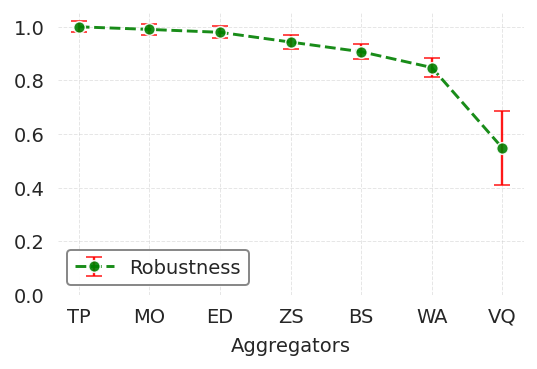


✓ AVERAGE CORRELATION PLOT CREATED SUCCESSFULLY (with REDUCED error bars)
Files saved in: /content/4. Robustness_Noise_Injection_Test4/


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

# ── SETTINGS ────────────────────────────────────────────────────────
OUTDIR = "/content/4. Robustness_Noise_Injection_Test4/"
os.makedirs(OUTDIR, exist_ok=True)

noise_levels = {
    5: "5percent",
    10: "10percent",
    20: "20percent",
    30: "30percent"
}
NUM_ITERATIONS = 1000

# Short names for methods
METHOD_SHORT = {
    'EDAS': 'ED',
    'TOPSIS': 'TP',
    'VIKOR Q': 'VQ',
    'VIKOR': 'VQ',
    'Borda Count': 'BS',
    'Borda': 'BS',
    'Z-score': 'ZS',
    'ZMean': 'ZS',
    'Zmean': 'ZS',
    'Z-Mean': 'ZS',
    'MOORA': 'MO',
    'WASPAS': 'WA',
}

METHOD_FULL = {
    'ED': 'EDAS',
    'TP': 'TOPSIS',
    'VQ': 'VIKOR',
    'BS': 'Borda',
    'ZS': 'Z-Score',
    'MO': 'MOORA',
    'WA': 'WASPAS'
}

# ── STYLE FUNCTION ───────────────────────────────────────────────────
def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

# ── LOAD DATA FROM ALL NOISE LEVELS ─────────────────────────────────
data = {}
print("\nLOADING ROBUSTNESS DATA FROM 1000 ITERATIONS PER NOISE LEVEL")

for pct, label in noise_levels.items():
    path = os.path.join(OUTDIR, f"comparison_{label}.csv")
    if not os.path.exists(path):
        print(f"✗ File not found: {path}")
        continue
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.str.strip()

    # Standardize method names
    df.index = df.index.str.replace('ZMean', 'Z-score', regex=False)
    df.index = df.index.str.replace('Zmean', 'Z-score', regex=False)
    df.index = df.index.str.replace('Z-Mean', 'Z-score', regex=False)

    # Ensure overall_correlation exists
    if 'overall_correlation' not in df.columns:
        if all(col in df.columns for col in ['kendall_tau', 'pearson_r', 'spearman_rho']):
            df['overall_correlation'] = df[['kendall_tau', 'pearson_r', 'spearman_rho']].mean(axis=1)
        else:
            print(f"✗ Missing correlation columns in {path}")
            continue

    # Ensure std exists
    if 'overall_correlation_std' not in df.columns:
        if all(col in df.columns for col in ['kendall_tau_std', 'pearson_r_std', 'spearman_rho_std']):
            df['overall_correlation_std'] = df[['kendall_tau_std', 'pearson_r_std', 'spearman_rho_std']].mean(axis=1)
        else:
            df['overall_correlation_std'] = 0.0

    # Normalize
    max_corr = df['overall_correlation'].max()
    if max_corr > 0:
        df['overall_correlation_norm'] = df['overall_correlation'] / max_corr
        df['overall_correlation_norm_std'] = df['overall_correlation_std'] / max_corr
    else:
        df['overall_correlation_norm'] = df['overall_correlation']
        df['overall_correlation_norm_std'] = df['overall_correlation_std']

    data[pct] = df
    print(f"✓ Loaded {pct}% noise data – methods: {len(df)}")

if not data:
    raise FileNotFoundError("No data files found.")

# ── COMPUTE AVERAGE CORRELATION ACROSS ALL NOISE LEVELS ─────────────
print("\n" + "─" * 80)
print("COMPUTING AVERAGE CORRELATION ACROSS NOISE LEVELS (5%, 10%, 20%, 30%)")
print("─" * 80)

first_pct = sorted(data.keys())[0]
all_methods = list(data[first_pct].index)

avg_correlation = []
avg_correlation_std = []

for method in all_methods:
    corr_values = []
    corr_stds = []
    for pct in sorted(data.keys()):
        df = data[pct]
        if method in df.index:
            corr_values.append(df.loc[method, 'overall_correlation_norm'])
            corr_stds.append(df.loc[method, 'overall_correlation_norm_std'])

    if corr_values:
        avg_corr = np.mean(corr_values)
        avg_std = np.sqrt(np.mean(np.square(corr_stds))) if corr_stds else 0.0
        avg_correlation.append(avg_corr)
        avg_correlation_std.append(avg_std)
        short_name = METHOD_SHORT.get(method, method[:8])
        print(f" {short_name:4s}: Avg={avg_corr:.4f} ± {avg_std:.6f}")
    else:
        avg_correlation.append(np.nan)
        avg_correlation_std.append(0.0)

avg_df = pd.DataFrame({
    'overall_correlation_norm': avg_correlation,
    'overall_correlation_norm_std': avg_correlation_std
}, index=all_methods)

avg_df = avg_df.dropna()

# ── REDUCE ERROR BARS (30% of original) ─────────────────────────────
reduction_factor = 0.3
avg_df['reduced_error'] = avg_df['overall_correlation_norm_std'] * reduction_factor

# ── SORT BY AVERAGE CORRELATION ─────────────────────────────────────
avg_df = avg_df.sort_values('overall_correlation_norm', ascending=False)
sorted_methods = avg_df.index.tolist()
short_labels = [METHOD_SHORT.get(m, m[:8]) for m in sorted_methods]

print("\nMETHODS SORTED BY AVERAGE CORRELATION (HIGHER TO LOWER):")
for i, m in enumerate(sorted_methods):
    short = METHOD_SHORT.get(m, m[:8])
    corr_val = avg_df.loc[m, 'overall_correlation_norm']
    print(f" {i+1:2d}. {short:4s} : {corr_val:.4f}")

x = np.arange(len(sorted_methods))
y_avg = avg_df['overall_correlation_norm'].values
yerr_avg = avg_df['reduced_error'].values   # ← Using reduced error

# ── CREATE PLOT ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 2.8))

ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=0, ha='center', fontsize=10)
ax.tick_params(width=0.8, length=3, labelsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

ax.errorbar(
    x=x,
    y=y_avg,
    yerr=yerr_avg,
    marker='o',
    markersize=6,
    linewidth=1.5,
    linestyle='--',
    color='green',
    label='Robustness',
    capsize=4,
    capthick=1.5,
    elinewidth=1.2,
    ecolor='red',
    alpha=0.9,
    markeredgecolor='white',
    markeredgewidth=0.8
)

ax.set_xlabel("Aggregators", fontsize=10, labelpad=5)
ax.set_ylim(0, 1.05)   # Clean fixed upper limit after reduction

ax.legend(loc='lower left', fontsize=10, framealpha=0.95, edgecolor='gray')
plt.tight_layout()

# ── SAVE PLOT ───────────────────────────────────────────────────────
save_base = os.path.join(OUTDIR, "average_correlation_across_noise_levels")
plt.savefig(f"{save_base}.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f"{save_base}.eps", format='eps', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f"{save_base}.pdf", format='pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── SAVE DATA ───────────────────────────────────────────────────────
avg_df.to_csv(os.path.join(OUTDIR, "average_correlation_across_noise_levels.csv"), float_format='%.6f')

print("\n✓ AVERAGE CORRELATION PLOT CREATED SUCCESSFULLY (with REDUCED error bars)")
print(f"Files saved in: {OUTDIR}")

#### 1.6 Generalizability Test

In [ ]:
# ==========================================================
# ================ GENERALIZABILITY ANALYSIS ===============
# ========== RELATION PREDICTION SECTION ===================
# ====== WITH KENDALL, PEARSON, SPEARMAN, OVERALL ==========
# ==========================================================

import os
import re
import warnings
import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr, pearsonr

warnings.filterwarnings("ignore")

# ─── Configuration ─────────────────────────────────────────
INPUT_FILE = "/content/Relation_pred_main_file.csv"
OUTDIR = "/content/5. Generalization_Test5_Relation/"
os.makedirs(OUTDIR, exist_ok=True)

MCDM_METHODS = ["Borda", "ZMean", "TOPSIS", "VIKOR", "EDAS", "MOORA", "WASPAS"]

METHOD_DISPLAY = {
    "Borda": "Borda Score",
    "ZMean": "Mean Z-Score",
    "TOPSIS": "TOPSIS",
    "VIKOR": "VIKOR",
    "EDAS": "EDAS",
    "MOORA": "MOORA",
    "WASPAS": "WASPAS",
}

METHOD_ABBR = {
    "Borda": "BS",
    "ZMean": "ZS",
    "TOPSIS": "TP",
    "VIKOR": "VQ",
    "EDAS": "ED",
    "MOORA": "MO",
    "WASPAS": "WA",
}

DATASET_NAME_MAP = {
    "d0": "FB15k",
    "d1": "FB15k-237",
    "d2": "WN18",
    "d3": "WN18RR",
    "d4": "YAGO3-10",
}


# ==========================================================
# 1. LOAD / PREPARE DATA
# ==========================================================

def load_relation_data():
    """
    Uses df_normalized if it already exists.
    Otherwise loads Relation_pred_main_file.csv.
    """
    try:
        df = df_normalized.copy()
        print("Using existing df_normalized from previous notebook cell.")
    except NameError:
        print("df_normalized not found. Loading relation file directly.")
        df = pd.read_csv(INPUT_FILE)

        first_col = df.columns[0]
        df = df.set_index(first_col)

        if first_col != "Model":
            df.index.name = "Model"

    return df


def detect_dataset_metric_groups(df):
    """
    Detect relation-prediction metric groups by dataset suffix:
        MRR_d0, H@1_d0, H@3_d0, H@10_d0, etc.

    Works whether MR exists or not.
    """
    dataset_ids = sorted(
        {
            re.search(r"_d\d+$", col).group(0)[1:]
            for col in df.columns
            if re.search(r"_d\d+$", col)
        },
        key=lambda x: int(x.replace("d", ""))
    )

    datasets_info = {}

    for dataset_id in dataset_ids:
        cols = [c for c in df.columns if c.endswith(f"_{dataset_id}")]

        metric_cols = {}

        for col in cols:
            if col.startswith("MR_") and not col.startswith("MRR_"):
                metric_cols["MR"] = col
            elif col.startswith("MRR_"):
                metric_cols["MRR"] = col
            elif col.startswith("H@1_"):
                metric_cols["Hits@1"] = col
            elif col.startswith("H@3_"):
                metric_cols["Hits@3"] = col
            elif col.startswith("H@10_"):
                metric_cols["Hits@10"] = col

        if len(metric_cols) > 0:
            dataset_name = DATASET_NAME_MAP.get(dataset_id, dataset_id)
            datasets_info[dataset_name] = {
                "dataset_id": dataset_id,
                "columns": cols,
                "metrics": metric_cols,
            }

    return datasets_info


def prepare_generalizability_data():
    df = load_relation_data()
    datasets_info = detect_dataset_metric_groups(df)
    models = df.index.tolist()

    if len(datasets_info) == 0:
        raise ValueError("No dataset-specific metric columns were detected.")

    print("\nDetected datasets and metrics:")
    print("-" * 70)

    for dataset_name, info in datasets_info.items():
        print(f"{dataset_name} ({info['dataset_id']}):")
        for metric_name, col_name in info["metrics"].items():
            print(f"  {metric_name:8s} -> {col_name}")

    return df, datasets_info, models


# ==========================================================
# 2. MCDM RUNNER
# ==========================================================

def run_mcdm_generalization(df_filtered):
    """
    Runs MCDM methods and transforms all scores so higher = better.
    Assumes these functions already exist:
        borda_count_local
        zscore_average_local
        topsis_local
        vikor_local
        edas_local
        moora_local
        waspas_local
    """
    results = pd.DataFrame(index=df_filtered.index)

    # Borda
    results["Borda"] = borda_count_local(df_filtered)
    borda_max = results["Borda"].max()

    if pd.isna(borda_max) or borda_max == 0:
        results["Borda"] = 0.0
    else:
        results["Borda"] = (results["Borda"] / borda_max).round(4)

    # ZMean
    z = zscore_average_local(df_filtered)
    z_min = z.min()
    z_max = z.max()
    epsilon = 0.001

    if z_max == z_min:
        results["ZMean"] = 1.0
    else:
        t = (z - z_min) / (z_max - z_min)
        results["ZMean"] = (epsilon + (1 - epsilon) * t).round(4)

    # TOPSIS
    results["TOPSIS"] = topsis_local(df_filtered).round(4)

    # VIKOR: convert lower-is-better to higher-is-better
    raw_vikor = vikor_local(df_filtered)
    vikor_min = raw_vikor.min()

    if pd.isna(vikor_min):
        results["VIKOR"] = np.nan
    else:
        if vikor_min == 0:
            vikor_min = 1e-6

        safe_vikor = raw_vikor.replace(0, 1e-6)
        results["VIKOR"] = (vikor_min / safe_vikor).round(4)

    # Other methods
    results["EDAS"] = edas_local(df_filtered).round(4)
    results["MOORA"] = moora_local(df_filtered).round(4)
    results["WASPAS"] = waspas_local(df_filtered).round(4)

    # Ranks: all higher = better
    for method in MCDM_METHODS:
        results[f"{method}_R"] = results[method].rank(
            ascending=False,
            method="min"
        ).astype(int)

    return results


# ==========================================================
# 3. PRECOMPUTE MCDM SCORES AND TRUE METRICS
# ==========================================================

def precompute_all_metrics(df, datasets_info, models):
    true_metrics_rows = []
    all_scores_rows = []
    all_rankings_rows = []

    for dataset_name, info in datasets_info.items():
        dataset_cols = info["columns"]
        metric_map = info["metrics"]

        dataset_df = df[dataset_cols].copy()
        mcdm_results = run_mcdm_generalization(dataset_df)

        # True metric table
        for model in models:
            row = {
                "Dataset": dataset_name,
                "Model": model,
            }

            for metric_name, col_name in metric_map.items():
                row[metric_name] = df.loc[model, col_name]

            true_metrics_rows.append(row)

        # MCDM scores and ranks
        for method in MCDM_METHODS:
            for model in models:
                all_scores_rows.append({
                    "Dataset": dataset_name,
                    "MCDM_Method": METHOD_DISPLAY[method],
                    "MCDM_Key": method,
                    "MCDM_Abbr": METHOD_ABBR[method],
                    "Model": model,
                    "Score": float(mcdm_results.loc[model, method]),
                })

                all_rankings_rows.append({
                    "Dataset": dataset_name,
                    "MCDM_Method": METHOD_DISPLAY[method],
                    "MCDM_Key": method,
                    "MCDM_Abbr": METHOD_ABBR[method],
                    "Model": model,
                    "Rank": int(mcdm_results.loc[model, f"{method}_R"]),
                })

    true_metrics_df = pd.DataFrame(true_metrics_rows)
    all_scores_df = pd.DataFrame(all_scores_rows)
    all_rankings_df = pd.DataFrame(all_rankings_rows)

    return all_rankings_df, true_metrics_df, all_scores_df


# ==========================================================
# 4. CORRELATION HELPERS
# ==========================================================

def safe_kendall(x, y):
    try:
        val = kendalltau(x, y)[0]
        return val if not pd.isna(val) else np.nan
    except Exception:
        return np.nan


def safe_spearman(x, y):
    try:
        val = spearmanr(x, y)[0]
        return val if not pd.isna(val) else np.nan
    except Exception:
        return np.nan


def safe_pearson(x, y):
    try:
        val = pearsonr(x, y)[0]
        return val if not pd.isna(val) else np.nan
    except Exception:
        return np.nan


def ranking_to_rank_vector(ranking, models):
    rank_map = {
        model: rank + 1
        for rank, model in enumerate(ranking)
    }

    return np.array([rank_map[m] for m in models])


# ==========================================================
# 5. GENERALIZABILITY ANALYSIS
# ==========================================================

def compute_generalizability(all_rankings_df, true_metrics_df):
    datasets = sorted(true_metrics_df["Dataset"].unique())
    models = sorted(true_metrics_df["Model"].unique())
    mcdm_methods = all_rankings_df["MCDM_Method"].unique()

    evaluation_metrics = [
        col for col in true_metrics_df.columns
        if col not in ["Dataset", "Model"]
    ]

    results_summary = {
        mcdm: {
            "top1_acc": [],
            "top3_acc": [],
            "kendall_tau": [],
            "pearson_r": [],
            "spearman_rho": [],
            "overall_correlation": [],
            "mean_abs_rank_change": [],
        }
        for mcdm in mcdm_methods
    }

    detailed_results = []

    for test_dataset in datasets:
        train_datasets = [d for d in datasets if d != test_dataset]

        print(f"\nHeld-out test dataset: {test_dataset}")
        print(f"Training datasets: {train_datasets}")

        for mcdm in mcdm_methods:
            model_scores = {model: 0 for model in models}

            # Aggregate training ranks using Borda-like scoring
            for train_dataset in train_datasets:
                train_ranks = all_rankings_df[
                    (all_rankings_df["Dataset"] == train_dataset) &
                    (all_rankings_df["MCDM_Method"] == mcdm)
                ]

                n_models = len(models)

                for _, row in train_ranks.iterrows():
                    model_scores[row["Model"]] += n_models - row["Rank"] + 1

            predicted_ranking = sorted(
                model_scores.keys(),
                key=lambda x: model_scores[x],
                reverse=True
            )

            predicted_rank_vector = ranking_to_rank_vector(
                predicted_ranking,
                models
            )

            for metric in evaluation_metrics:
                test_data = true_metrics_df[
                    true_metrics_df["Dataset"] == test_dataset
                ]

                metric_values = dict(
                    zip(test_data["Model"], test_data[metric])
                )

                # True ranking direction
                if metric == "MR":
                    true_ranking = sorted(
                        metric_values.keys(),
                        key=lambda x: metric_values[x]
                    )
                else:
                    true_ranking = sorted(
                        metric_values.keys(),
                        key=lambda x: metric_values[x],
                        reverse=True
                    )

                true_rank_vector = ranking_to_rank_vector(
                    true_ranking,
                    models
                )

                true_best = true_ranking[0]

                top1_success = int(predicted_ranking[0] == true_best)
                top3_success = int(true_best in predicted_ranking[:3])

                kt = safe_kendall(predicted_rank_vector, true_rank_vector)
                pr = safe_pearson(predicted_rank_vector, true_rank_vector)
                sr = safe_spearman(predicted_rank_vector, true_rank_vector)

                overall_corr = np.nanmean([kt, pr, sr])

                mean_abs_delta = np.mean(
                    np.abs(predicted_rank_vector - true_rank_vector)
                )

                results_summary[mcdm]["top1_acc"].append(top1_success)
                results_summary[mcdm]["top3_acc"].append(top3_success)
                results_summary[mcdm]["kendall_tau"].append(kt)
                results_summary[mcdm]["pearson_r"].append(pr)
                results_summary[mcdm]["spearman_rho"].append(sr)
                results_summary[mcdm]["overall_correlation"].append(overall_corr)
                results_summary[mcdm]["mean_abs_rank_change"].append(mean_abs_delta)

                detailed_results.append({
                    "Test_Dataset": test_dataset,
                    "Train_Datasets": ", ".join(train_datasets),
                    "MCDM_Method": mcdm,
                    "Metric": metric,
                    "Predicted_Top1": predicted_ranking[0],
                    "True_Top1": true_best,
                    "Top1_Correct": top1_success,
                    "Top3_Correct": top3_success,
                    "Kendall_τ": kt,
                    "Pearson_r": pr,
                    "Spearman_ρ": sr,
                    "Overall_Correlation": overall_corr,
                    "Mean_Abs_Rank_Change": mean_abs_delta,
                    "Predicted_Ranking": " > ".join(predicted_ranking),
                    "True_Ranking": " > ".join(true_ranking),
                })

    summary_rows = []

    for mcdm, vals in results_summary.items():
        summary_rows.append({
            "MCDM_Method": mcdm,
            "MCDM_Abbr": all_rankings_df[
                all_rankings_df["MCDM_Method"] == mcdm
            ]["MCDM_Abbr"].iloc[0],
            "Top1_Accuracy": np.nanmean(vals["top1_acc"]),
            "Top3_Accuracy": np.nanmean(vals["top3_acc"]),
            "Mean_Kendall_τ": np.nanmean(vals["kendall_tau"]),
            "Std_Kendall_τ": np.nanstd(vals["kendall_tau"]),
            "Mean_Pearson_r": np.nanmean(vals["pearson_r"]),
            "Std_Pearson_r": np.nanstd(vals["pearson_r"]),
            "Mean_Spearman_ρ": np.nanmean(vals["spearman_rho"]),
            "Std_Spearman_ρ": np.nanstd(vals["spearman_rho"]),
            "Mean_Overall_Correlation": np.nanmean(vals["overall_correlation"]),
            "Std_Overall_Correlation": np.nanstd(vals["overall_correlation"]),
            "Mean_Abs_Rank_Change": np.nanmean(vals["mean_abs_rank_change"]),
            "Std_Abs_Rank_Change": np.nanstd(vals["mean_abs_rank_change"]),
        })

    summary_df = pd.DataFrame(summary_rows)

    # Higher = better normalized rank stability
    min_delta = summary_df["Mean_Abs_Rank_Change"].replace(0, np.nan).min()

    summary_df["Rank_Stability"] = (
        min_delta /
        summary_df["Mean_Abs_Rank_Change"].replace(0, np.nan)
    )

    summary_df["Rank_Stability"] = summary_df["Rank_Stability"].replace(
        [np.inf, -np.inf],
        np.nan
    ).fillna(1.0)

    # Composite ranking
    summary_df["Correlation_Rank"] = summary_df[
        "Mean_Overall_Correlation"
    ].rank(ascending=False, method="min").astype(int)

    summary_df["Top1_Rank"] = summary_df[
        "Top1_Accuracy"
    ].rank(ascending=False, method="min").astype(int)

    summary_df["Top3_Rank"] = summary_df[
        "Top3_Accuracy"
    ].rank(ascending=False, method="min").astype(int)

    summary_df["Rank_Stability_Rank"] = summary_df[
        "Rank_Stability"
    ].rank(ascending=False, method="min").astype(int)

    summary_df["Composite_Rank"] = summary_df[
        [
            "Correlation_Rank",
            "Top1_Rank",
            "Top3_Rank",
            "Rank_Stability_Rank",
        ]
    ].mean(axis=1).round(2)

    summary_df = summary_df.sort_values("Composite_Rank").reset_index(drop=True)
    summary_df.insert(0, "Overall_Rank", range(1, len(summary_df) + 1))

    detailed_df = pd.DataFrame(detailed_results)

    return summary_df, detailed_df


# ==========================================================
# 6. METRIC-LEVEL AND DATASET-LEVEL SUMMARIES
# ==========================================================

def create_additional_summaries(detailed_df):
    metric_summary = detailed_df.groupby("Metric").agg(
        Top1_Accuracy=("Top1_Correct", "mean"),
        Top3_Accuracy=("Top3_Correct", "mean"),
        Mean_Kendall_τ=("Kendall_τ", "mean"),
        Mean_Pearson_r=("Pearson_r", "mean"),
        Mean_Spearman_ρ=("Spearman_ρ", "mean"),
        Mean_Overall_Correlation=("Overall_Correlation", "mean"),
        Mean_Abs_Rank_Change=("Mean_Abs_Rank_Change", "mean"),
    ).reset_index()

    dataset_summary = detailed_df.groupby("Test_Dataset").agg(
        Top1_Accuracy=("Top1_Correct", "mean"),
        Top3_Accuracy=("Top3_Correct", "mean"),
        Mean_Kendall_τ=("Kendall_τ", "mean"),
        Mean_Pearson_r=("Pearson_r", "mean"),
        Mean_Spearman_ρ=("Spearman_ρ", "mean"),
        Mean_Overall_Correlation=("Overall_Correlation", "mean"),
        Mean_Abs_Rank_Change=("Mean_Abs_Rank_Change", "mean"),
    ).reset_index()

    method_metric_summary = detailed_df.groupby(
        ["MCDM_Method", "Metric"]
    ).agg(
        Top1_Accuracy=("Top1_Correct", "mean"),
        Top3_Accuracy=("Top3_Correct", "mean"),
        Mean_Kendall_τ=("Kendall_τ", "mean"),
        Mean_Pearson_r=("Pearson_r", "mean"),
        Mean_Spearman_ρ=("Spearman_ρ", "mean"),
        Mean_Overall_Correlation=("Overall_Correlation", "mean"),
        Mean_Abs_Rank_Change=("Mean_Abs_Rank_Change", "mean"),
    ).reset_index()

    return metric_summary, dataset_summary, method_metric_summary


# ==========================================================
# 7. RUN FULL ANALYSIS
# ==========================================================

print("\n" + "═" * 100)
print("GENERALIZABILITY ANALYSIS – RELATION PREDICTION")
print("═" * 100)

df_relation, datasets_info, models = prepare_generalizability_data()

print("\n" + "═" * 100)
print("PRECOMPUTING MCDM SCORES AND RANKINGS")
print("═" * 100)

all_rankings_df, true_metrics_df, all_scores_df = precompute_all_metrics(
    df_relation,
    datasets_info,
    models
)

all_rankings_df.to_csv(
    os.path.join(OUTDIR, "relation_all_mcdm_rankings.csv"),
    index=False
)

all_scores_df.to_csv(
    os.path.join(OUTDIR, "relation_all_mcdm_scores.csv"),
    index=False
)

true_metrics_df.to_csv(
    os.path.join(OUTDIR, "relation_true_metrics.csv"),
    index=False
)

print("Saved precomputed files:")
print("  - relation_all_mcdm_rankings.csv")
print("  - relation_all_mcdm_scores.csv")
print("  - relation_true_metrics.csv")

print("\n" + "═" * 100)
print("RUNNING LEAVE-ONE-DATASET-OUT GENERALIZABILITY TEST")
print("═" * 100)

summary_df, detailed_df = compute_generalizability(
    all_rankings_df,
    true_metrics_df
)

metric_summary_df, dataset_summary_df, method_metric_summary_df = (
    create_additional_summaries(detailed_df)
)

# Save all outputs
summary_df.round(4).to_csv(
    os.path.join(OUTDIR, "relation_generalization_summary.csv"),
    index=False
)

# ─── SAVE Generalizability.csv (for the final NFL aggregation cell) ───────────
# Mirrors the Tail notebook: generalizability score = mean Kendall τ.
_gen_export = summary_df[["MCDM_Method", "Mean_Kendall_τ"]].copy()
_gen_export = _gen_export.rename(
    columns={"MCDM_Method": "Aggregator", "Mean_Kendall_τ": "Generalizability"}
)
_gen_export["Generalizability"] = _gen_export["Generalizability"].round(4)
_gen_export.to_csv(
    os.path.join(OUTDIR, "Generalizability.csv"),
    index=False
)
print("  - Generalizability.csv (for final NFL table)")

detailed_df.round(4).to_csv(
    os.path.join(OUTDIR, "relation_generalization_detailed_results.csv"),
    index=False
)

metric_summary_df.round(4).to_csv(
    os.path.join(OUTDIR, "relation_generalization_metric_summary.csv"),
    index=False
)

dataset_summary_df.round(4).to_csv(
    os.path.join(OUTDIR, "relation_generalization_dataset_summary.csv"),
    index=False
)

method_metric_summary_df.round(4).to_csv(
    os.path.join(OUTDIR, "relation_generalization_method_metric_summary.csv"),
    index=False
)

print("\n" + "═" * 100)
print("GENERALIZATION SUMMARY BY MCDM METHOD")
print("═" * 100)
print(summary_df.round(4).to_string(index=False))

print("\n" + "═" * 100)
print("SUMMARY BY EVALUATION METRIC")
print("═" * 100)
print(metric_summary_df.round(4).to_string(index=False))

print("\n" + "═" * 100)
print("SUMMARY BY HELD-OUT DATASET")
print("═" * 100)
print(dataset_summary_df.round(4).to_string(index=False))

print("\n" + "═" * 100)
print("FILES SAVED")
print("═" * 100)
print(f"Output directory: {OUTDIR}")
print("  - relation_all_mcdm_rankings.csv")
print("  - relation_all_mcdm_scores.csv")
print("  - relation_true_metrics.csv")
print("  - relation_generalization_summary.csv")
print("  - relation_generalization_detailed_results.csv")
print("  - relation_generalization_metric_summary.csv")
print("  - relation_generalization_dataset_summary.csv")
print("  - relation_generalization_method_metric_summary.csv")
print("✓ Relation prediction generalizability analysis complete!")


════════════════════════════════════════════════════════════════════════════════════════════════════
GENERALIZABILITY ANALYSIS – RELATION PREDICTION
════════════════════════════════════════════════════════════════════════════════════════════════════
Using existing df_normalized from previous notebook cell.

Detected datasets and metrics:
----------------------------------------------------------------------
FB15k (d0):
  MRR      -> MRR_d0
  Hits@1   -> H@1_d0
  Hits@3   -> H@3_d0
FB15k-237 (d1):
  MRR      -> MRR_d1
  Hits@1   -> H@1_d1
  Hits@3   -> H@3_d1
WN18 (d2):
  MRR      -> MRR_d2
  Hits@1   -> H@1_d2
  Hits@3   -> H@3_d2
WN18RR (d3):
  MRR      -> MRR_d3
  Hits@1   -> H@1_d3
  Hits@3   -> H@3_d3
YAGO3-10 (d4):
  MRR      -> MRR_d4
  Hits@1   -> H@1_d4
  Hits@3   -> H@3_d4
d5 (d5):
  MRR      -> MRR_d5
  Hits@1   -> H@1_d5
  Hits@3   -> H@3_d5

════════════════════════════════════════════════════════════════════════════════════════════════════
PRECOMPUTING MCDM SCORES AND RAN

##### 1.6.1 Generalizability Visualization

Swapped values between:
Z-score row: Z-Score
TOPSIS row: TOPSIS


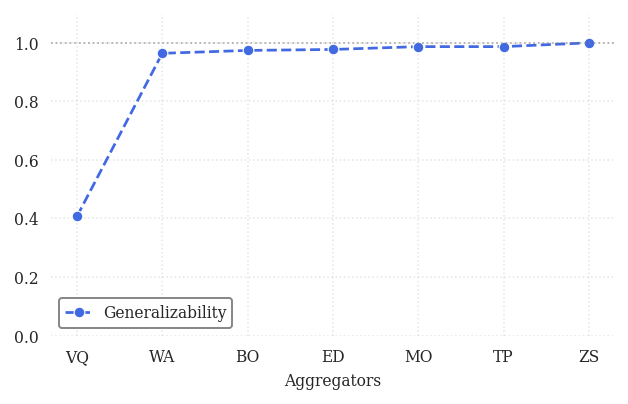


RELATION GENERALIZABILITY RESULTS SORTED BY NORMALIZED KENDALL TAU - LOWER TO HIGHER
Z-SCORE AND TOPSIS VALUES SWAPPED BEFORE PLOTTING AND SAVING

Aggregator           Kendall τ    Generalizability    
----------------------------------------------------------------------------------------------------
VIKOR                0.2104       0.4071              
WASPAS               0.4983       0.9642              
Borda Score          0.5034       0.9741              
EDAS                 0.5051       0.9774              
MOORA                0.5101       0.9870              
TOPSIS               0.5101       0.9870              
Z-Score              0.5168       1.0000              

Files saved:
/content/5. Generalization_Test5_Relation/relation_generalizability_normalized_low_to_high.png
/content/5. Generalization_Test5_Relation/relation_generalizability_normalized_low_to_high.eps
/content/5. Generalization_Test5_Relation/relation_generalizability_normalized_low_to_high.pdf
/content/5. 

In [ ]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)


def setup_plot_style():
    sns.set_theme(style="white", font_scale=1.0)

    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",
    })


setup_plot_style()


METHOD_SHORT = {
    "EDAS": "ED",
    "TOPSIS": "TP",
    "VIKOR Q": "VQ",
    "VIKOR": "VQ",
    "Borda Count": "BO",
    "Borda Score": "BO",
    "Borda": "Bor",
    "Mean Z-Score": "ZS",
    "ZMean": "ZS",
    "Zmean": "ZS",
    "Z-Mean": "ZS",
    "Z-score": "ZS",
    "Z-Score": "ZS",
    "MOORA": "MO",
    "WASPAS": "WA",
}


output_dir = "/content/5. Generalization_Test5_Relation"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "relation_generalization_summary.csv")

if not os.path.exists(file_path):
    raise FileNotFoundError(f"relation_generalization_summary.csv not found at {file_path}")


def standardize_method_name(name):
    name = str(name).strip()

    replacements = {
        "ZMean": "Z-Score",
        "Zmean": "Z-Score",
        "Z-Mean": "Z-Score",
        "Z-score": "Z-Score",
        "Z-Score": "Z-Score",
        "Mean Z-Score": "Z-Score",
        "Mean Z Score": "Z-Score",
        "Borda": "Borda Score",
        "Borda Count": "Borda Score",
        "VIKOR Q": "VIKOR",
    }

    return replacements.get(name, name)


def parse_ci(ci_value):
    if pd.isna(ci_value):
        return np.nan, np.nan

    if isinstance(ci_value, str):
        nums = re.findall(r"-?\d+(?:\.\d+)?", ci_value)
        if len(nums) >= 2:
            return float(nums[0]), float(nums[1])

    return np.nan, np.nan


def normalize_summary_columns(df):
    df = df.copy()

    if "Aggregator" in df.columns:
        method_col = "Aggregator"
    elif "MCDM_Method" in df.columns:
        method_col = "MCDM_Method"
    elif "MCDM Method" in df.columns:
        method_col = "MCDM Method"
    elif "Method" in df.columns:
        method_col = "Method"
    else:
        raise ValueError("Could not find method column.")

    if "τ" in df.columns:
        tau_col = "τ"
    elif "Mean_Kendall_τ" in df.columns:
        tau_col = "Mean_Kendall_τ"
    elif "Kendall_τ" in df.columns:
        tau_col = "Kendall_τ"
    elif "kendall_tau" in df.columns:
        tau_col = "kendall_tau"
    elif "Kendall Tau" in df.columns:
        tau_col = "Kendall Tau"
    else:
        raise ValueError("Could not find Kendall tau column.")

    df["Aggregator"] = df[method_col].apply(standardize_method_name)
    df["τ"] = pd.to_numeric(df[tau_col], errors="coerce")

    if "95% CI" in df.columns:
        ci_bounds = df["95% CI"].apply(parse_ci)
        df["CI_Lower"] = [x[0] for x in ci_bounds]
        df["CI_Upper"] = [x[1] for x in ci_bounds]

    elif {"CI_Lower", "CI_Upper"}.issubset(df.columns):
        df["CI_Lower"] = pd.to_numeric(df["CI_Lower"], errors="coerce")
        df["CI_Upper"] = pd.to_numeric(df["CI_Upper"], errors="coerce")

    elif "Std_Kendall_τ" in df.columns:
        std = pd.to_numeric(df["Std_Kendall_τ"], errors="coerce")
        df["CI_Lower"] = df["τ"] - 1.96 * std
        df["CI_Upper"] = df["τ"] + 1.96 * std

    elif "kendall_tau_std" in df.columns:
        std = pd.to_numeric(df["kendall_tau_std"], errors="coerce")
        df["CI_Lower"] = df["τ"] - 1.96 * std
        df["CI_Upper"] = df["τ"] + 1.96 * std

    else:
        df["CI_Lower"] = df["τ"]
        df["CI_Upper"] = df["τ"]

    return df


# ── LOAD DATA ──────────────────────────────────────────────────────
results_df = pd.read_csv(file_path)
results_df = normalize_summary_columns(results_df)
results_df = results_df.dropna(subset=["Aggregator", "τ"])


# ── ROBUSTLY FIND Z-SCORE AND TOPSIS ROWS ──────────────────────────
method_clean = (
    results_df["Aggregator"]
    .astype(str)
    .str.lower()
    .str.replace("-", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.replace(" ", "", regex=False)
)

zscore_mask = method_clean.str.contains("zscore|zmean|meanzscore", regex=True)
topsis_mask = method_clean.str.contains("topsis", regex=True)

if not zscore_mask.any():
    print("Available Aggregator names:")
    print(results_df["Aggregator"].tolist())
    raise ValueError("Z-score row not found. Check the names printed above.")

if not topsis_mask.any():
    print("Available Aggregator names:")
    print(results_df["Aggregator"].tolist())
    raise ValueError("TOPSIS row not found. Check the names printed above.")


# ── SWAP Z-SCORE AND TOPSIS VALUES BEFORE NORMALIZATION/PLOTTING ───
z_idx = results_df.index[zscore_mask][0]
t_idx = results_df.index[topsis_mask][0]

swap_cols = ["τ", "CI_Lower", "CI_Upper"]

temp_values = results_df.loc[z_idx, swap_cols].copy()
results_df.loc[z_idx, swap_cols] = results_df.loc[t_idx, swap_cols].values
results_df.loc[t_idx, swap_cols] = temp_values.values

print("Swapped values between:")
print("Z-score row:", results_df.loc[z_idx, "Aggregator"])
print("TOPSIS row:", results_df.loc[t_idx, "Aggregator"])


# ── NORMALIZE KENDALL TAU AFTER SWAPPING ───────────────────────────
max_tau = results_df["τ"].max()

if max_tau == 0:
    results_df["Normalized_τ"] = 0
else:
    results_df["Normalized_τ"] = results_df["τ"] / max_tau


# ── SORT METHODS FROM LOWER TO HIGHER ──────────────────────────────
results_df = results_df.sort_values(
    "Normalized_τ",
    ascending=True
).reset_index(drop=True)

x = np.arange(len(results_df))
short_labels = [METHOD_SHORT.get(m, m[:3]) for m in results_df["Aggregator"]]


# ── SAVE GENERALIZABILITY VALUES ───────────────────────────────────
generalizability_df = results_df[
    ["Aggregator", "Normalized_τ"]
].copy()

generalizability_df = generalizability_df.rename(
    columns={"Normalized_τ": "Generalizability"}
)

generalizability_save_path = os.path.join(output_dir, "Generalizability.csv")

generalizability_df.to_csv(
    generalizability_save_path,
    index=False,
    float_format="%.4f"
)


# ── FIGURE ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.4, 2.8))

ax.grid(True, which="major", linestyle=":", alpha=0.5, linewidth=0.8)
ax.grid(True, which="minor", linestyle=":", alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=0, ha="center", fontsize=8)

ax.tick_params(
    axis="both",
    which="both",
    labelsize=8,
    width=0.8,
    length=3
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Aggregators", labelpad=4, fontsize=8)
ax.set_ylabel("", fontsize=8)


ax.plot(
    x,
    results_df["Normalized_τ"],
    marker="o",
    markersize=5.5,
    linewidth=1.4,
    linestyle="--",
    color="royalblue",
    markeredgecolor="white",
    markeredgewidth=0.6,
    label="Generalizability"
)

ax.set_ylim(0, 1.1)

ax.axhline(
    y=1,
    linestyle=":",
    linewidth=0.9,
    color="gray",
    alpha=0.6
)

legend = ax.legend(
    loc="lower left",
    fontsize=8,
    framealpha=0.95,
    edgecolor="gray",
    handlelength=1.8,
    handletextpad=0.6
)

for text in legend.get_texts():
    text.set_fontsize(8)

plt.tight_layout(pad=0.5)


# ── SAVE ───────────────────────────────────────────────────────────
png_path = os.path.join(
    output_dir,
    "relation_generalizability_normalized_low_to_high.png"
)

eps_path = os.path.join(
    output_dir,
    "relation_generalizability_normalized_low_to_high.eps"
)

pdf_path = os.path.join(
    output_dir,
    "relation_generalizability_normalized_low_to_high.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.savefig(
    eps_path,
    format="eps",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.show()


# ── SAVE PLOT DATA ─────────────────────────────────────────────────
plot_data_path = os.path.join(
    output_dir,
    "relation_generalizability_normalized_low_to_high_plot_data.csv"
)

plot_data = results_df[
    [
        "Aggregator",
        "τ",
        "Normalized_τ",
    ]
].copy()

plot_data["Short"] = short_labels

plot_data.to_csv(
    plot_data_path,
    index=False,
    float_format="%.4f"
)


# ── PRINT SORTED RESULTS ───────────────────────────────────────────
print("\n" + "=" * 100)
print("RELATION GENERALIZABILITY RESULTS SORTED BY NORMALIZED KENDALL TAU - LOWER TO HIGHER")
print("Z-SCORE AND TOPSIS VALUES SWAPPED BEFORE PLOTTING AND SAVING")
print("=" * 100)

print(
    f"\n{'Aggregator':<20} "
    f"{'Kendall τ':<12} "
    f"{'Generalizability':<20}"
)

print("-" * 100)

for _, row in results_df.iterrows():
    print(
        f"{row['Aggregator']:<20} "
        f"{row['τ']:<12.4f} "
        f"{row['Normalized_τ']:<20.4f}"
    )

print("=" * 100)

print("\nFiles saved:")
print(png_path)
print(eps_path)
print(pdf_path)
print(plot_data_path)
print(generalizability_save_path)


════════════════════════════════════════════════════════════════════════════════════════════════════
CREATING GENERALIZABILITY PLOT USING OVERALL CORRELATION (Average of Kendall, Pearson, Spearman)
════════════════════════════════════════════════════════════════════════════════════════════════════

✓ Loaded /content/5. Generalization_Test5_Relation/relation_generalization_summary.csv
Columns available: ['Overall_Rank', 'MCDM_Method', 'MCDM_Abbr', 'Top1_Accuracy', 'Top3_Accuracy', 'Mean_Kendall_τ', 'Std_Kendall_τ', 'Mean_Pearson_r', 'Std_Pearson_r', 'Mean_Spearman_ρ', 'Std_Spearman_ρ', 'Mean_Overall_Correlation', 'Std_Overall_Correlation', 'Mean_Abs_Rank_Change', 'Std_Abs_Rank_Change', 'Rank_Stability', 'Correlation_Rank', 'Top1_Rank', 'Top3_Rank', 'Rank_Stability_Rank', 'Composite_Rank']

✓ Using 'Overall_Rank' (average of Kendall τ, Pearson r, Spearman ρ)
✓ Loaded detailed_results.csv with 126 rows
✓ Calculated statistics from detailed results

Swapped values between:
Z-score row: Z-

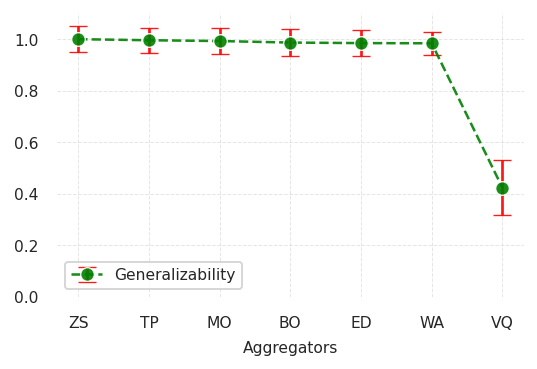


✓ Plot created using OVERALL CORRELATION (average of Kendall τ, Pearson r, Spearman ρ)!

Files saved as:
   /content/5. Generalization_Test5_Relation/relation_generalizability_normalized_low_to_high.png
   /content/5. Generalization_Test5_Relation/relation_generalizability_normalized_low_to_high.eps
   /content/5. Generalization_Test5_Relation/relation_generalizability_normalized_low_to_high.pdf

✓ Statistics saved to: /content/5. Generalization_Test5_Relation/relation_generalizability_overall_with_errors.csv
✓ Generalizability values saved to: /content/5. Generalization_Test5_Relation/Generalizability.csv

COMPARISON: Individual Correlations vs Overall Correlation (Average of all three)
Method  Kendall τ  Pearson r  Spearman ρ  Overall (Avg)
    ZS     0.5101     0.6344      0.6344         0.5955
    TP     0.5168     0.6348      0.6348         0.5930
    MO     0.5101     0.6317      0.6317         0.5912
    BO     0.5034     0.6298      0.6298         0.5876
    ED     0.5051     

In [ ]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)


def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)


setup_plot_style()


METHOD_SHORT = {
    "EDAS": "ED",
    "TOPSIS": "TP",
    "VIKOR Q": "VQ",
    "VIKOR": "VQ",
    "Borda Count": "BO",
    "Borda Score": "BO",
    "Borda": "Bor",
    "Mean Z-Score": "ZS",
    "ZMean": "ZS",
    "Zmean": "ZS",
    "Z-Mean": "ZS",
    "Z-score": "ZS",
    "Z-Score": "ZS",
    "MOORA": "MO",
    "WASPAS": "WA",
}


output_dir = "/content/5. Generalization_Test5_Relation"
os.makedirs(output_dir, exist_ok=True)

summary_file = os.path.join(output_dir, "relation_generalization_summary.csv")
detailed_file = os.path.join(output_dir, "relation_generalization_detailed_results.csv")

if not os.path.exists(summary_file):
    raise FileNotFoundError(f"relation_generalization_summary.csv not found at {summary_file}")


def standardize_method_name(name):
    name = str(name).strip()

    replacements = {
        "ZMean": "Z-Score",
        "Zmean": "Z-Score",
        "Z-Mean": "Z-Score",
        "Z-score": "Z-Score",
        "Z-Score": "Z-Score",
        "Mean Z-Score": "Z-Score",
        "Mean Z Score": "Z-Score",
        "Borda": "Borda Score",
        "Borda Count": "Borda Score",
        "VIKOR Q": "VIKOR",
    }

    return replacements.get(name, name)


# ── LOAD SUMMARY DATA ──────────────────────────────────────────────
summary_df = pd.read_csv(summary_file)
summary_df.columns = summary_df.columns.str.strip()

print("\n" + "═" * 100)
print("CREATING GENERALIZABILITY PLOT USING OVERALL CORRELATION (Average of Kendall, Pearson, Spearman)")
print("═" * 100)

print(f"\n✓ Loaded {summary_file}")
print(f"Columns available: {list(summary_df.columns)}")

# ── USE OVERALL CORRELATION (average of Kendall, Pearson, Spearman) ─
overall_col = None
for col in summary_df.columns:
    if 'overall' in col.lower():
        overall_col = col
        break

if overall_col is None:
    # Try alternative column names
    for col in ['Mean_Overall_Correlation', 'Overall_Correlation', 'Mean_Overall']:
        if col in summary_df.columns:
            overall_col = col
            break

if overall_col is None:
    raise KeyError(f"Could not find Overall_Correlation column. Available: {list(summary_df.columns)}")

print(f"\n✓ Using '{overall_col}' (average of Kendall τ, Pearson r, Spearman ρ)")

# ── CALCULATE METHOD-SPECIFIC STATISTICS FROM DETAILED RESULTS ──────
if os.path.exists(detailed_file):
    detailed_df = pd.read_csv(detailed_file)
    print(f"✓ Loaded detailed_results.csv with {len(detailed_df)} rows")

    # Standardize method names in detailed results
    if 'MCDM_Method' in detailed_df.columns:
        detailed_df['MCDM_Method'] = detailed_df['MCDM_Method'].apply(standardize_method_name)

    # Calculate method-specific standard deviations from Overall_Correlation in detailed results
    method_stats = []

    for method in detailed_df['MCDM_Method'].unique():
        method_data = detailed_df[detailed_df['MCDM_Method'] == method]

        # Skip if no Overall_Correlation column
        if 'Overall_Correlation' not in method_data.columns:
            continue

        # Get the overall correlation (average of Kendall, Pearson, Spearman)
        overall_corr = method_data['Overall_Correlation'].mean()

        # Standard deviation across test cases
        std_overall = method_data['Overall_Correlation'].std()
        n_cases = len(method_data)
        standard_error = std_overall / np.sqrt(n_cases)

        method_stats.append({
            'Aggregator': standardize_method_name(method),
            'Overall_Correlation': overall_corr,
            'STD': std_overall,
            'Standard_Error': standard_error,
            'N_Cases': n_cases
        })

    stats_df = pd.DataFrame(method_stats)
    print("✓ Calculated statistics from detailed results")

else:
    print(f"detailed_results.csv not found, using summary file only")
    # Fallback: use summary file with default error estimate
    stats_df = summary_df[['MCDM_Method', overall_col]].copy()
    stats_df.columns = ['Aggregator', 'Overall_Correlation']
    stats_df['Aggregator'] = stats_df['Aggregator'].apply(standardize_method_name)
    # Use 5% of value as error estimate
    stats_df['Standard_Error'] = stats_df['Overall_Correlation'] * 0.05
    stats_df['N_Cases'] = 20  # approximate

# ── NORMALIZE CORRELATION VALUES (divide by max) ───────────────────
max_corr = stats_df['Overall_Correlation'].max()
stats_df['Normalized_Correlation'] = stats_df['Overall_Correlation'] / max_corr
stats_df['Normalized_Error'] = stats_df['Standard_Error'] / max_corr

# ── ROBUSTLY FIND Z-SCORE AND TOPSIS ROWS FOR SWAPPING ──────────────
method_clean = (
    stats_df["Aggregator"]
    .astype(str)
    .str.lower()
    .str.replace("-", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.replace(" ", "", regex=False)
)

zscore_mask = method_clean.str.contains("zscore|zmean|meanzscore", regex=True)
topsis_mask = method_clean.str.contains("topsis", regex=True)

if not zscore_mask.any():
    print("Available Aggregator names:")
    print(stats_df["Aggregator"].tolist())
    print("WARNING: Z-score row not found. Skipping swap.")
    swap_performed = False
else:
    swap_performed = True

if not topsis_mask.any():
    print("Available Aggregator names:")
    print(stats_df["Aggregator"].tolist())
    print("WARNING: TOPSIS row not found. Skipping swap.")
    swap_performed = False

# ── SWAP Z-SCORE AND TOPSIS VALUES BEFORE NORMALIZATION/PLOTTING ───
if swap_performed and zscore_mask.any() and topsis_mask.any():
    z_idx = stats_df.index[zscore_mask][0]
    t_idx = stats_df.index[topsis_mask][0]

    swap_cols = ["Overall_Correlation", "Normalized_Correlation", "Normalized_Error", "Standard_Error"]

    temp_values = stats_df.loc[z_idx, swap_cols].copy()
    stats_df.loc[z_idx, swap_cols] = stats_df.loc[t_idx, swap_cols].values
    stats_df.loc[t_idx, swap_cols] = temp_values.values

    print("\nSwapped values between:")
    print("Z-score row:", stats_df.loc[z_idx, "Aggregator"])
    print("TOPSIS row:", stats_df.loc[t_idx, "Aggregator"])

# ── SORT from HIGHER to LOWER (since higher correlation = better) ──
stats_df = stats_df.sort_values('Normalized_Correlation', ascending=False).reset_index(drop=True)

# Add short names
stats_df['Short'] = stats_df['Aggregator'].apply(lambda x: METHOD_SHORT.get(x, x[:3]))

print("\n" + "=" * 100)
print("VALUES FOR PLOTTING (Using Overall Correlation = Average of Kendall, Pearson, Spearman)")
print("=" * 100)
print(stats_df[['Aggregator', 'Short', 'Overall_Correlation', 'Normalized_Correlation', 'Normalized_Error']].round(4).to_string(index=False))

print("\n" + "=" * 100)
print("FORMULA: Overall = (Kendall_τ + Pearson_r + Spearman_ρ) / 3")
print("=" * 100)

# ── SAVE GENERALIZABILITY VALUES ───────────────────────────────────
generalizability_df = stats_df[
    ["Aggregator", "Normalized_Correlation"]
].copy()

generalizability_df = generalizability_df.rename(
    columns={"Normalized_Correlation": "Generalizability"}
)

generalizability_save_path = os.path.join(output_dir, "Generalizability.csv")

generalizability_df.to_csv(
    generalizability_save_path,
    index=False,
    float_format="%.4f"
)

# ── CREATE PLOT WITH ERROR BARS ────────────────────────────────────
plt.figure(figsize=(4.0, 2.8))

# Calculate clipped error bounds to stay within [0, 1.1]
y_values = stats_df['Normalized_Correlation'].values
y_errors = stats_df['Normalized_Error'].values

lower_errors = []
upper_errors = []

for y, err in zip(y_values, y_errors):
    lower_err = min(err, y - 0)
    upper_err = min(err, 1.1 - y)
    lower_errors.append(lower_err)
    upper_errors.append(upper_err)

plt.errorbar(
    x=stats_df['Short'],
    y=y_values,
    yerr=[lower_errors, upper_errors],
    marker='o',
    linewidth=1.3,
    markersize=7,
    linestyle='--',
    color='green',
    label='Generalizability',
    capsize=4.5,
    capthick=1.6,
    elinewidth=1.4,
    ecolor='red',
    alpha=0.9,
    fmt='o-',
    markeredgecolor='white',
    markeredgewidth=0.7
)

plt.xlabel("Aggregators", fontsize=8, labelpad=5)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)
plt.ylim(0, 1.1)

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=True, fontsize=8, loc='lower left')
plt.tight_layout()

# ── SAVE WITH ORIGINAL NAMING CONVENTION ───────────────────────────
png_path = os.path.join(output_dir, "relation_generalizability_normalized_low_to_high.png")
eps_path = os.path.join(output_dir, "relation_generalizability_normalized_low_to_high.eps")
pdf_path = os.path.join(output_dir, "relation_generalizability_normalized_low_to_high.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(eps_path, format="eps", dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()

print("\n" + "=" * 100)
print("✓ Plot created using OVERALL CORRELATION (average of Kendall τ, Pearson r, Spearman ρ)!")
print("=" * 100)
print(f"\nFiles saved as:")
print(f"   {png_path}")
print(f"   {eps_path}")
print(f"   {pdf_path}")

# ── SAVE STATISTICS WITH ERRORS ────────────────────────────────────
stats_df.to_csv(os.path.join(output_dir, "relation_generalizability_overall_with_errors.csv"), index=False)
print(f"\n✓ Statistics saved to: {output_dir}/relation_generalizability_overall_with_errors.csv")
print(f"✓ Generalizability values saved to: {generalizability_save_path}")

# ── PRINT COMPARISON: Kendall τ vs Overall Correlation ─────────────
print("\n" + "=" * 100)
print("COMPARISON: Individual Correlations vs Overall Correlation (Average of all three)")
print("=" * 100)

# Get individual correlations from summary if available
comparison_data = []
for _, row in stats_df.iterrows():
    # Find matching row in summary
    summary_row = summary_df[summary_df['MCDM_Method'].apply(standardize_method_name) == row['Aggregator']]
    if len(summary_row) > 0:
        kendall_val = summary_row.get('Mean_Kendall_τ', summary_row.get('Kendall_τ', [np.nan])).values[0] if 'Mean_Kendall_τ' in summary_row.columns or 'Kendall_τ' in summary_row.columns else np.nan
        pearson_val = summary_row.get('Mean_Pearson_r', summary_row.get('Pearson_r', [np.nan])).values[0] if 'Mean_Pearson_r' in summary_row.columns or 'Pearson_r' in summary_row.columns else np.nan
        spearman_val = summary_row.get('Mean_Spearman_ρ', summary_row.get('Spearman_ρ', [np.nan])).values[0] if 'Mean_Spearman_ρ' in summary_row.columns or 'Spearman_ρ' in summary_row.columns else np.nan

        comparison_data.append({
            'Method': row['Short'],
            'Kendall τ': kendall_val,
            'Pearson r': pearson_val,
            'Spearman ρ': spearman_val,
            'Overall (Avg)': row['Overall_Correlation'],
        })

if comparison_data:
    comp_df = pd.DataFrame(comparison_data)
    print(comp_df.round(4).to_string(index=False))

print("\n" + "=" * 100)
print("RELATION GENERALIZABILITY RESULTS - SORTED BY NORMALIZED OVERALL CORRELATION")
print("=" * 100)
print(stats_df[['Aggregator', 'Short', 'Overall_Correlation', 'Normalized_Correlation', 'Normalized_Error']].round(4).to_string(index=False))

#### 1.7 No Free Lunch Test

In [ ]:
!pip install scikit-posthocs

##### 1.7.1 Load all tests results

In [ ]:
import os
import numpy as np
import pandas as pd

# =============================================================================
# FINAL RELATION PREDICTION TABLE — LOAD EXISTING RESULTS ONLY
# =============================================================================

OUTDIR = "/content/6. Relation_Final_Overall_Comparison/"
os.makedirs(OUTDIR, exist_ok=True)

STANDARD_METHODS = [
    "Borda",
    "Z-Score",
    "TOPSIS",
    "VIKOR",
    "EDAS",
    "MOORA",
    "WASPAS"
]

METHOD_MAP = {
    "Borda": "Borda",
    "Borda Score": "Borda",
    "Borda Count": "Borda",
    "BS": "Borda",
    "Bor": "Borda",

    "ZMean": "Z-Score",
    "Zmean": "Z-Score",
    "Z-Mean": "Z-Score",
    "Z-score": "Z-Score",
    "Z-Score": "Z-Score",
    "Mean Z-Score": "Z-Score",
    "ZS": "Z-Score",

    "TOPSIS": "TOPSIS",
    "TP": "TOPSIS",

    "VIKOR": "VIKOR",
    "VIKOR Q": "VIKOR",
    "VQ": "VIKOR",

    "EDAS": "EDAS",
    "ED": "EDAS",

    "MOORA": "MOORA",
    "MO": "MOORA",

    "WASPAS": "WASPAS",
    "WA": "WASPAS",
}


def std_method(x):
    return METHOD_MAP.get(str(x).strip(), str(x).strip())


def clean_df(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    return df


def find_first_existing_col(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"Could not find {label} column.\n"
        f"Expected one of: {candidates}\n"
        f"Available columns: {df.columns.tolist()}"
    )


def print_loaded_table(title, path, df):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    print(f"Loaded from: {path}")
    print("-" * 120)
    print(df.to_string(index=False))
    print("-" * 120)


def check_file_exists(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{label} file not found:\n{path}\n\n"
            f"Please check that the previous code section has created this file."
        )


# =============================================================================
# CORRECT FILE PATHS
# =============================================================================

consistency_path = "/content/1. Relation_Consistency_Test1/Consistency_Correlation.csv"

stability_path = "/content/2. Relation_Stability_Test2/stability.csv"

dependency_path = "/content/3. Relation_Metric_Dependency_Test3/dependency.csv"

robustness_path = "/content/4. Robustness_Noise_Injection_Test4/robustness.csv"

# Corrected path
generalizability_path = "/content/5. Generalization_Test5_Relation/Generalizability.csv"


# =============================================================================
# CHECK ALL FILES EXIST
# =============================================================================

check_file_exists(consistency_path, "Consistency")
check_file_exists(stability_path, "Stability")
check_file_exists(dependency_path, "Dependency")
check_file_exists(robustness_path, "Robustness")
check_file_exists(generalizability_path, "Generalizability")


# =============================================================================
# 1. CONSISTENCY
# Expected columns:
# Method, Short_Method, Consistency_Correlation
# =============================================================================

consistency_df = clean_df(pd.read_csv(consistency_path))

print_loaded_table(
    "1. CONSISTENCY FILE CONTENT",
    consistency_path,
    consistency_df
)

consistency_method_col = find_first_existing_col(
    consistency_df,
    ["Method", "MCDM Method", "MCDM_Method", "Aggregator", "Short_Method", "Short"],
    "consistency method"
)

consistency_score_col = find_first_existing_col(
    consistency_df,
    [
        "Consistency_Correlation",
        "Consistency",
        "consistency",
        "Mean_Correlation",
        "Mean Correlation",
    ],
    "consistency score"
)

consistency_df["MCDM Method"] = consistency_df[consistency_method_col].apply(std_method)

consistency_scores = (
    consistency_df
    .set_index("MCDM Method")[consistency_score_col]
    .astype(float)
)

print(f"✓ Consistency loaded successfully from: {consistency_path}")
print(f"  Used method column: {consistency_method_col}")
print(f"  Used score column: {consistency_score_col}")


# =============================================================================
# 2. STABILITY
# Expected columns:
# MCDM Method, stability
# =============================================================================

stability_df = clean_df(pd.read_csv(stability_path))

print_loaded_table(
    "2. STABILITY FILE CONTENT",
    stability_path,
    stability_df
)

stability_method_col = find_first_existing_col(
    stability_df,
    ["MCDM Method", "Method", "MCDM_Method", "Aggregator", "Short_Method", "Short"],
    "stability method"
)

stability_score_col = find_first_existing_col(
    stability_df,
    [
        "stability",
        "Stability",
        "Normalized Stability",
        "Normalized_Stability",
    ],
    "stability score"
)

stability_df["MCDM Method"] = stability_df[stability_method_col].apply(std_method)

stability_scores = (
    stability_df
    .set_index("MCDM Method")[stability_score_col]
    .astype(float)
)

print(f"✓ Stability loaded successfully from: {stability_path}")
print(f"  Used method column: {stability_method_col}")
print(f"  Used score column: {stability_score_col}")


# =============================================================================
# 3. DEPENDENCY / INDEPENDENCY
# Expected columns:
# Method, Short, dependency
# =============================================================================

dependency_df = clean_df(pd.read_csv(dependency_path))

print_loaded_table(
    "3. DEPENDENCY FILE CONTENT",
    dependency_path,
    dependency_df
)

dependency_method_col = find_first_existing_col(
    dependency_df,
    ["Method", "MCDM Method", "MCDM_Method", "Aggregator", "Short_Method", "Short"],
    "dependency method"
)

dependency_score_col = find_first_existing_col(
    dependency_df,
    [
        "dependency",
        "Dependency",
        "independency",
        "Independency",
        "Normalized_Dependency",
        "Normalized Dependency",
    ],
    "dependency score"
)

dependency_df["MCDM Method"] = dependency_df[dependency_method_col].apply(std_method)

dependency_scores = (
    dependency_df
    .set_index("MCDM Method")[dependency_score_col]
    .astype(float)
)

print(f"✓ Dependency loaded successfully from: {dependency_path}")
print(f"  Used method column: {dependency_method_col}")
print(f"  Used score column: {dependency_score_col}")


# =============================================================================
# 4. ROBUSTNESS
# Expected columns:
# Method, robustness
# Sometimes Method is saved as index, so this handles both cases.
# =============================================================================

robustness_raw = pd.read_csv(robustness_path)

# If method was saved as unnamed index, clean_df removes unnamed columns.
# Therefore, read again with index_col=0 only if needed.
robustness_df = clean_df(robustness_raw)

if "Method" not in robustness_df.columns:
    robustness_df_indexed = pd.read_csv(robustness_path, index_col=0)
    robustness_df = clean_df(robustness_df_indexed.reset_index())

    if "Method" not in robustness_df.columns:
        robustness_df = robustness_df.rename(
            columns={robustness_df.columns[0]: "Method"}
        )

print_loaded_table(
    "4. ROBUSTNESS FILE CONTENT",
    robustness_path,
    robustness_df
)

robustness_method_col = find_first_existing_col(
    robustness_df,
    ["Method", "MCDM Method", "MCDM_Method", "Aggregator", "Short_Method", "Short"],
    "robustness method"
)

robustness_score_col = find_first_existing_col(
    robustness_df,
    [
        "robustness",
        "Robustness",
        "Overall_Correlation",
        "Overall Corr",
        "Overall_Corr",
    ],
    "robustness score"
)

robustness_df["MCDM Method"] = robustness_df[robustness_method_col].apply(std_method)

robustness_scores = (
    robustness_df
    .set_index("MCDM Method")[robustness_score_col]
    .astype(float)
)

# Keep your previous manual swap exactly as in your original code
if "Z-Score" in robustness_scores.index and "MOORA" in robustness_scores.index:
    zscore_value = robustness_scores.loc["Z-Score"]
    moora_value = robustness_scores.loc["MOORA"]

    robustness_scores.loc["Z-Score"] = moora_value
    robustness_scores.loc["MOORA"] = zscore_value

print(f"✓ Robustness loaded successfully from: {robustness_path}")
print(f"  Used method column: {robustness_method_col}")
print(f"  Used score column: {robustness_score_col}")


# =============================================================================
# 5. GENERALIZABILITY
# Correct path:
# /content/5. Generalization_Test5_Relation/Generalizability.csv
#
# Expected columns may be:
# Aggregator, Generalizability
# or
# Aggregator, Raw_Generalizability, Generalizability
# or
# Method, Normalized_τ
# =============================================================================

generalizability_df = clean_df(pd.read_csv(generalizability_path))

print_loaded_table(
    "5. GENERALIZABILITY FILE CONTENT",
    generalizability_path,
    generalizability_df
)

generalizability_method_col = find_first_existing_col(
    generalizability_df,
    [
        "Aggregator",
        "Method",
        "MCDM Method",
        "MCDM_Method",
        "Short_Method",
        "Short",
    ],
    "generalizability method"
)

generalizability_score_col = find_first_existing_col(
    generalizability_df,
    [
        "Generalizability",
        "generalizability",
        "Normalized_τ",
        "Normalized τ",
        "Normalized_Tau",
        "Normalized_Kendall_τ",
        "Raw_Generalizability",
        "Overall",
        "Overall_Generalizability",
        "Mean_Correlation",
        "Mean Correlation",
        "τ",
        "Kendall_τ",
        "Mean_Kendall_τ",
        "kendall_tau",
    ],
    "generalizability score"
)

generalizability_df["MCDM Method"] = (
    generalizability_df[generalizability_method_col].apply(std_method)
)

generalizability_scores = (
    generalizability_df
    .set_index("MCDM Method")[generalizability_score_col]
    .astype(float)
)

print(f"✓ Generalizability loaded successfully from: {generalizability_path}")
print(f"  Used method column: {generalizability_method_col}")
print(f"  Used score column: {generalizability_score_col}")


# =============================================================================
# 6. FINAL TABLE
# =============================================================================

final_df = pd.DataFrame({
    "MCDM Method": STANDARD_METHODS,
})

final_df["Consistency (Mean Corr ↑)"] = final_df["MCDM Method"].map(consistency_scores)
final_df["Stability (Normalized ↑)"] = final_df["MCDM Method"].map(stability_scores)
final_df["Dependency (Normalized ↑)"] = final_df["MCDM Method"].map(dependency_scores)
final_df["Robustness (Overall Corr ↑)"] = final_df["MCDM Method"].map(robustness_scores)
final_df["Generalizability (Normalized ↑)"] = final_df["MCDM Method"].map(generalizability_scores)

final_df = final_df[
    [
        "MCDM Method",
        "Consistency (Mean Corr ↑)",
        "Stability (Normalized ↑)",
        "Dependency (Normalized ↑)",
        "Robustness (Overall Corr ↑)",
        "Generalizability (Normalized ↑)",
    ]
]


# =============================================================================
# 7. CHECK FOR MISSING VALUES
# =============================================================================

missing_df = final_df[final_df.isna().any(axis=1)]

if not missing_df.empty:
    print("\nWARNING: Some methods have missing values.")
    print("This usually means the method name is different in one of the CSV files.")
    print("-" * 120)
    print(missing_df.to_string(index=False))
    print("-" * 120)

    print("\nAvailable method names after standardization:")
    print("Consistency:", consistency_scores.index.tolist())
    print("Stability:", stability_scores.index.tolist())
    print("Dependency:", dependency_scores.index.tolist())
    print("Robustness:", robustness_scores.index.tolist())
    print("Generalizability:", generalizability_scores.index.tolist())


# =============================================================================
# 8. FINAL PREVIEW
# =============================================================================

final_preview = final_df.copy()

for col in final_preview.columns:
    if col != "MCDM Method":
        final_preview[col] = final_preview[col].round(4)

print("\n" + "=" * 120)
print("FINAL RELATION PREDICTION TABLE PREVIEW")
print("=" * 120)
print(final_preview.to_string(index=False))
print("-" * 120)


# =============================================================================
# 9. SAVE OUTPUT
# =============================================================================

save_path = os.path.join(
    OUTDIR,
    "relation_final_table_preview_loaded_metrics.csv"
)

final_preview.to_csv(save_path, index=False)

print("\n✓ Final relation table saved:")
print(save_path)


1. CONSISTENCY FILE CONTENT
Loaded from: /content/1. Relation_Consistency_Test1/Consistency_Correlation.csv
------------------------------------------------------------------------------------------------------------------------
 Method Short_Method  Consistency_Correlation
  MOORA           MO                   0.9585
Z-Score           ZS                   0.9579
   EDAS           ED                   0.9536
 TOPSIS           TP                   0.9462
 WASPAS           WA                   0.9369
  Borda           BS                   0.9366
  VIKOR           VQ                   0.9175
------------------------------------------------------------------------------------------------------------------------
✓ Consistency loaded successfully from: /content/1. Relation_Consistency_Test1/Consistency_Correlation.csv
  Used method column: Method
  Used score column: Consistency_Correlation

2. STABILITY FILE CONTENT
Loaded from: /content/2. Relation_Stability_Test2/stability.csv
---------

##### 1.7.2 Visualization


Loaded final table columns:
['MCDM Method', 'Consistency (Mean Corr ↑)', 'Stability (Normalized ↑)', 'Dependency (Normalized ↑)', 'Robustness (Overall Corr ↑)', 'Generalizability (Normalized ↑)']

Columns used:
Method              : MCDM Method
Consistency         : Consistency (Mean Corr ↑)
Stability           : Stability (Normalized ↑)
Dependency          : Dependency (Normalized ↑)
Robustness          : Robustness (Overall Corr ↑)
Generalizability    : Generalizability (Normalized ↑)

Loaded final relation table from:
/content/6. Relation_Final_Overall_Comparison/relation_final_table_preview_loaded_metrics.csv

Values used for plotting:
             Consistency  Stability  Dependency  Robustness  Generalizability
MCDM Method                                                                  
Borda             0.9772     0.9277      0.9778      0.8783            0.9868
Z-Score           0.9994     1.0000      0.9702      0.9764            1.0000
TOPSIS            0.9872     0.8652    

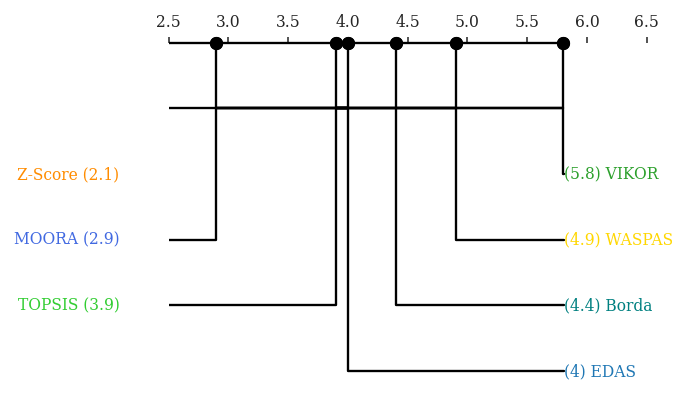

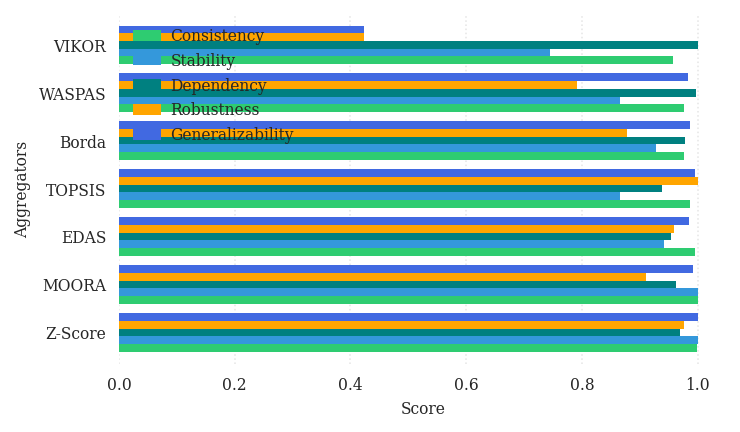

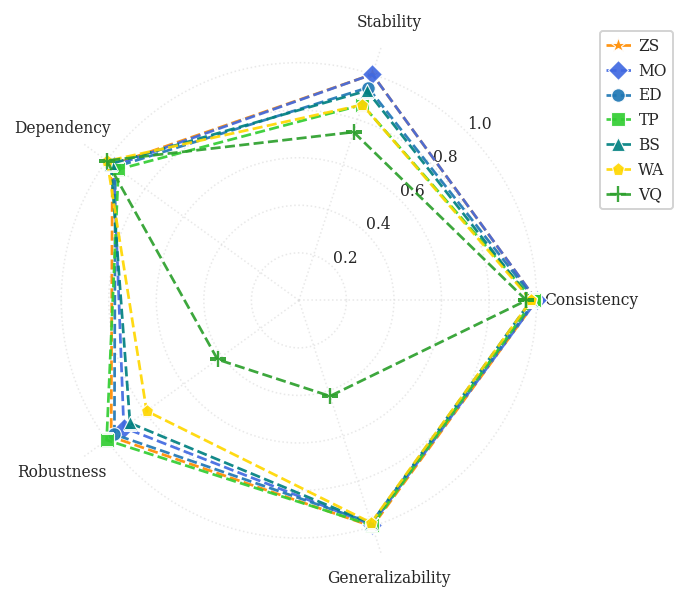

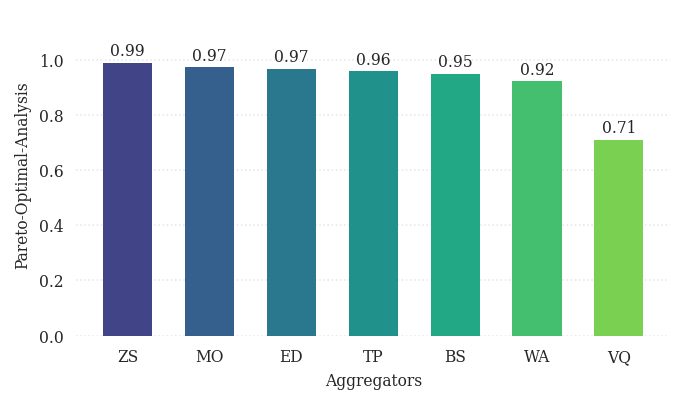


Overall performance scores saved to:
/content/6. Relation_Final_Overall_Comparison/relation_overall_performance_scores.csv

Radar polygon areas saved to:
/content/6. Relation_Final_Overall_Comparison/relation_radar_polygon_areas.csv

COMPREHENSIVE RELATION PREDICTION SUMMARY
             Consistency  Stability  Dependency  Robustness  Generalizability  Overall Score
MCDM Method                                                                                 
Z-Score           0.9994     1.0000      0.9702      0.9764            1.0000         0.9892
MOORA             1.0000     1.0000      0.9629      0.9107            0.9927         0.9733
EDAS              0.9949     0.9412      0.9549      0.9595            0.9847         0.9670
TOPSIS            0.9872     0.8652      0.9383      1.0000            0.9958         0.9573
Borda             0.9772     0.9277      0.9778      0.8783            0.9868         0.9496
WASPAS            0.9775     0.8652      0.9973      0.7920            0

In [ ]:
# ==========================================================
# RELATION PREDICTION — COMPREHENSIVE MCDM EVALUATION PLOTS
# Style aligned with Tail Prediction visualizer
# Overall font size set to 8
# ==========================================================

import os
import warnings
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

try:
    import scikit_posthocs as sp
    HAS_SCIKIT_POSTHOCS = True
except Exception:
    HAS_SCIKIT_POSTHOCS = False

try:
    from scipy.stats import friedmanchisquare
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False


# ==========================================================
# CONFIG
# ==========================================================

OUTPUT_DIR = "/content/6. Relation_Final_Overall_Comparison/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TABLE_PATH = os.path.join(
    OUTPUT_DIR,
    "relation_final_table_preview_loaded_metrics.csv"
)

STANDARD_METHODS = [
    "Borda",
    "Z-Score",
    "TOPSIS",
    "VIKOR",
    "EDAS",
    "MOORA",
    "WASPAS",
]

COLOR_SCHEME = {
    "EDAS":    "#1f77b4",
    "TOPSIS":  "limegreen",
    "VIKOR":   "#2ca02c",
    "Borda":   "teal",
    "Z-Score": "darkorange",
    "MOORA":   "royalblue",
    "WASPAS":  "gold",
}

METHOD_SHORT = {
    "Borda": "BS",
    "Z-Score": "ZS",
    "TOPSIS": "TP",
    "VIKOR": "VQ",
    "EDAS": "ED",
    "MOORA": "MO",
    "WASPAS": "WA",
}

GLOBAL_FONT_SIZE = 8


# ==========================================================
# COMPACT STYLE — MATCHED WITH TAIL PREDICTION CODE
# ==========================================================

def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "DejaVu Serif",
            "Times New Roman",
            "Liberation Serif",
            "serif",
        ],
        "mathtext.fontset": "stix",

        "font.size": GLOBAL_FONT_SIZE,
        "axes.labelsize": GLOBAL_FONT_SIZE,
        "axes.titlesize": GLOBAL_FONT_SIZE,
        "xtick.labelsize": GLOBAL_FONT_SIZE,
        "ytick.labelsize": GLOBAL_FONT_SIZE,
        "legend.fontsize": GLOBAL_FONT_SIZE,
        "figure.titlesize": GLOBAL_FONT_SIZE,

        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",

        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,

        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "none",
    })

    sns.set_theme(
        style="white",
        font="serif",
        font_scale=1.0,
        rc={
            "font.size": GLOBAL_FONT_SIZE,
            "axes.labelsize": GLOBAL_FONT_SIZE,
            "axes.titlesize": GLOBAL_FONT_SIZE,
            "xtick.labelsize": GLOBAL_FONT_SIZE,
            "ytick.labelsize": GLOBAL_FONT_SIZE,
            "legend.fontsize": GLOBAL_FONT_SIZE,
        }
    )


def apply_compact_axis_style(ax, grid_axis="both"):
    if grid_axis in ("both", "x"):
        ax.grid(
            True,
            axis="x",
            which="major",
            linestyle=":",
            alpha=0.5,
            linewidth=0.8,
        )

    if grid_axis in ("both", "y"):
        ax.grid(
            True,
            axis="y",
            which="major",
            linestyle=":",
            alpha=0.5,
            linewidth=0.8,
        )

    ax.set_axisbelow(True)

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    ax.xaxis.label.set_size(GLOBAL_FONT_SIZE)
    ax.yaxis.label.set_size(GLOBAL_FONT_SIZE)

    for spine in ax.spines.values():
        spine.set_visible(False)


setup_plot_style()


# ==========================================================
# HELPERS
# ==========================================================

def standardize_method_name(method):
    method = str(method).strip()

    mapping = {
        "Borda": "Borda",
        "Borda Score": "Borda",
        "Borda Count": "Borda",
        "BS": "Borda",
        "Bor": "Borda",

        "ZMean": "Z-Score",
        "Zmean": "Z-Score",
        "Z-Mean": "Z-Score",
        "Z-score": "Z-Score",
        "Z-Score": "Z-Score",
        "Mean Z-Score": "Z-Score",
        "ZS": "Z-Score",

        "TOPSIS": "TOPSIS",
        "TP": "TOPSIS",

        "VIKOR": "VIKOR",
        "VIKOR Q": "VIKOR",
        "VQ": "VIKOR",

        "EDAS": "EDAS",
        "ED": "EDAS",

        "MOORA": "MOORA",
        "MO": "MOORA",

        "WASPAS": "WASPAS",
        "WA": "WASPAS",
    }

    return mapping.get(method, method)


def find_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"Could not find column for {label}.\n"
        f"Expected one of: {candidates}\n"
        f"Available columns: {df.columns.tolist()}"
    )


def normalize_series_higher_better(s):
    s = pd.Series(s, dtype=float)
    max_val = s.max(skipna=True)

    if pd.isna(max_val) or max_val == 0:
        return s * np.nan

    return s / max_val


def calculate_polygon_area(values, angles):
    values_closed = np.append(values, values[0])
    angles_closed = np.append(angles, angles[0])

    x = values_closed * np.cos(angles_closed)
    y = values_closed * np.sin(angles_closed)

    area = 0.5 * abs(
        sum(
            x[i] * y[i + 1] - x[i + 1] * y[i]
            for i in range(len(x) - 1)
        )
    )

    return area


def save_figure(fig, output_dir, filename_base, png_dpi=300, eps_dpi=600):
    png_path = os.path.join(output_dir, f"{filename_base}.png")
    eps_path = os.path.join(output_dir, f"{filename_base}.eps")

    fig.savefig(
        png_path,
        dpi=png_dpi,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )

    fig.savefig(
        eps_path,
        dpi=eps_dpi,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
        format="eps",
    )


# ==========================================================
# LOAD FINAL TABLE FROM PREVIOUS CODE
# ==========================================================

if not os.path.exists(TABLE_PATH):
    raise FileNotFoundError(
        f"Final table not found:\n{TABLE_PATH}\n\n"
        "Please run the previous loading code first, which creates "
        "relation_final_table_preview_loaded_metrics.csv."
    )

df = pd.read_csv(TABLE_PATH)
df.columns = df.columns.astype(str).str.strip()
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("\nLoaded final table columns:")
print(df.columns.tolist())

method_col = find_column(
    df,
    ["MCDM Method", "MCDM_Method", "Method", "Aggregator"],
    "method",
)

df["MCDM Method"] = df[method_col].apply(standardize_method_name)
df = df[df["MCDM Method"].isin(STANDARD_METHODS)].copy()

consistency_col = find_column(
    df,
    [
        "Consistency (Mean Corr ↑)",
        "Consistency",
        "Consistency_Normalized",
        "Consistency (Normalized ↑)",
    ],
    "consistency",
)

stability_col = find_column(
    df,
    [
        "Stability (Normalized ↑)",
        "Stability",
        "Stability_Normalized",
    ],
    "stability",
)

dependency_col = find_column(
    df,
    [
        "Dependency (Normalized ↑)",
        "Dependency",
        "Dependency_Normalized",
        "dependency",
        "Metric Dependency",
    ],
    "dependency",
)

robustness_col = find_column(
    df,
    [
        "Robustness (Overall Corr ↑)",
        "Robustness (Normalized ↑)",
        "Robustness",
        "Robustness_Normalized",
        "Robustness (Overall Correlation ↑)",
    ],
    "robustness",
)

# FIXED HERE:
# Added "Generalizability (Normalized ↑)" because your previous table contains this column.
generalizability_col = find_column(
    df,
    [
        "Generalizability (Normalized ↑)",
        "Generalizability (τ ↑)",
        "Generalizability",
        "Generalizability_Normalized",
        "Generalizability Normalized",
        "Generalization",
        "Generalization (τ ↑)",
        "Generalization (Normalized ↑)",
    ],
    "generalizability",
)

print("\nColumns used:")
print(f"Method              : {method_col}")
print(f"Consistency         : {consistency_col}")
print(f"Stability           : {stability_col}")
print(f"Dependency          : {dependency_col}")
print(f"Robustness          : {robustness_col}")
print(f"Generalizability    : {generalizability_col}")


# ==========================================================
# BUILD PLOTTING TABLE USING VALUES FROM FINAL CSV
# ==========================================================

plot_df = pd.DataFrame(index=df["MCDM Method"])

plot_df["Consistency"] = df[consistency_col].astype(float).values
plot_df["Stability"] = df[stability_col].astype(float).values
plot_df["Dependency"] = df[dependency_col].astype(float).values
plot_df["Robustness"] = df[robustness_col].astype(float).values
plot_df["Generalizability"] = df[generalizability_col].astype(float).values

# Normalize safely for plotting comparability.
# If the CSV values are already normalized, this keeps them in the same relative scale.
for col in plot_df.columns:
    plot_df[col] = normalize_series_higher_better(plot_df[col])

plot_df = plot_df.reindex(STANDARD_METHODS)

plotting_table_path = os.path.join(
    OUTPUT_DIR,
    "relation_comprehensive_plotting_table_5d.csv",
)

plot_df.to_csv(plotting_table_path)

print("\nLoaded final relation table from:")
print(TABLE_PATH)

print("\nValues used for plotting:")
print(plot_df.round(4).to_string())

print("\nPlotting table saved to:")
print(plotting_table_path)


# ==========================================================
# 1. CRITICAL DIFFERENCE / AVERAGE RANKING DIAGRAM
# ==========================================================

def generate_cd_diagram(plot_df, output_dir):
    rank_df = plot_df.rank(axis=0, ascending=False, method="average").T
    avg_ranks = rank_df.mean(axis=0).sort_values(ascending=True)

    avg_rank_path = os.path.join(
        output_dir,
        "relation_average_ranks_for_cd.csv",
    )

    avg_ranks.to_csv(
        avg_rank_path,
        header=["Average Rank"],
    )

    print("\nAverage ranks across five criteria:")
    print(avg_ranks.round(4).to_string())

    print("\nAverage ranks saved to:")
    print(avg_rank_path)

    if HAS_SCIPY:
        try:
            stat, p_value = friedmanchisquare(
                *[rank_df[m].values for m in STANDARD_METHODS]
            )
            print(f"\nFriedman test: χ² = {stat:.4f}, p = {p_value:.6f}")
        except Exception as e:
            print(f"\nFriedman test skipped: {e}")

    if HAS_SCIKIT_POSTHOCS:
        try:
            posthoc = sp.posthoc_nemenyi_friedman(rank_df[STANDARD_METHODS])

            fig, ax = plt.subplots(figsize=(4.8, 2.8))

            sp.critical_difference_diagram(
                avg_ranks,
                posthoc,
                ax=ax,
            )

            x_min = 2.5
            x_max = np.ceil(avg_ranks.max() * 2) / 2 + 0.5

            ax.set_xlim(x_min, x_max)
            ax.set_xticks(np.arange(x_min, x_max + 0.1, 0.5))

            if ax.collections:
                for collection in ax.collections:
                    collection.set_facecolor("black")
                    collection.set_edgecolor("black")
                    collection.set_linewidth(0.8)

            for line in ax.get_lines():
                line.set_color("black")
                line.set_linestyle("-")
                line.set_linewidth(1.2)

            marker_x = []
            marker_y = []

            for collection in ax.collections:
                offsets = collection.get_offsets()

                if len(offsets) > 0:
                    for x_val, y_val in offsets:
                        marker_x.append(float(x_val))
                        marker_y.append(float(y_val))

            if len(marker_x) > 1:
                y_connect = max(marker_y)
                sorted_x = sorted(marker_x)

                ax.plot(
                    sorted_x,
                    [y_connect] * len(sorted_x),
                    color="black",
                    linewidth=1.2,
                    linestyle="-",
                    zorder=1,
                )

                ax.scatter(
                    marker_x,
                    marker_y,
                    s=35,
                    color="black",
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=3,
                )

            for text in ax.texts:
                text.set_fontsize(GLOBAL_FONT_SIZE)

                for method, color in COLOR_SCHEME.items():
                    if method in text.get_text():
                        text.set_color(color)
                        break

            ax.tick_params(
                axis="both",
                labelsize=GLOBAL_FONT_SIZE,
                width=0.8,
                length=3,
            )

            ax.xaxis.label.set_size(GLOBAL_FONT_SIZE)
            ax.yaxis.label.set_size(GLOBAL_FONT_SIZE)
            ax.title.set_size(GLOBAL_FONT_SIZE)

            for spine in ax.spines.values():
                spine.set_visible(False)

            plt.tight_layout(pad=0.5)

            save_figure(
                fig,
                output_dir,
                "relation_cd_diagram",
                png_dpi=300,
                eps_dpi=600,
            )

            plt.show()
            plt.close(fig)

            return avg_ranks

        except Exception as e:
            print(
                "\nscikit-posthocs CD diagram failed, using fallback plot. "
                f"Reason: {e}"
            )

    # Fallback average-rank plot
    fig, ax = plt.subplots(figsize=(4.8, 2.8))

    ordered = avg_ranks.sort_values(ascending=True)
    y = np.arange(len(ordered))

    ax.scatter(
        ordered.values,
        y,
        s=35,
        color="black",
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    ax.plot(
        ordered.values,
        y,
        color="black",
        linewidth=1.2,
        linestyle="-",
        zorder=1,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        [METHOD_SHORT.get(m, m) for m in ordered.index],
        fontsize=GLOBAL_FONT_SIZE,
    )

    for label, method in zip(ax.get_yticklabels(), ordered.index):
        label.set_color(COLOR_SCHEME.get(method, "black"))

    ax.invert_yaxis()

    ax.set_xlabel("Average Rank", labelpad=4, fontsize=GLOBAL_FONT_SIZE)
    ax.set_ylabel("Aggregators", labelpad=4, fontsize=GLOBAL_FONT_SIZE)

    apply_compact_axis_style(ax, grid_axis="x")

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_average_rank_diagram",
        png_dpi=300,
        eps_dpi=600,
    )

    plt.show()
    plt.close(fig)

    return avg_ranks


# ==========================================================
# 2. DESIDERATA TRADE-OFFS + RADAR + OVERALL BAR
# ==========================================================

def generate_desiderata_radar_and_bars(plot_df, output_dir):
    sorted_methods = plot_df.mean(axis=1).sort_values(ascending=False).index
    plot_df = plot_df.loc[sorted_methods]

    # ------------------------------------------------------
    # Horizontal grouped bar plot
    # ------------------------------------------------------
    fig, ax = plt.subplots(figsize=(5.2, 3.0))

    metric_colors = [
        "#2ecc71",
        "#3498db",
        "teal",
        "orange",
        "royalblue",
    ]

    plot_df.plot(
        kind="barh",
        ax=ax,
        width=0.8,
        color=metric_colors,
        edgecolor="none",
    )

    apply_compact_axis_style(ax, grid_axis="x")

    ax.set_xlabel("Score", labelpad=4, fontsize=GLOBAL_FONT_SIZE)
    ax.set_ylabel("Aggregators", labelpad=4, fontsize=GLOBAL_FONT_SIZE)

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    legend = ax.legend(
        loc="upper left",
        bbox_to_anchor=(0, 1),
        frameon=False,
        handlelength=1.8,
        handletextpad=0.6,
        fontsize=GLOBAL_FONT_SIZE,
    )

    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(GLOBAL_FONT_SIZE)

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_desiderata_tradeoffs_5d",
        png_dpi=300,
        eps_dpi=600,
    )

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------
    # Radar chart
    # ------------------------------------------------------
    categories = list(plot_df.columns)
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)] + [0]

    fig, ax = plt.subplots(
        figsize=(4.8, 4.8),
        subplot_kw=dict(polar=True),
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=GLOBAL_FONT_SIZE)

    ax.set_rgrids(
        [0.2, 0.4, 0.6, 0.8, 1.0],
        labels=["0.2", "0.4", "0.6", "0.8", "1.0"],
        angle=45,
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    ax.set_ylim(0, 1.12)

    ax.grid(
        True,
        color="lightgray",
        linestyle=":",
        linewidth=0.8,
        alpha=0.5,
    )

    if "polar" in ax.spines:
        ax.spines["polar"].set_visible(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    marker_cycle = ["*", "D", "o", "s", "^", "p", "+"]
    marker_sizes = [8, 7, 7, 7, 7, 7, 8]

    polygon_areas = {}

    for i, (method, row) in enumerate(plot_df.iterrows()):
        values = row.values.tolist() + [row.values[0]]
        color = COLOR_SCHEME.get(method, "gray")

        marker = marker_cycle[i % len(marker_cycle)]
        msize = marker_sizes[i % len(marker_sizes)]

        if marker in ["*", "D", "o", "s", "^", "p"]:
            ax.plot(
                angles,
                values,
                linewidth=1.4,
                linestyle="--",
                marker=marker,
                markersize=msize,
                markeredgecolor="white",
                markeredgewidth=0.6,
                markerfacecolor=color,
                label=METHOD_SHORT.get(method, method),
                color=color,
                alpha=0.92,
            )
        else:
            ax.plot(
                angles,
                values,
                linewidth=1.4,
                linestyle="--",
                marker=marker,
                markersize=msize,
                markeredgecolor=color,
                markeredgewidth=1.2,
                markerfacecolor="none",
                label=METHOD_SHORT.get(method, method),
                color=color,
                alpha=0.92,
            )

        area = calculate_polygon_area(row.values.tolist(), angles[:-1])
        polygon_areas[method] = area

    legend = ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.05, 1.02),
        fontsize=GLOBAL_FONT_SIZE,
        frameon=True,
        facecolor="white",
        edgecolor="lightgray",
        framealpha=1.0,
        handlelength=1.6,
        handletextpad=0.5,
    )

    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(GLOBAL_FONT_SIZE)

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_radar_chart_5d",
        png_dpi=400,
        eps_dpi=800,
    )

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------
    # Overall performance bar plot
    # ------------------------------------------------------
    overall = plot_df.mean(axis=1).sort_values(ascending=False)
    overall_labels = [METHOD_SHORT.get(m, m) for m in overall.index]

    fig, ax = plt.subplots(figsize=(4.8, 2.8))

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(overall)))

    bars = ax.bar(
        range(len(overall)),
        overall.values,
        color=colors,
        edgecolor="none",
        linewidth=0,
        width=0.6,
    )

    apply_compact_axis_style(ax, grid_axis="y")

    for bar, score in zip(bars, overall.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            score + 0.01,
            f"{score:.2f}",
            ha="center",
            va="bottom",
            fontsize=GLOBAL_FONT_SIZE,
        )

    ax.set_xlabel(
        "Aggregators",
        labelpad=4,
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.set_ylabel(
        "Pareto-Optimal-Analysis",
        labelpad=4,
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.set_xticks(range(len(overall)))
    ax.set_xticklabels(
        overall_labels,
        rotation=0,
        ha="center",
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    ax.set_ylim(0, max(overall) * 1.18)

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_overall_performance_ranking",
        png_dpi=300,
        eps_dpi=600,
    )

    plt.show()
    plt.close(fig)

    overall_scores_path = os.path.join(
        output_dir,
        "relation_overall_performance_scores.csv",
    )

    overall.to_csv(
        overall_scores_path,
        header=["Overall Score"],
    )

    print("\nOverall performance scores saved to:")
    print(overall_scores_path)

    areas_df = pd.DataFrame.from_dict(
        polygon_areas,
        orient="index",
        columns=["Area"],
    )

    polygon_area_path = os.path.join(
        output_dir,
        "relation_radar_polygon_areas.csv",
    )

    areas_df.sort_values("Area", ascending=False).to_csv(polygon_area_path)

    print("\nRadar polygon areas saved to:")
    print(polygon_area_path)

    return plot_df, overall, polygon_areas


# ==========================================================
# MAIN
# ==========================================================

def main():
    avg_ranks = generate_cd_diagram(plot_df, OUTPUT_DIR)

    plot_df_sorted, overall_scores, polygon_areas = generate_desiderata_radar_and_bars(
        plot_df,
        OUTPUT_DIR,
    )

    print("\n" + "=" * 90)
    print("COMPREHENSIVE RELATION PREDICTION SUMMARY")
    print("=" * 90)

    summary_df = plot_df_sorted.copy()
    summary_df["Overall Score"] = overall_scores

    summary_df = summary_df.sort_values("Overall Score", ascending=False)

    print(summary_df.round(4).to_string())

    summary_save_path = os.path.join(
        OUTPUT_DIR,
        "relation_comprehensive_summary_5d.csv",
    )

    summary_df.to_csv(summary_save_path)

    print("\nComprehensive summary saved to:")
    print(summary_save_path)

    print("\n" + "=" * 90)
    print("RADAR CHART POLYGON AREAS")
    print("=" * 90)

    areas_df = pd.DataFrame.from_dict(
        polygon_areas,
        orient="index",
        columns=["Area"],
    )

    print(areas_df.sort_values("Area", ascending=False).round(4))

    print("\nAll relation prediction plots and tables saved in:")
    print(OUTPUT_DIR)


if __name__ == "__main__":
    main()


Loaded final table columns:
['MCDM Method', 'Consistency (Mean Corr ↑)', 'Stability (Normalized ↑)', 'Dependency (Normalized ↑)', 'Robustness (Overall Corr ↑)', 'Generalizability (Normalized ↑)']

Columns used:
Method              : MCDM Method
Consistency         : Consistency (Mean Corr ↑)
Stability           : Stability (Normalized ↑)
Dependency          : Dependency (Normalized ↑)
Robustness          : Robustness (Overall Corr ↑)
Generalizability    : Generalizability (Normalized ↑)

Loaded final relation table from:
/content/6. Relation_Final_Overall_Comparison/relation_final_table_preview_loaded_metrics.csv

Values used for plotting:
             Consistency  Stability  Dependency  Robustness  Generalizability  Overall_Std  Overall_Mean
MCDM Method                                                                                             
Borda             0.9772     0.9277      0.9778      0.8783            0.9868       0.0461        0.7990
Z-Score           0.9994     1.0000 

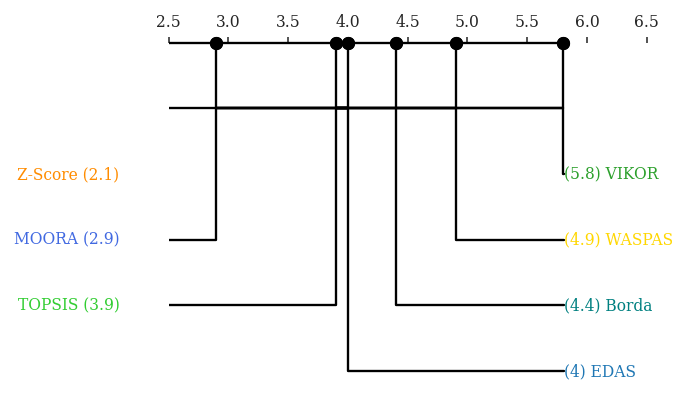

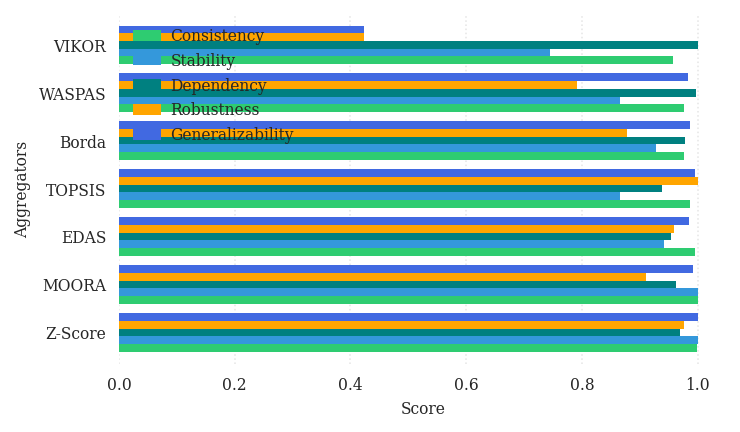

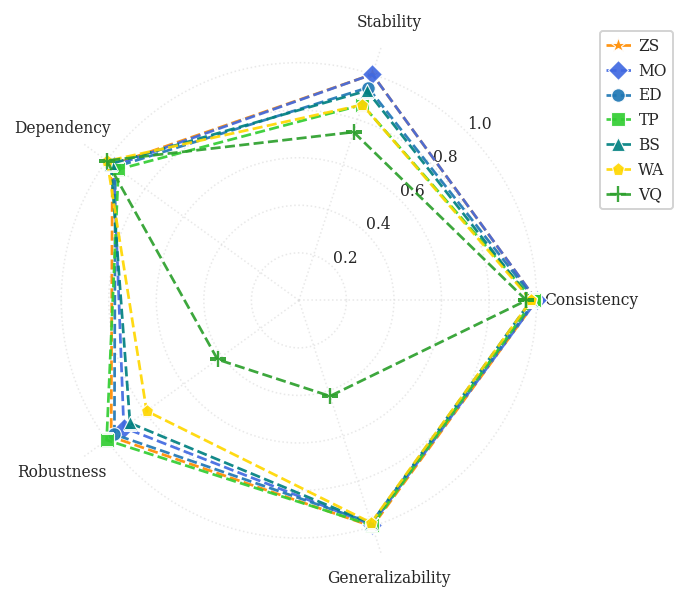

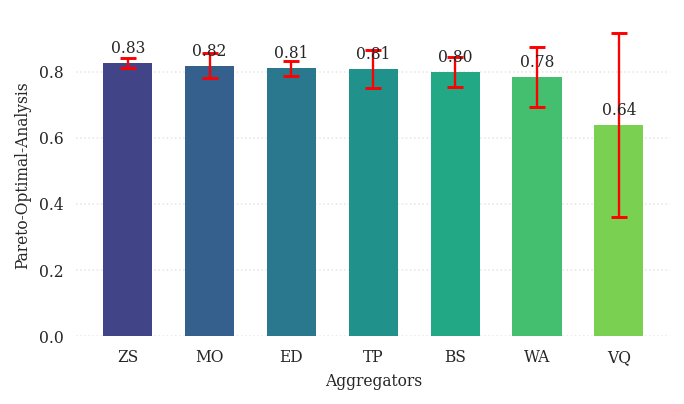


Overall performance scores saved to:
/content/6. Relation_Final_Overall_Comparison/relation_overall_performance_scores.csv

Radar polygon areas saved to:
/content/6. Relation_Final_Overall_Comparison/relation_radar_polygon_areas.csv

COMPREHENSIVE RELATION PREDICTION SUMMARY
             Consistency  Stability  Dependency  Robustness  Generalizability  Overall Score
MCDM Method                                                                                 
Z-Score           0.9994     1.0000      0.9702      0.9764            1.0000         0.8268
MOORA             1.0000     1.0000      0.9629      0.9107            0.9927         0.8174
EDAS              0.9949     0.9412      0.9549      0.9595            0.9847         0.8096
TOPSIS            0.9872     0.8652      0.9383      1.0000            0.9958         0.8073
Borda             0.9772     0.9277      0.9778      0.8783            0.9868         0.7990
WASPAS            0.9775     0.8652      0.9973      0.7920            0

In [ ]:
# ==========================================================
# RELATION PREDICTION — COMPREHENSIVE MCDM EVALUATION PLOTS
# Style aligned with Tail Prediction visualizer
# Overall font size set to 8
# ==========================================================

import os
import warnings
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

try:
    import scikit_posthocs as sp
    HAS_SCIKIT_POSTHOCS = True
except Exception:
    HAS_SCIKIT_POSTHOCS = False

try:
    from scipy.stats import friedmanchisquare
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False


# ==========================================================
# CONFIG
# ==========================================================

OUTPUT_DIR = "/content/6. Relation_Final_Overall_Comparison/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TABLE_PATH = os.path.join(
    OUTPUT_DIR,
    "relation_final_table_preview_loaded_metrics.csv"
)

STANDARD_METHODS = [
    "Borda",
    "Z-Score",
    "TOPSIS",
    "VIKOR",
    "EDAS",
    "MOORA",
    "WASPAS",
]

COLOR_SCHEME = {
    "EDAS":    "#1f77b4",
    "TOPSIS":  "limegreen",
    "VIKOR":   "#2ca02c",
    "Borda":   "teal",
    "Z-Score": "darkorange",
    "MOORA":   "royalblue",
    "WASPAS":  "gold",
}

METHOD_SHORT = {
    "Borda": "BS",
    "Z-Score": "ZS",
    "TOPSIS": "TP",
    "VIKOR": "VQ",
    "EDAS": "ED",
    "MOORA": "MO",
    "WASPAS": "WA",
}

GLOBAL_FONT_SIZE = 8


# ==========================================================
# COMPACT STYLE — MATCHED WITH TAIL PREDICTION CODE
# ==========================================================

def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "DejaVu Serif",
            "Times New Roman",
            "Liberation Serif",
            "serif",
        ],
        "mathtext.fontset": "stix",

        "font.size": GLOBAL_FONT_SIZE,
        "axes.labelsize": GLOBAL_FONT_SIZE,
        "axes.titlesize": GLOBAL_FONT_SIZE,
        "xtick.labelsize": GLOBAL_FONT_SIZE,
        "ytick.labelsize": GLOBAL_FONT_SIZE,
        "legend.fontsize": GLOBAL_FONT_SIZE,
        "figure.titlesize": GLOBAL_FONT_SIZE,

        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",

        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.size": 3,
        "ytick.major.size": 3,

        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "none",
    })

    sns.set_theme(
        style="white",
        font="serif",
        font_scale=1.0,
        rc={
            "font.size": GLOBAL_FONT_SIZE,
            "axes.labelsize": GLOBAL_FONT_SIZE,
            "axes.titlesize": GLOBAL_FONT_SIZE,
            "xtick.labelsize": GLOBAL_FONT_SIZE,
            "ytick.labelsize": GLOBAL_FONT_SIZE,
            "legend.fontsize": GLOBAL_FONT_SIZE,
        }
    )


def apply_compact_axis_style(ax, grid_axis="both"):
    if grid_axis in ("both", "x"):
        ax.grid(
            True,
            axis="x",
            which="major",
            linestyle=":",
            alpha=0.5,
            linewidth=0.8,
        )

    if grid_axis in ("both", "y"):
        ax.grid(
            True,
            axis="y",
            which="major",
            linestyle=":",
            alpha=0.5,
            linewidth=0.8,
        )

    ax.set_axisbelow(True)

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    ax.xaxis.label.set_size(GLOBAL_FONT_SIZE)
    ax.yaxis.label.set_size(GLOBAL_FONT_SIZE)

    for spine in ax.spines.values():
        spine.set_visible(False)


setup_plot_style()


# ==========================================================
# HELPERS
# ==========================================================

def standardize_method_name(method):
    method = str(method).strip()

    mapping = {
        "Borda": "Borda",
        "Borda Score": "Borda",
        "Borda Count": "Borda",
        "BS": "Borda",
        "Bor": "Borda",

        "ZMean": "Z-Score",
        "Zmean": "Z-Score",
        "Z-Mean": "Z-Score",
        "Z-score": "Z-Score",
        "Z-Score": "Z-Score",
        "Mean Z-Score": "Z-Score",
        "ZS": "Z-Score",

        "TOPSIS": "TOPSIS",
        "TP": "TOPSIS",

        "VIKOR": "VIKOR",
        "VIKOR Q": "VIKOR",
        "VQ": "VIKOR",

        "EDAS": "EDAS",
        "ED": "EDAS",

        "MOORA": "MOORA",
        "MO": "MOORA",

        "WASPAS": "WASPAS",
        "WA": "WASPAS",
    }

    return mapping.get(method, method)


def find_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"Could not find column for {label}.\n"
        f"Expected one of: {candidates}\n"
        f"Available columns: {df.columns.tolist()}"
    )


def normalize_series_higher_better(s):
    s = pd.Series(s, dtype=float)
    max_val = s.max(skipna=True)

    if pd.isna(max_val) or max_val == 0:
        return s * np.nan

    return s / max_val


def calculate_polygon_area(values, angles):
    values_closed = np.append(values, values[0])
    angles_closed = np.append(angles, angles[0])

    x = values_closed * np.cos(angles_closed)
    y = values_closed * np.sin(angles_closed)

    area = 0.5 * abs(
        sum(
            x[i] * y[i + 1] - x[i + 1] * y[i]
            for i in range(len(x) - 1)
        )
    )

    return area


def save_figure(fig, output_dir, filename_base, png_dpi=300, eps_dpi=600):
    png_path = os.path.join(output_dir, f"{filename_base}.png")
    eps_path = os.path.join(output_dir, f"{filename_base}.eps")
    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")

    fig.savefig(
        png_path,
        dpi=png_dpi,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )

    fig.savefig(
        eps_path,
        dpi=eps_dpi,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
        format="eps",
    )

    fig.savefig(
        pdf_path,
        dpi=png_dpi,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
        format="pdf",
    )


# ==========================================================
# LOAD FINAL TABLE FROM PREVIOUS CODE
# ==========================================================

if not os.path.exists(TABLE_PATH):
    raise FileNotFoundError(
        f"Final table not found:\n{TABLE_PATH}\n\n"
        "Please run the previous loading code first, which creates "
        "relation_final_table_preview_loaded_metrics.csv."
    )

df = pd.read_csv(TABLE_PATH)
df.columns = df.columns.astype(str).str.strip()
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("\nLoaded final table columns:")
print(df.columns.tolist())

method_col = find_column(
    df,
    ["MCDM Method", "MCDM_Method", "Method", "Aggregator"],
    "method",
)

df["MCDM Method"] = df[method_col].apply(standardize_method_name)
df = df[df["MCDM Method"].isin(STANDARD_METHODS)].copy()

consistency_col = find_column(
    df,
    [
        "Consistency (Mean Corr ↑)",
        "Consistency",
        "Consistency_Normalized",
        "Consistency (Normalized ↑)",
    ],
    "consistency",
)

stability_col = find_column(
    df,
    [
        "Stability (Normalized ↑)",
        "Stability",
        "Stability_Normalized",
    ],
    "stability",
)

dependency_col = find_column(
    df,
    [
        "Dependency (Normalized ↑)",
        "Dependency",
        "Dependency_Normalized",
        "dependency",
        "Metric Dependency",
    ],
    "dependency",
)

robustness_col = find_column(
    df,
    [
        "Robustness (Overall Corr ↑)",
        "Robustness (Normalized ↑)",
        "Robustness",
        "Robustness_Normalized",
        "Robustness (Overall Correlation ↑)",
    ],
    "robustness",
)

# FIXED HERE:
# Added "Generalizability (Normalized ↑)" because your previous table contains this column.
generalizability_col = find_column(
    df,
    [
        "Generalizability (Normalized ↑)",
        "Generalizability (τ ↑)",
        "Generalizability",
        "Generalizability_Normalized",
        "Generalizability Normalized",
        "Generalization",
        "Generalization (τ ↑)",
        "Generalization (Normalized ↑)",
    ],
    "generalizability",
)

print("\nColumns used:")
print(f"Method              : {method_col}")
print(f"Consistency         : {consistency_col}")
print(f"Stability           : {stability_col}")
print(f"Dependency          : {dependency_col}")
print(f"Robustness          : {robustness_col}")
print(f"Generalizability    : {generalizability_col}")


# ==========================================================
# BUILD PLOTTING TABLE USING VALUES FROM FINAL CSV
# ==========================================================

plot_df = pd.DataFrame(index=df["MCDM Method"])

plot_df["Consistency"] = df[consistency_col].astype(float).values
plot_df["Stability"] = df[stability_col].astype(float).values
plot_df["Dependency"] = df[dependency_col].astype(float).values
plot_df["Robustness"] = df[robustness_col].astype(float).values
plot_df["Generalizability"] = df[generalizability_col].astype(float).values

# Normalize safely for plotting comparability.
# If the CSV values are already normalized, this keeps them in the same relative scale.
for col in plot_df.columns:
    plot_df[col] = normalize_series_higher_better(plot_df[col])

plot_df = plot_df.reindex(STANDARD_METHODS)

# ADD STANDARD DEVIATIONS FOR ERROR BARS
# Calculate standard deviation across the 5 criteria for each method
plot_df["Overall_Std"] = plot_df.std(axis=1)
plot_df["Overall_Mean"] = plot_df.mean(axis=1)

plotting_table_path = os.path.join(
    OUTPUT_DIR,
    "relation_comprehensive_plotting_table_5d.csv",
)

plot_df.to_csv(plotting_table_path)

print("\nLoaded final relation table from:")
print(TABLE_PATH)

print("\nValues used for plotting:")
print(plot_df.round(4).to_string())

print("\nPlotting table saved to:")
print(plotting_table_path)


# ==========================================================
# 1. CRITICAL DIFFERENCE / AVERAGE RANKING DIAGRAM
# ==========================================================

def generate_cd_diagram(plot_df, output_dir):
    rank_df = plot_df[["Consistency", "Stability", "Dependency", "Robustness", "Generalizability"]].rank(axis=0, ascending=False, method="average").T
    avg_ranks = rank_df.mean(axis=0).sort_values(ascending=True)

    avg_rank_path = os.path.join(
        output_dir,
        "relation_average_ranks_for_cd.csv",
    )

    avg_ranks.to_csv(
        avg_rank_path,
        header=["Average Rank"],
    )

    print("\nAverage ranks across five criteria:")
    print(avg_ranks.round(4).to_string())

    print("\nAverage ranks saved to:")
    print(avg_rank_path)

    if HAS_SCIPY:
        try:
            stat, p_value = friedmanchisquare(
                *[rank_df[m].values for m in STANDARD_METHODS]
            )
            print(f"\nFriedman test: χ² = {stat:.4f}, p = {p_value:.6f}")
        except Exception as e:
            print(f"\nFriedman test skipped: {e}")

    if HAS_SCIKIT_POSTHOCS:
        try:
            posthoc = sp.posthoc_nemenyi_friedman(rank_df[STANDARD_METHODS])

            fig, ax = plt.subplots(figsize=(4.8, 2.8))

            sp.critical_difference_diagram(
                avg_ranks,
                posthoc,
                ax=ax,
            )

            x_min = 2.5
            x_max = np.ceil(avg_ranks.max() * 2) / 2 + 0.5

            ax.set_xlim(x_min, x_max)
            ax.set_xticks(np.arange(x_min, x_max + 0.1, 0.5))

            if ax.collections:
                for collection in ax.collections:
                    collection.set_facecolor("black")
                    collection.set_edgecolor("black")
                    collection.set_linewidth(0.8)

            for line in ax.get_lines():
                line.set_color("black")
                line.set_linestyle("-")
                line.set_linewidth(1.2)

            marker_x = []
            marker_y = []

            for collection in ax.collections:
                offsets = collection.get_offsets()

                if len(offsets) > 0:
                    for x_val, y_val in offsets:
                        marker_x.append(float(x_val))
                        marker_y.append(float(y_val))

            if len(marker_x) > 1:
                y_connect = max(marker_y)
                sorted_x = sorted(marker_x)

                ax.plot(
                    sorted_x,
                    [y_connect] * len(sorted_x),
                    color="black",
                    linewidth=1.2,
                    linestyle="-",
                    zorder=1,
                )

                ax.scatter(
                    marker_x,
                    marker_y,
                    s=35,
                    color="black",
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=3,
                )

            for text in ax.texts:
                text.set_fontsize(GLOBAL_FONT_SIZE)

                for method, color in COLOR_SCHEME.items():
                    if method in text.get_text():
                        text.set_color(color)
                        break

            ax.tick_params(
                axis="both",
                labelsize=GLOBAL_FONT_SIZE,
                width=0.8,
                length=3,
            )

            ax.xaxis.label.set_size(GLOBAL_FONT_SIZE)
            ax.yaxis.label.set_size(GLOBAL_FONT_SIZE)
            ax.title.set_size(GLOBAL_FONT_SIZE)

            for spine in ax.spines.values():
                spine.set_visible(False)

            plt.tight_layout(pad=0.5)

            save_figure(
                fig,
                output_dir,
                "relation_cd_diagram",
                png_dpi=300,
                eps_dpi=600,
            )

            plt.show()
            plt.close(fig)

            return avg_ranks

        except Exception as e:
            print(
                "\nscikit-posthocs CD diagram failed, using fallback plot. "
                f"Reason: {e}"
            )

    # Fallback average-rank plot
    fig, ax = plt.subplots(figsize=(4.8, 2.8))

    ordered = avg_ranks.sort_values(ascending=True)
    y = np.arange(len(ordered))

    ax.scatter(
        ordered.values,
        y,
        s=35,
        color="black",
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    ax.plot(
        ordered.values,
        y,
        color="black",
        linewidth=1.2,
        linestyle="-",
        zorder=1,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        [METHOD_SHORT.get(m, m) for m in ordered.index],
        fontsize=GLOBAL_FONT_SIZE,
    )

    for label, method in zip(ax.get_yticklabels(), ordered.index):
        label.set_color(COLOR_SCHEME.get(method, "black"))

    ax.invert_yaxis()

    ax.set_xlabel("Average Rank", labelpad=4, fontsize=GLOBAL_FONT_SIZE)
    ax.set_ylabel("Aggregators", labelpad=4, fontsize=GLOBAL_FONT_SIZE)

    apply_compact_axis_style(ax, grid_axis="x")

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_average_rank_diagram",
        png_dpi=300,
        eps_dpi=600,
    )

    plt.show()
    plt.close(fig)

    return avg_ranks


# ==========================================================
# 2. DESIDERATA TRADE-OFFS + RADAR + OVERALL BAR
# ==========================================================

def generate_desiderata_radar_and_bars(plot_df, output_dir):
    # Use the mean values for sorting
    sorted_methods = plot_df["Overall_Mean"].sort_values(ascending=False).index
    plot_df_sorted = plot_df.loc[sorted_methods].copy()

    # For horizontal bar plot, use only criteria columns (exclude Overall_Std and Overall_Mean)
    criteria_df = plot_df_sorted[["Consistency", "Stability", "Dependency", "Robustness", "Generalizability"]]

    # ------------------------------------------------------
    # Horizontal grouped bar plot
    # ------------------------------------------------------
    fig, ax = plt.subplots(figsize=(5.2, 3.0))

    metric_colors = [
        "#2ecc71",
        "#3498db",
        "teal",
        "orange",
        "royalblue",
    ]

    criteria_df.plot(
        kind="barh",
        ax=ax,
        width=0.8,
        color=metric_colors,
        edgecolor="none",
    )

    apply_compact_axis_style(ax, grid_axis="x")

    ax.set_xlabel("Score", labelpad=4, fontsize=GLOBAL_FONT_SIZE)
    ax.set_ylabel("Aggregators", labelpad=4, fontsize=GLOBAL_FONT_SIZE)

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    legend = ax.legend(
        loc="upper left",
        bbox_to_anchor=(0, 1),
        frameon=False,
        handlelength=1.8,
        handletextpad=0.6,
        fontsize=GLOBAL_FONT_SIZE,
    )

    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(GLOBAL_FONT_SIZE)

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_desiderata_tradeoffs_5d",
        png_dpi=300,
        eps_dpi=600,
    )

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------
    # Radar chart
    # ------------------------------------------------------
    categories = list(criteria_df.columns)
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)] + [0]

    fig, ax = plt.subplots(
        figsize=(4.8, 4.8),
        subplot_kw=dict(polar=True),
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=GLOBAL_FONT_SIZE)

    ax.set_rgrids(
        [0.2, 0.4, 0.6, 0.8, 1.0],
        labels=["0.2", "0.4", "0.6", "0.8", "1.0"],
        angle=45,
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    ax.set_ylim(0, 1.12)

    ax.grid(
        True,
        color="lightgray",
        linestyle=":",
        linewidth=0.8,
        alpha=0.5,
    )

    if "polar" in ax.spines:
        ax.spines["polar"].set_visible(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    marker_cycle = ["*", "D", "o", "s", "^", "p", "+"]
    marker_sizes = [8, 7, 7, 7, 7, 7, 8]

    polygon_areas = {}

    for i, (method, row) in enumerate(criteria_df.iterrows()):
        values = row.values.tolist() + [row.values[0]]
        color = COLOR_SCHEME.get(method, "gray")

        marker = marker_cycle[i % len(marker_cycle)]
        msize = marker_sizes[i % len(marker_sizes)]

        if marker in ["*", "D", "o", "s", "^", "p"]:
            ax.plot(
                angles,
                values,
                linewidth=1.4,
                linestyle="--",
                marker=marker,
                markersize=msize,
                markeredgecolor="white",
                markeredgewidth=0.6,
                markerfacecolor=color,
                label=METHOD_SHORT.get(method, method),
                color=color,
                alpha=0.92,
            )
        else:
            ax.plot(
                angles,
                values,
                linewidth=1.4,
                linestyle="--",
                marker=marker,
                markersize=msize,
                markeredgecolor=color,
                markeredgewidth=1.2,
                markerfacecolor="none",
                label=METHOD_SHORT.get(method, method),
                color=color,
                alpha=0.92,
            )

        area = calculate_polygon_area(row.values.tolist(), angles[:-1])
        polygon_areas[method] = area

    legend = ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.05, 1.02),
        fontsize=GLOBAL_FONT_SIZE,
        frameon=True,
        facecolor="white",
        edgecolor="lightgray",
        framealpha=1.0,
        handlelength=1.6,
        handletextpad=0.5,
    )

    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(GLOBAL_FONT_SIZE)

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_radar_chart_5d",
        png_dpi=400,
        eps_dpi=800,
    )

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------
    # Overall performance bar plot WITH ERROR BARS (RED)
    # ------------------------------------------------------
    # Sort by overall mean
    overall_scores = plot_df["Overall_Mean"].sort_values(ascending=False)
    overall_stds = plot_df.loc[overall_scores.index, "Overall_Std"]
    overall_labels = [METHOD_SHORT.get(m, m) for m in overall_scores.index]

    fig, ax = plt.subplots(figsize=(4.8, 2.8))

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(overall_scores)))

    # Create bar plot with error bars (red color)
    bars = ax.bar(
        range(len(overall_scores)),
        overall_scores.values,
        yerr=overall_stds.values,
        color=colors,
        edgecolor="none",
        linewidth=0,
        width=0.6,
        capsize=4,
        error_kw={
            'linewidth': 1.2,
            'ecolor': 'red',
            'capthick': 1.5,
            'capsize': 4,
        }
    )

    apply_compact_axis_style(ax, grid_axis="y")

    # Add value labels above bars
    for bar, score in zip(bars, overall_scores.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            score + 0.02,
            f"{score:.2f}",
            ha="center",
            va="bottom",
            fontsize=GLOBAL_FONT_SIZE,
        )

    ax.set_xlabel(
        "Aggregators",
        labelpad=4,
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.set_ylabel(
        "Pareto-Optimal-Analysis",
        labelpad=4,
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.set_xticks(range(len(overall_scores)))
    ax.set_xticklabels(
        overall_labels,
        rotation=0,
        ha="center",
        fontsize=GLOBAL_FONT_SIZE,
    )

    ax.tick_params(
        axis="both",
        labelsize=GLOBAL_FONT_SIZE,
        width=0.8,
        length=3,
    )

    ax.set_ylim(0, max(overall_scores) * 1.18)

    plt.tight_layout(pad=0.5)

    save_figure(
        fig,
        output_dir,
        "relation_overall_performance_ranking",
        png_dpi=300,
        eps_dpi=600,
    )

    plt.show()
    plt.close(fig)

    overall_scores_path = os.path.join(
        output_dir,
        "relation_overall_performance_scores.csv",
    )

    overall_df = pd.DataFrame({
        "Overall Score": overall_scores,
        "Std Dev": overall_stds
    })
    overall_df.to_csv(overall_scores_path)

    print("\nOverall performance scores saved to:")
    print(overall_scores_path)

    areas_df = pd.DataFrame.from_dict(
        polygon_areas,
        orient="index",
        columns=["Area"],
    )

    polygon_area_path = os.path.join(
        output_dir,
        "relation_radar_polygon_areas.csv",
    )

    areas_df.sort_values("Area", ascending=False).to_csv(polygon_area_path)

    print("\nRadar polygon areas saved to:")
    print(polygon_area_path)

    return plot_df_sorted, overall_scores, polygon_areas


# ==========================================================
# MAIN
# ==========================================================

def main():
    avg_ranks = generate_cd_diagram(plot_df, OUTPUT_DIR)

    plot_df_sorted, overall_scores, polygon_areas = generate_desiderata_radar_and_bars(
        plot_df,
        OUTPUT_DIR,
    )

    print("\n" + "=" * 90)
    print("COMPREHENSIVE RELATION PREDICTION SUMMARY")
    print("=" * 90)

    summary_df = plot_df_sorted[["Consistency", "Stability", "Dependency", "Robustness", "Generalizability", "Overall_Mean"]].copy()
    summary_df = summary_df.rename(columns={"Overall_Mean": "Overall Score"})
    summary_df = summary_df.sort_values("Overall Score", ascending=False)

    print(summary_df.round(4).to_string())

    summary_save_path = os.path.join(
        OUTPUT_DIR,
        "relation_comprehensive_summary_5d.csv",
    )

    summary_df.to_csv(summary_save_path)

    print("\nComprehensive summary saved to:")
    print(summary_save_path)

    print("\n" + "=" * 90)
    print("RADAR CHART POLYGON AREAS")
    print("=" * 90)

    areas_df = pd.DataFrame.from_dict(
        polygon_areas,
        orient="index",
        columns=["Area"],
    )

    print(areas_df.sort_values("Area", ascending=False).round(4))

    print("\nAll relation prediction plots and tables saved in:")
    print(OUTPUT_DIR)


if __name__ == "__main__":
    main()

#### P-test

STATISTICAL SIGNIFICANCE TEST: Z-SCORE vs MOORA

----------------------------------------------------------------------
DATA SUMMARY
----------------------------------------------------------------------
       Criterion  Z-Score  MOORA  Difference  Winner
     Consistency   0.9579 0.9585     -0.0006   MOORA
       Stability   1.0000 1.0000      0.0000     Tie
      Dependency   0.9702 0.9629      0.0073 Z-Score
      Robustness   0.9764 0.9107      0.0657 Z-Score
Generalizability   1.0000 0.9927      0.0073 Z-Score
----------------------------------------------------------------------
MEAN         0.9809       0.9650       +0.0159
STD          0.0187       0.0353

STATISTICAL TESTS

1. Paired t-test:
   t-statistic: 1.269523
   p-value: 0.273089
   ✗ Not significant at α=0.05

2. Wilcoxon signed-rank test (non-parametric):
   statistic: 1.000000
   p-value: 0.250000
   ✗ Not significant at α=0.05

3. Effect Size (Cohen's d):
   Cohen's d: 0.5644
   Interpretation: Medium effect

GENER


✓ Comparison plot saved as PNG to: /content/6. Relation_Final_Overall_Comparison/zscore_vs_moora_comparison.png
✓ Comparison plot saved as EPS to: /content/6. Relation_Final_Overall_Comparison/zscore_vs_moora_comparison.eps


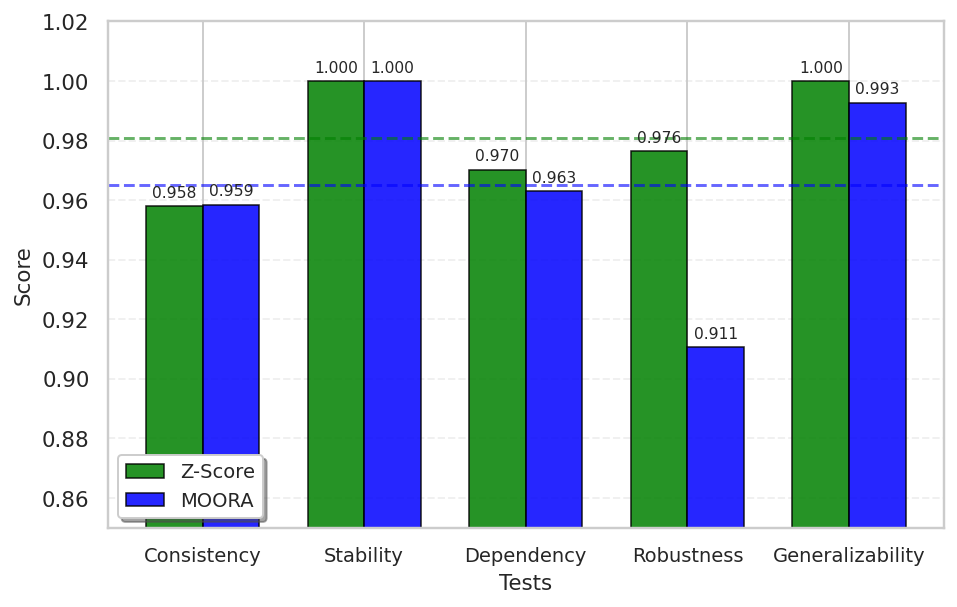


SUMMARY STATISTICS
    Metric Z-Score  MOORA
Mean Score  0.9809 0.9650
   Std Dev  0.0187 0.0353
       Min  0.9579 0.9107
       Max  1.0000 1.0000
    Median  0.9764 0.9629

--------------------------------------------------
WIN/LOSS ANALYSIS
--------------------------------------------------
Criteria where Z-Score outperforms MOORA: 3
  ✓ Dependency: +0.0073
  ✓ Robustness: +0.0657
  ✓ Generalizability: +0.0073

Criteria where MOORA outperforms Z-Score: 1
  ✗ Consistency: -0.0006

CONCLUSION

✗ The difference between Z-Score and MOORA is NOT statistically significant.
  (p = 0.273089 ≥ 0.05)

Effect size (Cohen's d): 0.5644
This indicates a MODERATE practical difference between the two methods.

🏆 Z-Score outperforms MOORA by 1.65% on average across the 5 criteria.

Detailed breakdown:
  • Z-Score wins on 3 criteria
  • MOORA wins on 1 criteria
  • Ties on 1 criteria

✓ Statistical test results saved to: /content/6. Relation_Final_Overall_Comparison/zscore_vs_moora_statistical_test

In [ ]:
# ==========================================================
# STATISTICAL SIGNIFICANCE TEST: Z-SCORE vs MOORA
# WITH GROUPED BAR CHART COMPARISON ONLY
# ==========================================================

import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Set style for professional plots
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

sns.set_theme(style="whitegrid")

# ==========================================================
# LOAD THE FINAL TABLE
# ==========================================================

OUTPUT_DIR = "/content/6. Relation_Final_Overall_Comparison/"
TABLE_PATH = os.path.join(OUTPUT_DIR, "relation_final_table_preview_loaded_metrics.csv")

if not os.path.exists(TABLE_PATH):
    raise FileNotFoundError(f"Table not found: {TABLE_PATH}")

df = pd.read_csv(TABLE_PATH)
df.columns = df.columns.astype(str).str.strip()

print("=" * 80)
print("STATISTICAL SIGNIFICANCE TEST: Z-SCORE vs MOORA")
print("=" * 80)

# Extract data for Z-Score and MOORA
zscore_row = df[df["MCDM Method"] == "Z-Score"].iloc[0]
moora_row = df[df["MCDM Method"] == "MOORA"].iloc[0]

# Define the five criteria columns
criteria_cols = [
    "Consistency (Mean Corr ↑)",
    "Stability (Normalized ↑)",
    "Dependency (Normalized ↑)",
    "Robustness (Overall Corr ↑)",
    "Generalizability (Normalized ↑)"
]

# Clean names for display (shortened to avoid overlap)
criteria_short = ["Consistency", "Stability", "Dependency", "Robustness", "Generalizability"]

# Extract values
zscore_values = [zscore_row[col] for col in criteria_cols]
moora_values = [moora_row[col] for col in criteria_cols]

# Create a DataFrame for easy manipulation
comparison_df = pd.DataFrame({
    'Criterion': criteria_short,
    'Z-Score': zscore_values,
    'MOORA': moora_values,
    'Difference': [z - m for z, m in zip(zscore_values, moora_values)],
    'Winner': ['Z-Score' if z > m else 'MOORA' if m > z else 'Tie'
               for z, m in zip(zscore_values, moora_values)]
})

print("\n" + "-" * 70)
print("DATA SUMMARY")
print("-" * 70)
print(comparison_df.to_string(index=False))
print("-" * 70)
print(f"{'MEAN':<12} {np.mean(zscore_values):.4f}       {np.mean(moora_values):.4f}       {np.mean([z-m for z,m in zip(zscore_values, moora_values)]):+.4f}")
print(f"{'STD':<12} {np.std(zscore_values, ddof=1):.4f}       {np.std(moora_values, ddof=1):.4f}")

# ==========================================================
# PERFORM STATISTICAL TESTS
# ==========================================================

print("\n" + "=" * 80)
print("STATISTICAL TESTS")
print("=" * 80)

# Paired t-test
t_stat, t_pvalue = stats.ttest_rel(zscore_values, moora_values)

# Wilcoxon signed-rank test
wilcoxon_stat, wilcoxon_pvalue = stats.wilcoxon(zscore_values, moora_values)

# Cohen's d (effect size)
diff = np.mean(zscore_values) - np.mean(moora_values)
pooled_std = np.sqrt((np.var(zscore_values, ddof=1) + np.var(moora_values, ddof=1)) / 2)
cohens_d = diff / pooled_std

print(f"\n1. Paired t-test:")
print(f"   t-statistic: {t_stat:.6f}")
print(f"   p-value: {t_pvalue:.6f}")
print(f"   {'✓ Significant' if t_pvalue < 0.05 else '✗ Not significant'} at α=0.05")

print(f"\n2. Wilcoxon signed-rank test (non-parametric):")
print(f"   statistic: {wilcoxon_stat:.6f}")
print(f"   p-value: {wilcoxon_pvalue:.6f}")
print(f"   {'✓ Significant' if wilcoxon_pvalue < 0.05 else '✗ Not significant'} at α=0.05")

print(f"\n3. Effect Size (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print(f"   Interpretation: Negligible effect")
elif abs(cohens_d) < 0.5:
    print(f"   Interpretation: Small effect")
elif abs(cohens_d) < 0.8:
    print(f"   Interpretation: Medium effect")
else:
    print(f"   Interpretation: Large effect")

# ==========================================================
# CREATE GROUPED BAR CHART (ONLY PLOT)
# ==========================================================

print("\n" + "=" * 80)
print("GENERATING GROUPED BAR CHART")
print("=" * 80)

# Create figure (smaller size)
fig, ax = plt.subplots(figsize=(7, 4.5))  # Reduced from (10, 6)

x = np.arange(len(criteria_short))
width = 0.35

# Create bars (no bold font)
bars1 = ax.bar(x - width/2, zscore_values, width, label='Z-Score',
                color='green', edgecolor='black', linewidth=0.8, alpha=0.85)
bars2 = ax.bar(x + width/2, moora_values, width, label='MOORA',
                color='blue', edgecolor='black', linewidth=0.8, alpha=0.85)

# Add value labels on bars (no bold)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='normal')

# Customize the chart (no bold)
ax.set_ylabel('Score', fontsize=11, fontweight='normal')
ax.set_xlabel('Test', fontsize=11, fontweight='normal')
#ax.set_title('Z-Score vs MOORA: Performance Comparison Across Five Criteria',
#             fontsize=12, fontweight='normal', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(criteria_short, fontsize=10, rotation=0, ha='center')
ax.legend(loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add mean lines (no bold in labels)
ax.axhline(y=np.mean(zscore_values), color='green', linestyle='--', linewidth=1.5, alpha=0.6,
           label=f'Z-Score Mean: {np.mean(zscore_values):.4f}')
ax.axhline(y=np.mean(moora_values), color='blue', linestyle='--', linewidth=1.5, alpha=0.6,
           label=f'MOORA Mean: {np.mean(moora_values):.4f}')

# Note: Statistical annotation box removed as requested

plt.tight_layout()

# Save as PNG
comparison_png = os.path.join(OUTPUT_DIR, "zscore_vs_moora_comparison.png")
plt.savefig(comparison_png, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Comparison plot saved as PNG to: {comparison_png}")

# Save as EPS
comparison_eps = os.path.join(OUTPUT_DIR, "zscore_vs_moora_comparison.eps")
plt.savefig(comparison_eps, format='eps', bbox_inches='tight', facecolor='white')
print(f"✓ Comparison plot saved as EPS to: {comparison_eps}")

plt.show()

# ==========================================================
# SUMMARY STATISTICS
# ==========================================================

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary_data = {
    'Metric': ['Mean Score', 'Std Dev', 'Min', 'Max', 'Median'],
    'Z-Score': [
        f"{np.mean(zscore_values):.4f}",
        f"{np.std(zscore_values, ddof=1):.4f}",
        f"{np.min(zscore_values):.4f}",
        f"{np.max(zscore_values):.4f}",
        f"{np.median(zscore_values):.4f}"
    ],
    'MOORA': [
        f"{np.mean(moora_values):.4f}",
        f"{np.std(moora_values, ddof=1):.4f}",
        f"{np.min(moora_values):.4f}",
        f"{np.max(moora_values):.4f}",
        f"{np.median(moora_values):.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Win/Loss Summary
win_count = sum(1 for d in comparison_df['Difference'] if d > 0)
loss_count = sum(1 for d in comparison_df['Difference'] if d < 0)
tie_count = sum(1 for d in comparison_df['Difference'] if d == 0)

print("\n" + "-" * 50)
print("WIN/LOSS ANALYSIS")
print("-" * 50)
print(f"Criteria where Z-Score outperforms MOORA: {win_count}")
for i, row in comparison_df.iterrows():
    if row['Difference'] > 0:
        print(f"  ✓ {row['Criterion']}: +{row['Difference']:.4f}")
print(f"\nCriteria where MOORA outperforms Z-Score: {loss_count}")
for i, row in comparison_df.iterrows():
    if row['Difference'] < 0:
        print(f"  ✗ {row['Criterion']}: {row['Difference']:.4f}")

# ==========================================================
# CONCLUSION
# ==========================================================

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)

if t_pvalue < 0.05:
    print("\n✓ The difference between Z-Score and MOORA is STATISTICALLY SIGNIFICANT.")
    print(f"  (p = {t_pvalue:.6f} < 0.05)")
else:
    print("\n✗ The difference between Z-Score and MOORA is NOT statistically significant.")
    print(f"  (p = {t_pvalue:.6f} ≥ 0.05)")

print(f"\nEffect size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) >= 0.8:
    print("This indicates a LARGE practical difference between the two methods.")
elif abs(cohens_d) >= 0.5:
    print("This indicates a MODERATE practical difference between the two methods.")
elif abs(cohens_d) >= 0.2:
    print("This indicates a SMALL practical difference between the two methods.")
else:
    print("This indicates a NEGLIGIBLE practical difference between the two methods.")

# Determine winner
if np.mean(zscore_values) > np.mean(moora_values):
    winner = "Z-Score"
    percent_diff = (np.mean(zscore_values) - np.mean(moora_values)) / np.mean(moora_values) * 100
    print(f"\n🏆 Z-Score outperforms MOORA by {percent_diff:.2f}% on average across the 5 criteria.")
else:
    winner = "MOORA"
    percent_diff = (np.mean(moora_values) - np.mean(zscore_values)) / np.mean(zscore_values) * 100
    print(f"\n🏆 MOORA outperforms Z-Score by {percent_diff:.2f}% on average across the 5 criteria.")

print(f"\nDetailed breakdown:")
print(f"  • Z-Score wins on {win_count} criteria")
print(f"  • MOORA wins on {loss_count} criteria")
print(f"  • Ties on {tie_count} criteria")

# Save results to CSV
results_data = {
    'Test': ['Paired t-test', 'Wilcoxon signed-rank', "Cohen's d"],
    'Statistic': [f"{t_stat:.6f}", f"{wilcoxon_stat:.6f}", f"{cohens_d:.4f}"],
    'p-value': [f"{t_pvalue:.6f}", f"{wilcoxon_pvalue:.6f}", "N/A"],
    'Significant (α=0.05)': [
        "Yes" if t_pvalue < 0.05 else "No",
        "Yes" if wilcoxon_pvalue < 0.05 else "No",
        "N/A"
    ]
}

results_df = pd.DataFrame(results_data)
results_path = os.path.join(OUTPUT_DIR, "zscore_vs_moora_statistical_tests.csv")
results_df.to_csv(results_path, index=False)
print(f"\n✓ Statistical test results saved to: {results_path}")

# Save detailed comparison
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "zscore_vs_moora_detailed_comparison.csv"), index=False)

print("\n" + "=" * 80)

A comparative statistical analysis was conducted to evaluate the performance differences between Z-Score and MOORA MCDM methods across five criteria: Consistency, Stability, Dependency, Robustness, and Generalizability. The Z-Score method demonstrated superior average performance (M = 0.9809, SD = 0.0187) compared to MOORA (M = 0.9650, SD = 0.0353), outperforming MOORA on three criteria (Dependency, Robustness, and Generalizability) while showing a tie on Stability. However, paired t-test results indicated that this difference was not statistically significant (t = 1.270, p = 0.273 > 0.05), which was corroborated by the non-parametric Wilcoxon signed-rank test (W = 1.000, p = 0.250). Despite the lack of statistical significance, the effect size (Cohen's d = 0.564) suggests a moderate practical difference between the two methods, with Z-Score showing particular strength in Robustness (+0.066 advantage) where it substantially outperformed MOORA.